# IEEE-CIS Fraud Detection — Anomaly Detection vs. Supervised Classification

**An end-to-end, resource-aware fraud detection project for Google Colab.**

---

## Research question

> *Can unsupervised anomaly detection identify fraudulent e-commerce transactions purely from their
> deviation from normal transaction behaviour, and how does that compare with a supervised fraud
> classifier trained on labels?*

## Two tracks

| Track | Models | Uses `isFraud` during training? |
|---|---|---|
| **A — Unsupervised anomaly detection** | Isolation Forest, Local Outlier Factor, Autoencoder | No (labels used only for *evaluation* and *threshold selection*) |
| **B — Supervised classification** | LightGBM (fallbacks: XGBoost → HistGradientBoosting) | Yes |

## What this notebook does

1. Automatically ingests the IEEE-CIS dataset from Kaggle (credentials via Colab secrets — never hard-coded).
2. Persists every artifact to Google Drive and reuses cached artifacts on re-runs.
3. Validates the data and audits it for leakage before any modelling.
4. Splits **chronologically** (70 / 15 / 15) — never randomly — because deployment means scoring *future* transactions.
5. Engineers fraud-oriented features with train-only fitted statistics.
6. Trains and compares four models with ranking-oriented metrics (PR-AUC, Precision@K, Recall@K).
7. Selects operating thresholds on the **validation** set only; the test set is scored exactly once.
8. Explains predictions with SHAP (supervised) and deviation/reconstruction analysis (anomaly).
9. Runs error analysis, temporal drift analysis and a hypothetical cost analysis.
10. Ships an interactive Gradio app that loads the saved artifacts instead of retraining.

## Before you run

You need a **free Kaggle account** and you must **accept the competition rules once**, in a browser:

> <https://www.kaggle.com/competitions/ieee-fraud-detection/rules>

Then create an API token (Kaggle → Settings → API → *Create New Token*) and store the values as Colab
secrets. Full instructions are in **Section 4**.

## Runtime expectations

| Configuration | Approx. runtime on a free Colab CPU runtime |
|---|---|
| `FAST_MODE = True` | ~10–20 minutes |
| `FAST_MODE = False` (default) | ~45–80 minutes (most of it gradient boosting) |

RAM peaks at roughly 6–9 GB with the default settings, which fits a standard Colab instance.
Every expensive stage is individually switchable (`RUN_LOF`, `RUN_AUTOENCODER`, `RUN_HYPERPARAMETER_TUNING`, ...).

> **Disclaimer.** This is a research / portfolio prototype built on a public benchmark dataset.
> It is *not* a production banking system and none of its numbers should be read as real financial outcomes.

## 1. Environment Setup

**What:** check which packages are already present in the runtime and install only the missing ones,
then report the exact software and hardware the notebook is running on.

**Why:** Colab ships most of the scientific stack already. Blindly re-installing packages wastes
several minutes, can silently *downgrade* a working NumPy/pandas pair, and sometimes forces a runtime
restart. Recording versions and hardware is also the first requirement of reproducibility.

**Assumption:** the runtime has internet access to PyPI. If an install fails the notebook prints an
actionable message rather than dying silently — most components degrade gracefully (e.g. LightGBM →
XGBoost → scikit-learn's `HistGradientBoostingClassifier`).

In [1]:
# --- Package availability check & minimal installation -------------------------------------------
import importlib, subprocess, sys, warnings

warnings.filterwarnings("ignore")

# package import name -> pip name
REQUIRED = {
    "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib", "seaborn": "seaborn",
    "sklearn": "scikit-learn", "scipy": "scipy", "joblib": "joblib", "tqdm": "tqdm",
    "psutil": "psutil",
}
OPTIONAL = {
    "lightgbm": "lightgbm",      # preferred supervised model
    "xgboost": "xgboost",        # fallback supervised model
    "shap": "shap",              # explainability
    "gradio": "gradio",          # interactive app
    "kagglehub": "kagglehub",    # dataset ingestion (primary)
    "kaggle": "kaggle",          # dataset ingestion (fallback CLI/API)
    "pyarrow": "pyarrow",        # Parquet cache (fast re-loads)
}

def _is_available(mod: str) -> bool:
    try:
        return importlib.util.find_spec(mod) is not None
    except (ImportError, ValueError):
        return False

def _pip_install(pkgs, label):
    if not pkgs:
        print(f"[OK] {label}: nothing to install, all present.")
        return []
    print(f"[..] {label}: installing {pkgs} (this can take a minute)")
    failed = []
    for p in pkgs:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", p],
                           check=True, capture_output=True, text=True, timeout=900)
            print(f"     [OK] installed {p}")
        except Exception as exc:                       # noqa: BLE001 - we want the reason surfaced
            detail = getattr(exc, "stderr", "") or str(exc)
            print(f"     [FAIL] could not install {p}: {str(detail)[:400]}")
            failed.append(p)
    return failed

missing_required = [pip for mod, pip in REQUIRED.items() if not _is_available(mod)]
missing_optional = [pip for mod, pip in OPTIONAL.items() if not _is_available(mod)]

failed_required = _pip_install(missing_required, "required packages")
failed_optional = _pip_install(missing_optional, "optional packages")

if failed_required:
    raise RuntimeError(
        "Core packages could not be installed: "
        f"{failed_required}. Check the Colab runtime's internet access, then re-run this cell."
    )
if failed_optional:
    print(f"\n[WARN] Optional packages unavailable: {failed_optional}. "
          "The notebook will fall back to alternatives and document the substitution.")

[OK] required packages: nothing to install, all present.
[OK] optional packages: nothing to install, all present.


In [2]:
# --- Imports, versions, hardware report, global seeds --------------------------------------------
import gc, glob, json, os, platform, random, shutil, subprocess, sys, time, zipfile
from contextlib import contextmanager
from datetime import datetime, timedelta

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import QuantileTransformer

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titleweight": "bold",
})
sns.set_palette("deep")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

def _gpu_info():
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                              "--format=csv,noheader"],
                             capture_output=True, text=True, timeout=20)
        if out.returncode == 0 and out.stdout.strip():
            return out.stdout.strip().replace("\n", " | ")
    except Exception:
        pass
    return "none detected (CPU-only runtime)"

vm = psutil.virtual_memory()
print("=" * 78)
print("ENVIRONMENT REPORT")
print("=" * 78)
print(f"Timestamp        : {datetime.now().isoformat(timespec='seconds')}")
print(f"Python           : {platform.python_version()}  ({platform.platform()})")
print(f"Running in Colab : {IN_COLAB}")
print(f"CPU cores        : {psutil.cpu_count(logical=True)} logical / "
      f"{psutil.cpu_count(logical=False)} physical")
print(f"RAM              : {vm.total / 1e9:.1f} GB total, {vm.available / 1e9:.1f} GB available")
print(f"Disk free        : {shutil.disk_usage('/').free / 1e9:.1f} GB")
print(f"GPU              : {_gpu_info()}")
print("-" * 78)

PKG_VERSIONS = {"python": platform.python_version()}
for mod in ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn", "joblib",
            "lightgbm", "xgboost", "shap", "gradio", "kagglehub", "tensorflow"]:
    try:
        PKG_VERSIONS[mod] = importlib.import_module(mod).__version__
    except Exception:
        PKG_VERSIONS[mod] = "not installed"
for k, v in PKG_VERSIONS.items():
    print(f"{k:<12}: {v}")
print("=" * 78)
print(f"Global seed set to {SEED} for random / numpy / PYTHONHASHSEED "
      "(model-level seeds are set at construction time).")

ENVIRONMENT REPORT
Timestamp        : 2026-08-11T10:11:58
Python           : 3.12.13  (Linux-6.6.122+-x86_64-with-glibc2.35)
Running in Colab : True
CPU cores        : 2 logical / 1 physical
RAM              : 13.6 GB total, 12.4 GB available
Disk free        : 94.2 GB
GPU              : none detected (CPU-only runtime)
------------------------------------------------------------------------------
python      : 3.12.13
numpy       : 2.0.2
pandas      : 2.2.2
scipy       : 1.16.3
sklearn     : 1.6.1
matplotlib  : 3.10.0
seaborn     : 0.13.2
joblib      : 1.5.3
lightgbm    : 4.6.0
xgboost     : 3.3.0
shap        : 0.52.0
gradio      : 6.20.0
kagglehub   : 1.0.2
tensorflow  : 2.20.0
Global seed set to 42 for random / numpy / PYTHONHASHSEED (model-level seeds are set at construction time).


## 2. Configuration

**What:** one central place for every switch in the project — sample sizes, which expensive models to
run, split fractions, cost assumptions and paths.

**Why:** a portfolio notebook has to be *re-runnable by someone else on different hardware*. Scattering
magic numbers through 60 cells makes that impossible. Everything below is also written to
`artifacts/experiment_config.json`, so any result can be traced back to the settings that produced it.

**How to use it:**

* `FAST_MODE = True` — subsamples the data and shrinks every model. Use it for a first smoke-test run.
* `USE_FULL_DATA = True` (default) — trains the supervised model on all 590k rows.
* `RUN_LOF`, `RUN_AUTOENCODER`, `RUN_HYPERPARAMETER_TUNING`, `RUN_SHAP`, `RUN_GRADIO` — turn off any
  expensive component without breaking downstream cells; every dependent section checks for the
  artifact's existence first.

In [3]:
# --- Master configuration ------------------------------------------------------------------------

# ---- Execution profile --------------------------------------------------------------------------
FAST_MODE     = False    # True -> subsample everything for a quick smoke test
USE_FULL_DATA = True     # False -> cap the number of loaded rows (see ROW_LIMIT)
ROW_LIMIT     = 200_000  # only applied when USE_FULL_DATA is False or FAST_MODE is True

# ---- Expensive components (all optional) --------------------------------------------------------
RUN_LOF                    = True
RUN_AUTOENCODER            = True
RUN_HYPERPARAMETER_TUNING  = True
RUN_SHAP                   = True
RUN_GRADIO                 = True

# ---- Sample sizes for computationally heavy models ----------------------------------------------
ANOMALY_SAMPLE_SIZE     = 100_000   # rows used to FIT the Isolation Forest
AUTOENCODER_SAMPLE_SIZE = 200_000   # rows used to FIT the autoencoder
LOF_TRAIN_SAMPLE        = 20_000    # LOF reference set (memory/time scales badly beyond this)
LOF_PCA_DIM             = 15        # LOF is run in a PCA subspace: kNN in ~50-D is unreliable + slow
SHAP_SAMPLE_SIZE        = 3_000     # rows explained with SHAP
EDA_SAMPLE_SIZE         = 200_000   # rows used for the heavier EDA plots

if FAST_MODE:
    USE_FULL_DATA = False
    ROW_LIMIT               = 150_000
    ANOMALY_SAMPLE_SIZE     = 30_000
    AUTOENCODER_SAMPLE_SIZE = 50_000
    LOF_TRAIN_SAMPLE        = 8_000
    SHAP_SAMPLE_SIZE        = 1_000
    EDA_SAMPLE_SIZE         = 60_000

# ---- Data / split -------------------------------------------------------------------------------
COMPETITION   = "ieee-fraud-detection"
REQUIRED_FILES = ["train_transaction.csv", "train_identity.csv"]
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15          # test = remainder, chronological
V_MODE        = "reduced"                  # "reduced" (curated ~120 V cols) or "all" (339 V cols)
# TransactionDT is an offset in seconds from an undisclosed reference. The community convention is
# 2017-12-01; we use it ONLY to make plots and split boundaries human-readable, never as a feature.
REFERENCE_DATE = "2017-12-01"

# ---- Threshold / evaluation policy --------------------------------------------------------------
TOPK_LIST      = [100, 500, 1000]   # Precision@K / Recall@K reporting points
CAPACITY_RATE  = 0.01               # "investigation capacity" = top 1% of scored transactions
RECALL_TARGET  = 0.80               # target recall for the high-recall operating mode
COST_FALSE_POSITIVE = 5.0           # hypothetical cost of one wasted investigation
COST_FALSE_NEGATIVE = 100.0         # hypothetical fixed cost of one missed fraud
FN_AMOUNT_MULTIPLIER = 1.0          # plus this share of the missed transaction amount

# ---- Dataset ingestion & retention ---------------------------------------------------------------
# The fastest, credential-free route is the official competition zip (~118 MB, all five CSVs).
# Put it in Drive (or the Colab Files pane) and the notebook finds it automatically; set an explicit
# path here to override the search.
DATASET_ZIP_PATH     = None    # e.g. "/content/drive/MyDrive/ieee-fraud-detection.zip"
ARCHIVE_ZIP_ON_DRIVE = True    # keep the compact zip on Drive as the canonical copy (one-time, 118 MB)
KEEP_CSV_ON_DRIVE    = False   # the 710 MB of extracted CSVs are re-derivable from the zip
USE_PARQUET_CACHE    = True    # cache the parsed frames as Parquet: ~10x faster re-loads

# ---- Paths --------------------------------------------------------------------------------------
PROJECT_NAME  = "ieee_cis_fraud_detection"
DRIVE_ROOT    = f"/content/drive/MyDrive/{PROJECT_NAME}"   # used when Drive mounts successfully
LOCAL_ROOT    = f"/content/{PROJECT_NAME}" if IN_COLAB else os.path.abspath(f"./{PROJECT_NAME}")

CONFIG = {
    "project_name": PROJECT_NAME, "seed": SEED, "fast_mode": FAST_MODE,
    "use_full_data": USE_FULL_DATA, "row_limit": ROW_LIMIT, "v_mode": V_MODE,
    "train_frac": TRAIN_FRAC, "val_frac": VAL_FRAC, "reference_date": REFERENCE_DATE,
    "anomaly_sample_size": ANOMALY_SAMPLE_SIZE, "autoencoder_sample_size": AUTOENCODER_SAMPLE_SIZE,
    "lof_train_sample": LOF_TRAIN_SAMPLE, "lof_pca_dim": LOF_PCA_DIM,
    "shap_sample_size": SHAP_SAMPLE_SIZE, "eda_sample_size": EDA_SAMPLE_SIZE,
    "run_lof": RUN_LOF, "run_autoencoder": RUN_AUTOENCODER,
    "run_hyperparameter_tuning": RUN_HYPERPARAMETER_TUNING, "run_shap": RUN_SHAP,
    "run_gradio": RUN_GRADIO, "topk_list": TOPK_LIST, "capacity_rate": CAPACITY_RATE,
    "dataset_zip_path": DATASET_ZIP_PATH, "archive_zip_on_drive": ARCHIVE_ZIP_ON_DRIVE,
    "keep_csv_on_drive": KEEP_CSV_ON_DRIVE, "use_parquet_cache": USE_PARQUET_CACHE,
    "recall_target": RECALL_TARGET, "cost_false_positive": COST_FALSE_POSITIVE,
    "cost_false_negative": COST_FALSE_NEGATIVE, "fn_amount_multiplier": FN_AMOUNT_MULTIPLIER,
    "packages": PKG_VERSIONS,
}

print("Configuration")
print("-" * 60)
for k, v in CONFIG.items():
    if k != "packages":
        print(f"{k:<28}: {v}")
print("-" * 60)
if FAST_MODE:
    print("FAST_MODE is ON -> results are indicative only, not the headline experiment.")
else:
    print("FAST_MODE is OFF -> running the full default experiment.")

Configuration
------------------------------------------------------------
project_name                : ieee_cis_fraud_detection
seed                        : 42
fast_mode                   : False
use_full_data               : True
row_limit                   : 200000
v_mode                      : reduced
train_frac                  : 0.7
val_frac                    : 0.15
reference_date              : 2017-12-01
anomaly_sample_size         : 100000
autoencoder_sample_size     : 200000
lof_train_sample            : 20000
lof_pca_dim                 : 15
shap_sample_size            : 3000
eda_sample_size             : 200000
run_lof                     : True
run_autoencoder             : True
run_hyperparameter_tuning   : True
run_shap                    : True
run_gradio                  : True
topk_list                   : [100, 500, 1000]
capacity_rate               : 0.01
dataset_zip_path            : None
archive_zip_on_drive        : True
keep_csv_on_drive           : False
use

## 3. Google Drive Mount & Project Scaffolding

**What:** mount Drive, create the project directory tree, and define small utilities used throughout
(figure saving, JSON persistence, memory reporting, timing, dtype downcasting).

**Why:** Colab runtimes are ephemeral — anything not written to Drive is lost when the VM recycles.
Persisting the raw download in particular saves re-downloading ~600 MB on every session.

**Graceful degradation:** if Drive is unavailable (running locally, or the user declines the
permission prompt), the notebook falls back to a local directory and warns that artifacts will not
survive a runtime restart. Nothing downstream breaks.

In [4]:
# --- Mount Drive and build the project tree ------------------------------------------------------
DRIVE_MOUNTED = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_MOUNTED = os.path.isdir("/content/drive/MyDrive")
    except Exception as exc:                                   # noqa: BLE001
        print(f"[WARN] Google Drive could not be mounted: {exc}")

if DRIVE_MOUNTED:
    PROJECT_ROOT = DRIVE_ROOT
    print(f"[OK] Drive mounted. Artifacts persist at: {PROJECT_ROOT}")
else:
    PROJECT_ROOT = LOCAL_ROOT
    print(f"[WARN] Using local storage: {PROJECT_ROOT}\n"
          "       Artifacts will NOT survive a runtime restart. Re-run this cell to retry the mount.")

DIRS = {name: os.path.join(PROJECT_ROOT, *parts) for name, parts in {
    "raw":         ("data", "raw"),
    "processed":   ("data", "processed"),
    "cache":       ("data", "cache"),
    "models":      ("models",),
    "artifacts":   ("artifacts",),
    "figures":     ("figures",),
    "reports":     ("reports",),
    "predictions": ("predictions",),
    "logs":        ("logs",),
}.items()}
for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

# Working copy of the CSVs on local disk: reading 600 MB from Drive is 5-10x slower than from /content.
WORK_RAW = os.path.join(LOCAL_ROOT, "raw_local") if DRIVE_MOUNTED else DIRS["raw"]
os.makedirs(WORK_RAW, exist_ok=True)

print("\nProject tree")
for name, path in DIRS.items():
    print(f"  {name:<12} -> {path}")
print(f"  {'work_raw':<12} -> {WORK_RAW}  (fast local copy of the CSVs)")

Mounted at /content/drive
[OK] Drive mounted. Artifacts persist at: /content/drive/MyDrive/ieee_cis_fraud_detection

Project tree
  raw          -> /content/drive/MyDrive/ieee_cis_fraud_detection/data/raw
  processed    -> /content/drive/MyDrive/ieee_cis_fraud_detection/data/processed
  cache        -> /content/drive/MyDrive/ieee_cis_fraud_detection/data/cache
  models       -> /content/drive/MyDrive/ieee_cis_fraud_detection/models
  artifacts    -> /content/drive/MyDrive/ieee_cis_fraud_detection/artifacts
  figures      -> /content/drive/MyDrive/ieee_cis_fraud_detection/figures
  reports      -> /content/drive/MyDrive/ieee_cis_fraud_detection/reports
  predictions  -> /content/drive/MyDrive/ieee_cis_fraud_detection/predictions
  logs         -> /content/drive/MyDrive/ieee_cis_fraud_detection/logs
  work_raw     -> /content/ieee_cis_fraud_detection/raw_local  (fast local copy of the CSVs)


In [5]:
# --- Shared utilities ----------------------------------------------------------------------------
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(DIRS["logs"], f"run_{RUN_ID}.log")

def log(msg: str, quiet: bool = False):
    line = f"[{datetime.now().strftime('%H:%M:%S')}] {msg}"
    if not quiet:
        print(line)
    try:
        with open(LOG_PATH, "a") as fh:
            fh.write(line + "\n")
    except Exception:
        pass

@contextmanager
def timed(label: str):
    t0 = time.time()
    log(f"START  {label}")
    try:
        yield
    finally:
        log(f"DONE   {label} in {time.time() - t0:.1f}s")

def mem_report(label: str = ""):
    proc = psutil.Process(os.getpid()).memory_info().rss / 1e9
    vmem = psutil.virtual_memory()
    print(f"[MEM] {label:<32} process={proc:.2f} GB | "
          f"system used={vmem.used / 1e9:.2f}/{vmem.total / 1e9:.1f} GB "
          f"({vmem.percent:.0f}%) | available={vmem.available / 1e9:.2f} GB")

def free_mem(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()

def save_json(obj, filename: str, folder: str = "artifacts"):
    path = os.path.join(DIRS[folder], filename)
    def _default(o):
        if isinstance(o, (np.integer,)):   return int(o)
        if isinstance(o, (np.floating,)):  return float(o)
        if isinstance(o, (np.ndarray,)):   return o.tolist()
        if isinstance(o, (pd.Timestamp, datetime)): return str(o)
        return str(o)
    with open(path, "w") as fh:
        json.dump(obj, fh, indent=2, default=_default)
    log(f"saved JSON -> {path}", quiet=True)

def load_json(filename: str, folder: str = "artifacts"):
    path = os.path.join(DIRS[folder], filename)
    if not os.path.exists(path):
        return None
    with open(path) as fh:
        return json.load(fh)

FIGURE_INDEX = []
def savefig(fig, name: str, show: bool = True):
    path = os.path.join(DIRS["figures"], f"{name}.png")
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    FIGURE_INDEX.append(path)
    if show:
        plt.show()
    plt.close(fig)

def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    '''Downcast numeric columns in place-ish. float32 is the floor: float16 loses too much
    precision for monetary values and breaks several sklearn estimators.'''
    start = df.memory_usage(deep=True).sum() / 1e6
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_integer_dtype(s):
            df[col] = pd.to_numeric(s, downcast="integer")
        elif pd.api.types.is_float_dtype(s) and s.dtype != np.float32:
            df[col] = s.astype(np.float32)
    end = df.memory_usage(deep=True).sum() / 1e6
    if verbose:
        print(f"[MEM] dataframe {start:,.0f} MB -> {end:,.0f} MB ({100 * (start - end) / max(start, 1):.1f}% saved)")
    return df

def as_datetime(dt_seconds, reference: str = REFERENCE_DATE):
    '''TransactionDT -> readable timestamp using the community reference date convention.'''
    return pd.to_datetime(reference) + pd.to_timedelta(np.asarray(dt_seconds), unit="s")

save_json(CONFIG, "experiment_config.json")
mem_report("after setup")

[MEM] after setup                      process=1.07 GB | system used=1.92/13.6 GB (16%) | available=11.38 GB


## 4. Automated Dataset Ingestion

**What:** obtain `train_transaction.csv` and `train_identity.csv` automatically, verify them, and
retain them so every later session starts instantly.

**Two routes, tried in this order.**

### Route A — the competition zip (no credentials, recommended)

If you already have `ieee-fraud-detection.zip` (~118 MB, containing all five CSVs), the notebook finds
it by itself. Put it in **any** of these places:

| Where | Why |
|---|---|
| `<project>/data/raw/` on Drive **(best)** | archived once, reused by every future session |
| `MyDrive/` root, or anywhere in the Colab file pane (`/content`) | picked up automatically, then archived to Drive |
| Anywhere at all | set `DATASET_ZIP_PATH = "/path/to/ieee-fraud-detection.zip"` in Section 2 |

Only the two training files are extracted; `test_transaction.csv` and friends are skipped, saving
~645 MB of runtime disk.

### Route B — download from Kaggle

Used only when no archive is found. IEEE-CIS is a **Kaggle competition** dataset, not an open HTTP
file, so there is no legitimate unauthenticated download URL and the notebook does not invent one.
It needs (a) a Kaggle account, (b) a one-time acceptance of the competition rules, and (c) an API
token. Credentials come from the environment — **nothing is ever hard-coded**.

1. Accept the rules once, in a browser: <https://www.kaggle.com/competitions/ieee-fraud-detection/rules>
2. Kaggle → *Settings* → *API* → **Create New Token** (downloads `kaggle.json`).
3. Supply the values by any of these (checked in order): **Colab secrets** (sidebar 🔑 →
   `KAGGLE_USERNAME`, `KAGGLE_KEY`, *Notebook access* on) → environment variables → a `kaggle.json`
   file in `~/.kaggle/` or the project's `data/raw/`.

### Retention policy

Storage is treated deliberately rather than by accident:

* the **118 MB zip** is archived to Drive as the canonical source — credentials are never needed again;
* the parsed frames are written to Drive as a **Parquet cache**, which reloads several times faster
  than re-parsing 710 MB of CSV and stores the already-optimised dtypes;
* the **extracted CSVs stay on local runtime disk**, not Drive, because they are fully re-derivable
  from the zip. Set `KEEP_CSV_ON_DRIVE = True` in Section 2 if you would rather keep them.

On a second run the notebook loads straight from Parquet and skips extraction entirely.

In [6]:
# --- Credential resolution (never hard-code secrets) ---------------------------------------------
class KaggleCredentialsError(RuntimeError):
    pass

CREDENTIAL_HELP = (
    "\n" + "=" * 78 +
    "\nKAGGLE CREDENTIALS NOT FOUND\n" + "=" * 78 +
    "\n1. Create a free Kaggle account: https://www.kaggle.com/account/login"
    "\n2. ACCEPT THE COMPETITION RULES (one-time, browser only):"
    "\n   https://www.kaggle.com/competitions/ieee-fraud-detection/rules"
    "\n3. Kaggle -> Settings -> API -> 'Create New Token' (downloads kaggle.json)"
    "\n4. In Colab: click the key icon in the left sidebar and add two secrets"
    "\n     KAGGLE_USERNAME = <the 'username' value from kaggle.json>"
    "\n     KAGGLE_KEY      = <the 'key' value from kaggle.json>"
    "\n   Enable 'Notebook access' for both, then re-run this cell."
    "\n   (Alternative: upload kaggle.json to ~/.kaggle/kaggle.json)"
    "\nNo credential is ever written into this notebook.\n" + "=" * 78
)

def resolve_kaggle_credentials(verbose: bool = True) -> bool:
    '''Populate KAGGLE_USERNAME / KAGGLE_KEY in os.environ from the first available source.'''
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        if verbose:
            log("Kaggle credentials: using existing environment variables.")
        return True

    # Colab secrets
    try:
        from google.colab import userdata
        user = userdata.get("KAGGLE_USERNAME")
        key = userdata.get("KAGGLE_KEY")
        if user and key:
            os.environ["KAGGLE_USERNAME"], os.environ["KAGGLE_KEY"] = user.strip(), key.strip()
            if verbose:
                log("Kaggle credentials: loaded from Colab secrets.")
            return True
    except Exception as exc:                                   # noqa: BLE001
        if verbose:
            log(f"Kaggle credentials: Colab secrets unavailable ({type(exc).__name__}).", quiet=True)

    # kaggle.json in the usual places
    for candidate in [os.path.expanduser("~/.kaggle/kaggle.json"),
                      os.path.join(os.environ.get("KAGGLE_CONFIG_DIR", "/root/.kaggle"), "kaggle.json"),
                      os.path.join(DIRS["raw"], "kaggle.json"),
                      "/content/kaggle.json"]:
        if os.path.exists(candidate):
            try:
                with open(candidate) as fh:
                    blob = json.load(fh)
                if blob.get("username") and blob.get("key"):
                    os.environ["KAGGLE_USERNAME"] = blob["username"]
                    os.environ["KAGGLE_KEY"] = blob["key"]
                    # normalise location + permissions for the kaggle CLI
                    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
                    target = os.path.expanduser("~/.kaggle/kaggle.json")
                    if os.path.abspath(candidate) != os.path.abspath(target):
                        shutil.copy(candidate, target)
                    os.chmod(target, 0o600)
                    if verbose:
                        log(f"Kaggle credentials: loaded from {candidate}.")
                    return True
            except Exception as exc:                           # noqa: BLE001
                log(f"[WARN] {candidate} exists but is unreadable/malformed: {exc}")
    return False

HAVE_CREDENTIALS = resolve_kaggle_credentials()
print("Credentials found." if HAVE_CREDENTIALS
      else "No credentials yet (fine if the data is already cached).")

No credentials yet (fine if the data is already cached).


In [7]:
# --- Locate, extract, verify and retain the dataset ------------------------------------------------
MIN_EXPECTED_BYTES = {"train_transaction.csv": 500_000_000, "train_identity.csv": 15_000_000}
EXPECTED_HEAD = {"train_transaction.csv": ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt"],
                 "train_identity.csv":    ["TransactionID", "id_01"]}

# Parquet cache paths (V_MODE matters: the reduced set stores fewer V columns).
PARQUET_TX = os.path.join(DIRS["cache"], f"train_transaction_{V_MODE}.parquet")
PARQUET_ID = os.path.join(DIRS["cache"], "train_identity.parquet")

def parquet_cache_ready() -> bool:
    return (USE_PARQUET_CACHE and os.path.exists(PARQUET_TX) and os.path.exists(PARQUET_ID)
            and os.path.getsize(PARQUET_TX) > 1_000_000 and os.path.getsize(PARQUET_ID) > 100_000)

def _files_ok(folder: str, verbose: bool = False) -> bool:
    for f in REQUIRED_FILES:
        p = os.path.join(folder, f)
        if not os.path.exists(p):
            return False
        size = os.path.getsize(p)
        if size == 0:
            log(f"[WARN] {p} is empty -> treating as missing.")
            return False
        if size < MIN_EXPECTED_BYTES[f] * 0.5:
            log(f"[WARN] {p} is only {size/1e6:.1f} MB, far below the expected "
                f"{MIN_EXPECTED_BYTES[f]/1e6:.0f} MB -> treating as corrupt/truncated.")
            return False
        if verbose:
            log(f"  {f}: {size/1e6:,.1f} MB")
    return True

def _verify_headers(folder: str):
    for f, cols in EXPECTED_HEAD.items():
        head = pd.read_csv(os.path.join(folder, f), nrows=2)
        missing = [c for c in cols if c not in head.columns]
        if missing:
            raise ValueError(f"{f} is missing expected columns {missing}. The file is corrupt or "
                             "the wrong dataset was supplied — delete "
                             f"{os.path.join(folder, f)} and re-run.")
    log("Header verification passed for both CSVs.")

# ---------------- Route A: a local / Drive copy of the competition zip ----------------
ZIP_PATTERNS = ["ieee-fraud-detection.zip", "ieee_fraud_detection.zip", "ieee*fraud*.zip",
                "*ieee-fraud-detection*.zip"]
ZIP_SEARCH_DIRS = [d for d in [DIRS["raw"], WORK_RAW, DIRS["cache"], PROJECT_ROOT, LOCAL_ROOT,
                               "/content", "/content/drive/MyDrive",
                               "/content/drive/MyDrive/Downloads",
                               "/content/drive/MyDrive/datasets",
                               "/content/drive/MyDrive/Colab Notebooks",
                               "/content/drive/MyDrive/kaggle",
                               "/content/drive/MyDrive/ieee_cis_fraud_detection",
                               os.getcwd(), os.path.expanduser("~")] if d]

def _zip_has_required(path) -> bool:
    try:
        with zipfile.ZipFile(path) as zf:
            names = {os.path.basename(n) for n in zf.namelist()}
        return all(f in names for f in REQUIRED_FILES)
    except Exception:                                          # noqa: BLE001
        return False

def find_dataset_zip():
    if DATASET_ZIP_PATH:
        if os.path.exists(DATASET_ZIP_PATH) and zipfile.is_zipfile(DATASET_ZIP_PATH):
            return DATASET_ZIP_PATH
        log(f"[WARN] DATASET_ZIP_PATH={DATASET_ZIP_PATH} is not a readable zip; falling back to search.")
    dirs = list(dict.fromkeys(ZIP_SEARCH_DIRS))                # de-duplicated, order preserved
    # Pass 1: known names, including one folder level below MyDrive (cheap, no full-Drive walk).
    for d in dirs:
        if not os.path.isdir(d):
            continue
        for pattern in ZIP_PATTERNS:
            for hit in sorted(glob.glob(os.path.join(d, pattern))):
                if zipfile.is_zipfile(hit):
                    return hit
    for pattern in ZIP_PATTERNS:
        for hit in sorted(glob.glob(os.path.join("/content/drive/MyDrive", "*", pattern))):
            if zipfile.is_zipfile(hit):
                return hit
    # Pass 2: any zip whose CONTENTS match, so a renamed download ("archive.zip") still works.
    for d in dirs:
        if not os.path.isdir(d):
            continue
        for hit in sorted(glob.glob(os.path.join(d, "*.zip"))):
            if _zip_has_required(hit):
                log(f"matched {os.path.basename(hit)} by contents rather than filename.")
                return hit
    return None

def extract_required_from_zip(zip_path: str, dest: str):
    # Extract only the two training CSVs: the test files are ~645 MB this project never uses.
    with zipfile.ZipFile(zip_path) as zf:
        members = {os.path.basename(m.filename): m for m in zf.infolist() if not m.is_dir()}
        missing = [f for f in REQUIRED_FILES if f not in members]
        if missing:
            raise ValueError(f"{os.path.basename(zip_path)} does not contain {missing}.\n"
                             f"It holds: {sorted(members)[:8]}\n"
                             "Expected the official IEEE-CIS competition archive.")
        need = sum(members[f].file_size for f in REQUIRED_FILES)
        skipped = sorted(set(members) - set(REQUIRED_FILES))
        log(f"archive holds {len(members)} file(s); extracting {len(REQUIRED_FILES)} "
            f"({need/1e6:,.0f} MB uncompressed), skipping {skipped}")
        free = shutil.disk_usage(dest).free
        if free < need * 1.1:
            raise RuntimeError(f"Need ~{need/1e9:.1f} GB free to extract but only "
                               f"{free/1e9:.1f} GB is available at {dest}.")
        for f in REQUIRED_FILES:
            target, m = os.path.join(dest, f), members[f]
            if os.path.exists(target) and os.path.getsize(target) == m.file_size:
                log(f"  {f} already extracted, skipping.")
                continue
            t0 = time.time()
            with zf.open(m) as src, open(target, "wb") as out:
                shutil.copyfileobj(src, out, length=8 * 1024 * 1024)
            log(f"  extracted {f} ({m.file_size/1e6:,.0f} MB in {time.time()-t0:.0f}s)")

def archive_zip_to_drive(zip_path: str) -> str:
    # Keep the compact archive on Drive: no future session needs an upload or credentials again.
    if not (ARCHIVE_ZIP_ON_DRIVE and DRIVE_MOUNTED):
        return zip_path
    target = os.path.join(DIRS["raw"], os.path.basename(zip_path))
    if os.path.abspath(target) == os.path.abspath(zip_path):
        return target
    size = os.path.getsize(zip_path)
    if os.path.exists(target) and os.path.getsize(target) == size:
        log("archive already present on Drive.")
        return target
    if shutil.disk_usage(DIRS["raw"]).free < size * 1.1:
        log("[WARN] not enough Drive space to archive the zip; skipping (extraction still succeeded).")
        return zip_path
    log(f"archiving {os.path.basename(zip_path)} ({size/1e6:,.0f} MB) to Drive ...")
    shutil.copy(zip_path, target + ".tmp")
    os.replace(target + ".tmp", target)
    log(f"archived -> {target}  (future sessions need neither an upload nor Kaggle credentials)")
    return target

# ---------------- Route B: Kaggle ----------------
def _unzip_all(folder: str):
    for z in [f for f in os.listdir(folder) if f.endswith(".zip") and "ieee-fraud-detection" not in f]:
        zp = os.path.join(folder, z)
        try:
            with zipfile.ZipFile(zp) as zf:
                zf.extractall(folder)
            os.remove(zp)
            log(f"unzipped {z}")
        except zipfile.BadZipFile:
            log(f"[WARN] {z} is not a valid zip archive; removing it.")
            os.remove(zp)

def _download_via_kaggle_api(dest: str) -> bool:
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        for f in REQUIRED_FILES:
            p = os.path.join(dest, f)
            if os.path.exists(p) and os.path.getsize(p) > 0:
                continue
            log(f"downloading {f} via the Kaggle API ...")
            api.competition_download_file(COMPETITION, f, path=dest, quiet=False)
        _unzip_all(dest)
        return _files_ok(dest)
    except Exception as exc:                                   # noqa: BLE001
        msg = str(exc)
        log(f"[WARN] Kaggle API path failed: {type(exc).__name__}: {msg[:300]}")
        if "403" in msg or "forbidden" in msg.lower():
            log("       A 403 almost always means the competition rules have not been accepted "
                "on your account. Open the rules page, click Accept, then re-run.")
        return False

def _download_via_kagglehub(dest: str) -> bool:
    try:
        import kagglehub
        log("falling back to kagglehub (downloads the full competition bundle, ~1.2 GB) ...")
        src = kagglehub.competition_download(COMPETITION)
        found = 0
        for root, _, files in os.walk(src):
            for f in files:
                if f in REQUIRED_FILES:
                    shutil.copy(os.path.join(root, f), os.path.join(dest, f))
                    found += 1
        log(f"copied {found} file(s) out of the kagglehub cache at {src}")
        return _files_ok(dest)
    except Exception as exc:                                   # noqa: BLE001
        log(f"[WARN] kagglehub path failed: {type(exc).__name__}: {str(exc)[:300]}")
        return False

class DatasetNotFoundError(RuntimeError):
    pass

def _not_found_message():
    searched = "\n".join(f"       - {d}" for d in dict.fromkeys(ZIP_SEARCH_DIRS) if os.path.isdir(d))
    return ("\n" + "=" * 78 +
            "\nNO DATASET FOUND — two ways to fix this, no runtime restart required\n" + "=" * 78 +
            "\nOPTION A (fastest, no Kaggle account needed): supply the competition zip"
            "\n  'ieee-fraud-detection.zip' (~118 MB, contains all five CSVs)."
            f"\n  * Best: upload it to Drive at  {DIRS['raw']}"
            "\n    (it is archived there once and reused by every future session), or"
            "\n  * drag it into the Colab Files pane (it lands in /content), or"
            "\n  * set  DATASET_ZIP_PATH = '/full/path/to/ieee-fraud-detection.zip'  in Section 2."
            "\n  Then re-run this cell. Directories searched:\n" + searched +
            "\n\nOPTION B: let the notebook download it from Kaggle." + CREDENTIAL_HELP)

def ensure_dataset():
    # Returns a folder holding verified CSVs, or None when the Parquet cache makes them unnecessary.
    with timed("dataset ingestion"):
        # 0. Parquet cache -> nothing else needed
        if parquet_cache_ready():
            log(f"Parquet cache found ({os.path.getsize(PARQUET_TX)/1e6:,.0f} MB + "
                f"{os.path.getsize(PARQUET_ID)/1e6:,.0f} MB). Skipping CSV ingestion entirely.")
            return None

        # 1. CSVs already on local disk
        if _files_ok(WORK_RAW, verbose=True):
            log(f"Using the local working copy at {WORK_RAW}.")
            _verify_headers(WORK_RAW)
            return WORK_RAW

        # 2. CSVs cached on Drive -> copy locally (Drive reads are 5-10x slower)
        if DIRS["raw"] != WORK_RAW and _files_ok(DIRS["raw"], verbose=True):
            log("Found the extracted CSVs on Drive; copying to local disk for faster I/O.")
            for f in REQUIRED_FILES:
                shutil.copy(os.path.join(DIRS["raw"], f), os.path.join(WORK_RAW, f))
            _verify_headers(WORK_RAW)
            return WORK_RAW

        # 3. A competition zip somewhere we can reach
        zip_path = find_dataset_zip()
        if zip_path:
            log(f"Found archive: {zip_path} ({os.path.getsize(zip_path)/1e6:,.0f} MB)")
            extract_required_from_zip(zip_path, WORK_RAW)
            archive_zip_to_drive(zip_path)
            if not _files_ok(WORK_RAW):
                raise RuntimeError(f"Extraction from {zip_path} produced unexpected file sizes. "
                                   f"Delete the files in {WORK_RAW} and re-run; if it repeats the "
                                   "archive is likely truncated, so re-download it.")
            _verify_headers(WORK_RAW)
            return WORK_RAW

        # 4. Kaggle
        if not (HAVE_CREDENTIALS or resolve_kaggle_credentials()):
            raise DatasetNotFoundError(_not_found_message())
        if shutil.disk_usage(DIRS["raw"]).free / 1e9 < 3:
            raise RuntimeError("Less than 3 GB free where the raw data must be written. "
                               "Free up space and re-run.")
        if not (_download_via_kaggle_api(DIRS["raw"]) or _download_via_kagglehub(DIRS["raw"])):
            raise RuntimeError(
                "Dataset download failed. Checklist:\n"
                "  1. Rules accepted at https://www.kaggle.com/competitions/ieee-fraud-detection/rules ?\n"
                "  2. Are KAGGLE_USERNAME / KAGGLE_KEY correct (regenerate the token if unsure)?\n"
                "  3. Any leftover partial files in data/raw/ ? Delete them and re-run.\n"
                "  4. Kaggle API rate limit hit? Wait a few minutes and retry.\n"
                "  5. Or simply supply the competition zip — see Option A above.")
        _verify_headers(DIRS["raw"])
        for f in REQUIRED_FILES:
            if not os.path.exists(os.path.join(WORK_RAW, f)):
                shutil.copy(os.path.join(DIRS["raw"], f), os.path.join(WORK_RAW, f))
        return WORK_RAW

### 4.1 Get the file into this runtime

Run this cell **before** the ingestion cell below. If the dataset is already reachable it says so and does nothing; otherwise it offers an upload button and a re-scan button.

Uploading to **Drive** is the better route for a 118 MB file — those uploads are resumable and survive every runtime reset, whereas a browser upload into the runtime is slower and is lost when the VM recycles (the notebook copies it to Drive afterwards either way, so you only pay the cost once).

In [8]:
# --- Interactive upload helper (needed only on the very first run) ---------------------------------
def dataset_status():
    # What can this session already reach? -> ('parquet'|'csv'|'zip'|'none', detail)
    if parquet_cache_ready():
        return "parquet", DIRS["cache"]
    if _files_ok(WORK_RAW):
        return "csv", WORK_RAW
    if DIRS["raw"] != WORK_RAW and _files_ok(DIRS["raw"]):
        return "csv", DIRS["raw"]
    z = find_dataset_zip()
    if z:
        return "zip", z
    return "none", None

def accept_zip(path: str) -> bool:
    # Validate an uploaded/located archive and archive it to Drive so it is never uploaded twice.
    if not os.path.exists(path):
        print(f"[FAIL] {path} does not exist.")
        return False
    if not zipfile.is_zipfile(path):
        print(f"[FAIL] {os.path.basename(path)} is not a valid zip — the upload may have been "
              "truncated. Delete it and try again.")
        return False
    with zipfile.ZipFile(path) as zf:
        names = {os.path.basename(n) for n in zf.namelist()}
    missing = [f for f in REQUIRED_FILES if f not in names]
    if missing:
        print(f"[FAIL] {os.path.basename(path)} is a valid zip but does not contain {missing}.\n"
              f"       It holds: {sorted(names)[:8]}\n"
              "       Expected the official IEEE-CIS competition archive.")
        return False
    print(f"[OK] {os.path.basename(path)} verified ({os.path.getsize(path)/1e6:,.0f} MB, "
          f"{len(names)} files).")
    final = archive_zip_to_drive(path)
    print(f"     Stored at: {final}")
    print("\nNext step: run the following cell (Section 4) to extract and load the dataset.")
    return True

def upload_zip_now():
    # Browser upload. Works, but a 118 MB upload through the notebook is slow and occasionally
    # drops — uploading to Drive at drive.google.com is faster and resumable.
    try:
        from google.colab import files
    except ImportError:
        print("Not running in Colab. Copy the zip next to this notebook, or set DATASET_ZIP_PATH.")
        return None
    print("A file picker will appear. Choose 'ieee-fraud-detection.zip' (~118 MB).")
    print("Keep this browser tab in the foreground — Colab pauses uploads on background tabs.\n")
    uploaded = files.upload()
    if not uploaded:
        print("[WARN] No file received. Re-run this cell, or use the Drive route below.")
        return None
    for name in uploaded:
        path = os.path.join(os.getcwd(), name)
        if not os.path.exists(path):                    # some Colab versions land in /content
            path = os.path.join("/content", name)
        if accept_zip(path):
            return path
    return None

state, detail = dataset_status()
if state != "none":
    label = {"parquet": "Parquet cache", "csv": "extracted CSVs", "zip": "competition zip"}[state]
    print(f"[OK] Dataset already available as a {label}: {detail}\n"
          "     Nothing to upload — run the next cell.")
else:
    print("No dataset found in this runtime yet. Pick whichever route suits you:\n")
    print("  ROUTE 1 - Drive (RECOMMENDED, and you only ever do it once)")
    print("     Open https://drive.google.com and drop 'ieee-fraud-detection.zip' into")
    print(f"     {DIRS['raw'] if DRIVE_MOUNTED else 'MyDrive/' + PROJECT_NAME + '/data/raw/'}")
    print("     (or just MyDrive's root — this notebook searches there too).")
    print("     Wait for Drive to finish syncing, then re-run THIS cell.")
    print("     Why: Drive uploads are resumable and survive every future runtime reset.\n")
    print("  ROUTE 2 - Upload straight into this runtime (button below, or the Files pane)")
    print("     Slower (~3-10 min for 118 MB) and lost when the runtime recycles, though the")
    print("     notebook copies it to Drive afterwards so it is a one-time cost.\n")

    try:
        import ipywidgets as widgets
        from IPython.display import clear_output

        btn_upload = widgets.Button(description="Upload the zip from my computer",
                                    button_style="primary", icon="upload",
                                    layout=widgets.Layout(width="300px", height="38px"))
        btn_rescan = widgets.Button(description="Re-scan (I put it in Drive/Files)",
                                    button_style="info", icon="refresh",
                                    layout=widgets.Layout(width="300px", height="38px"))
        out = widgets.Output()

        def _on_upload(_):
            with out:
                clear_output()
                try:
                    upload_zip_now()
                except Exception as exc:                       # noqa: BLE001
                    print(f"[FAIL] Upload failed ({type(exc).__name__}: {str(exc)[:200]}).\n"
                          "       Run  upload_zip_now()  in a new cell, or use the Drive route.")

        def _on_rescan(_):
            with out:
                clear_output()
                s, d = dataset_status()
                if s == "none":
                    print("Still nothing found. Checked:")
                    for p in dict.fromkeys(ZIP_SEARCH_DIRS):
                        if os.path.isdir(p):
                            print(f"   - {p}")
                    print("\nIf the file is in Drive, give the sync a moment and click again.\n"
                          "If it is somewhere unusual, set DATASET_ZIP_PATH in Section 2 and "
                          "re-run that cell plus this one.")
                else:
                    print(f"[OK] Found the dataset ({s}): {d}")
                    if s == "zip":
                        accept_zip(d)
                    else:
                        print("Run the next cell.")

        btn_upload.on_click(_on_upload)
        btn_rescan.on_click(_on_rescan)
        display(widgets.HBox([btn_upload, btn_rescan]))
        display(out)
    except Exception as exc:                                   # noqa: BLE001
        print(f"[note] Buttons unavailable ({type(exc).__name__}). "
              "Run  upload_zip_now()  in a new cell instead.")

[OK] Dataset already available as a Parquet cache: /content/drive/MyDrive/ieee_cis_fraud_detection/data/cache
     Nothing to upload — run the next cell.


In [9]:
# --- Run the ingestion pipeline --------------------------------------------------------------------
DATA_DIR = ensure_dataset()
if DATA_DIR is None:
    print("Source: Parquet cache on Drive — no CSV parsing needed this session.")
else:
    print(f"Source: CSVs in {DATA_DIR}")
    for f in REQUIRED_FILES:
        print(f"  {f:<24} {os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6:>9,.1f} MB")

[10:13:30] START  dataset ingestion
[10:13:30] Parquet cache found (42 MB + 4 MB). Skipping CSV ingestion entirely.
[10:13:30] DONE   dataset ingestion in 0.0s
Source: Parquet cache on Drive — no CSV parsing needed this session.


## 5. Data Loading, Merging & Validation

**What:** load the two CSVs with memory-efficient dtypes, left-join identity onto transactions, then
run an explicit validation battery before anything else touches the data.

**Why the join is a left join:** only ~24% of transactions have an identity record. An inner join
would silently discard three quarters of the data *and* bias the sample towards a population that is
not representative. The absence of identity data is itself informative and becomes a feature.

**Why validate first:** every later section assumes things like "`TransactionID` is unique" and
"`isFraud` ∈ {0,1}". Checking those assumptions up front — and failing loudly if they break — is much
cheaper than debugging a nonsense PR-AUC forty cells later.

**Memory note:** `train_transaction.csv` alone is ~650 MB on disk and would occupy ~1.8 GB in RAM with
default float64 inference. Casting the numeric columns to `float32` at read time roughly halves that.
On a second run the frames come straight from the Drive **Parquet cache** and this cost disappears.
With `V_MODE="reduced"` we additionally load a curated subset of the 339 anonymised `V` columns —
they are heavily collinear, and the reduced set is the standard way to keep this dataset inside a
Colab memory budget.

In [10]:
# --- Column selection, memory-efficient loading, Parquet cache -------------------------------------
# A widely used reduced V-set: the V-block contains 339 heavily correlated Vesta-engineered columns.
# Keeping ~1 representative per correlation group preserves most signal at a fraction of the memory.
V_REDUCED = [1, 3, 4, 6, 8, 11, 13, 14, 17, 20, 23, 26, 27, 30, 36, 37, 40, 41, 44, 47, 48, 54, 56,
             59, 62, 65, 67, 68, 70, 76, 78, 80, 82, 86, 88, 89, 91, 107, 108, 111, 115, 117, 120,
             121, 123, 124, 127, 129, 130, 136, 138, 139, 142, 147, 156, 160, 162, 165, 166, 169,
             171, 173, 175, 176, 178, 180, 182, 185, 187, 188, 198, 203, 205, 207, 209, 210, 215,
             218, 220, 221, 223, 224, 226, 228, 229, 234, 235, 238, 240, 250, 252, 253, 257, 258,
             260, 261, 264, 266, 267, 271, 274, 277, 281, 283, 284, 285, 286, 289, 291, 294, 296,
             297, 301, 303, 305, 307, 309, 310, 314, 320]

def _header_columns(path):
    return list(pd.read_csv(path, nrows=0).columns)

def select_tx_columns(all_cols):
    v_all = [c for c in all_cols if c.startswith("V") and c[1:].isdigit()]
    if V_MODE == "reduced":
        keep = {f"V{i}" for i in V_REDUCED}
        v_used = [c for c in v_all if c in keep]
    else:
        v_used = v_all
    return [c for c in all_cols if c not in v_all] + v_used, v_all, v_used

def load_optimized(path, usecols=None, nrows=None, sample_rows=2000):
    # Infer dtypes from a small head, then read the file with float32 for every numeric column.
    head = pd.read_csv(path, nrows=sample_rows, usecols=usecols)
    dtypes = {}
    for c in head.columns:
        if c == "TransactionID":
            dtypes[c] = "int32"
        elif c == "isFraud":
            dtypes[c] = "int8"
        elif pd.api.types.is_numeric_dtype(head[c]):
            dtypes[c] = "float32"          # float32 tolerates the NaNs that appear later in the file
        else:
            dtypes[c] = "object"
    return pd.read_csv(path, dtype=dtypes, usecols=usecols, nrows=nrows)

def write_parquet_cache(tx_df, id_df):
    # Store the parsed, dtype-optimised frames so later sessions skip CSV parsing entirely.
    try:
        t0 = time.time()
        tx_df.to_parquet(PARQUET_TX, index=False, compression="snappy")
        id_df.to_parquet(PARQUET_ID, index=False, compression="snappy")
        log(f"Parquet cache written in {time.time()-t0:.0f}s: "
            f"{os.path.getsize(PARQUET_TX)/1e6:,.0f} MB + {os.path.getsize(PARQUET_ID)/1e6:,.0f} MB")
        return True
    except Exception as exc:                                   # noqa: BLE001
        log(f"[WARN] could not write the Parquet cache ({type(exc).__name__}: {str(exc)[:200]}). "
            "Install pyarrow, or set USE_PARQUET_CACHE=False to silence this. "
            "The notebook continues from CSV.")
        return False

def prune_drive_csvs():
    # Retention policy: once the zip is archived AND the Parquet cache exists, the 710 MB of
    # extracted CSVs on Drive are pure duplication — they can be regenerated from the zip in seconds.
    if KEEP_CSV_ON_DRIVE or not DRIVE_MOUNTED:
        return
    if os.path.abspath(DIRS["raw"]) == os.path.abspath(WORK_RAW):
        return                                                  # they are the only copy — never delete
    has_zip = any(f.endswith(".zip") for f in os.listdir(DIRS["raw"]))
    if not (has_zip and parquet_cache_ready()):
        return
    freed = 0
    for f in REQUIRED_FILES:
        p = os.path.join(DIRS["raw"], f)
        if os.path.exists(p):
            freed += os.path.getsize(p)
            os.remove(p)
    if freed:
        log(f"retention: removed {freed/1e6:,.0f} MB of extracted CSVs from Drive "
            "(re-derivable from the archived zip + Parquet cache). "
            "Set KEEP_CSV_ON_DRIVE=True to keep them.")

nrows = None if (USE_FULL_DATA and not FAST_MODE) else ROW_LIMIT
if nrows:
    print(f"[INFO] USE_FULL_DATA=False / FAST_MODE -> using only the FIRST {nrows:,} rows "
          "(chronological head, so the temporal structure is preserved).")

if DATA_DIR is None and parquet_cache_ready():
    with timed("loading from the Parquet cache"):
        tx = pd.read_parquet(PARQUET_TX)
        idf = pd.read_parquet(PARQUET_ID)
    if nrows and len(tx) > nrows:
        tx = tx.head(nrows).copy()
    v_cols_used = [c for c in tx.columns if c.startswith("V") and c[1:].isdigit()]
    print(f"Loaded from Parquet: train_transaction {tx.shape} | train_identity {idf.shape} "
          f"| {len(v_cols_used)} V columns (V_MODE='{V_MODE}')")
else:
    if DATA_DIR is None:
        raise RuntimeError("No CSV directory and no usable Parquet cache. Re-run the ingestion cell "
                           "in Section 4 — it will report exactly what it could not find.")
    TX_PATH = os.path.join(DATA_DIR, "train_transaction.csv")
    ID_PATH = os.path.join(DATA_DIR, "train_identity.csv")
    tx_usecols, v_cols_all, v_cols_used = select_tx_columns(_header_columns(TX_PATH))

    est_gb = 590540 * len(tx_usecols) * 4 / 1e9
    print(f"V columns available: {len(v_cols_all)} | loading: {len(v_cols_used)} (V_MODE='{V_MODE}')")
    print(f"Transaction columns to load: {len(tx_usecols)} -> ~{est_gb:.2f} GB in RAM (float32)")
    if est_gb > 3.0:
        print("[WARN] Large in-memory footprint. If the runtime dies, set V_MODE='reduced' "
              "and/or USE_FULL_DATA=False in Section 2 and re-run from there.")

    with timed("parsing CSVs"):
        tx = load_optimized(TX_PATH, usecols=tx_usecols, nrows=nrows)
        log(f"train_transaction: {tx.shape}")
        idf = load_optimized(ID_PATH)
        log(f"train_identity   : {idf.shape}")

    if nrows is None and USE_PARQUET_CACHE:
        if write_parquet_cache(tx, idf):
            prune_drive_csvs()
    elif nrows is not None:
        print("[INFO] Row-limited read -> Parquet cache NOT written (it would store a partial dataset).")

mem_report("after data load")

[10:13:30] START  loading from the Parquet cache
[10:13:37] DONE   loading from the Parquet cache in 6.6s
Loaded from Parquet: train_transaction (590540, 175) | train_identity (144233, 41) | 120 V columns (V_MODE='reduced')
[MEM] after data load                  process=2.02 GB | system used=2.88/13.6 GB (23%) | available=10.42 GB


In [11]:
# --- Merge with explicit join-integrity checks ---------------------------------------------------
n_before = len(tx)
assert tx["TransactionID"].is_unique, "TransactionID is not unique in train_transaction — aborting."
assert idf["TransactionID"].is_unique, "TransactionID is not unique in train_identity — aborting."

df = tx.merge(idf, on="TransactionID", how="left", validate="one_to_one", indicator=True)
df["has_identity"] = (df["_merge"] == "both").astype("int8")
df = df.drop(columns="_merge")

if len(df) != n_before:
    raise RuntimeError(f"Merge changed the row count ({n_before:,} -> {len(df):,}). "
                       "That means duplicate keys; investigate before continuing.")

join_cov = df["has_identity"].mean()
print(f"Merged shape        : {df.shape}")
print(f"Rows preserved      : {len(df):,} (identical to train_transaction — no duplication)")
print(f"Identity join cover : {join_cov:.2%} of transactions have an identity record")
print(f"Fraud rate overall  : {df['isFraud'].mean():.4%}")

free_mem(tx, idf)
df = reduce_mem_usage(df)
mem_report("after merge")

Merged shape        : (590540, 216)
Rows preserved      : 590,540 (identical to train_transaction — no duplication)
Identity join cover : 24.42% of transactions have an identity record
Fraud rate overall  : 3.4990%
[MEM] dataframe 1,136 MB -> 1,136 MB (0.0% saved)
[MEM] after merge                      process=2.62 GB | system used=3.41/13.6 GB (27%) | available=9.89 GB


### 5.1 Data validation report

Each check below is either **critical** (a violated assumption that makes the rest of the notebook
meaningless — these raise) or **informational** (recorded, but expected for this dataset — e.g. the
extreme missingness of the identity block).

In [12]:
# --- Validation battery --------------------------------------------------------------------------
checks = []
def check(name, passed, detail, critical=False):
    checks.append({"check": name, "status": "PASS" if passed else ("FAIL" if critical else "NOTE"),
                   "critical": critical, "detail": detail})
    return passed

check("shape non-empty", len(df) > 0 and df.shape[1] > 10, f"{df.shape[0]:,} rows x {df.shape[1]} cols", True)
check("required columns present",
      all(c in df.columns for c in ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt"]),
      "TransactionID / isFraud / TransactionDT / TransactionAmt", True)
check("TransactionID unique", df["TransactionID"].is_unique,
      f"{df['TransactionID'].nunique():,} unique ids", True)
check("no fully duplicated rows", df.duplicated().sum() == 0, f"{int(df.duplicated().sum())} duplicates")
check("target binary", set(df["isFraud"].dropna().unique()) <= {0, 1},
      f"values = {sorted(df['isFraud'].unique().tolist())}", True)
check("target has both classes", df["isFraud"].nunique() == 2,
      f"positives = {int(df['isFraud'].sum()):,}", True)
check("target not missing", df["isFraud"].isna().sum() == 0, f"{int(df['isFraud'].isna().sum())} missing", True)
check("TransactionDT monotonic-ish", df["TransactionDT"].is_monotonic_increasing,
      "file is already sorted by time" if df["TransactionDT"].is_monotonic_increasing else "not sorted — will sort")
check("TransactionDT positive", (df["TransactionDT"] > 0).all(), "no non-positive timestamps", True)
check("TransactionAmt positive", (df["TransactionAmt"] > 0).all(),
      f"min = {df['TransactionAmt'].min():.2f}", True)

num_cols_all = df.select_dtypes(include=[np.number]).columns
# Column-wise on purpose: materialising the whole numeric block as one array would spike RAM by ~1 GB.
inf_counts = int(sum(np.isinf(df[c].to_numpy(dtype="float32", na_value=0.0)).sum() for c in num_cols_all))
check("no infinite values", inf_counts == 0, f"{inf_counts} infinities found")

const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
check("no constant columns", len(const_cols) == 0, f"{len(const_cols)} constant: {const_cols[:8]}")

high_miss = df.isna().mean().sort_values(ascending=False)
n_gt90 = int((high_miss > 0.90).sum())
check("missingness reviewed", True, f"{n_gt90} columns >90% missing (expected: identity block)")

obj_cols = df.select_dtypes(include="object").columns.tolist()
card = df[obj_cols].nunique().sort_values(ascending=False) if obj_cols else pd.Series(dtype=int)
check("categorical cardinality reviewed", True,
      f"{len(obj_cols)} object columns, max cardinality = {int(card.max()) if len(card) else 0} "
      f"({card.index[0] if len(card) else 'n/a'})")

span_days = (df["TransactionDT"].max() - df["TransactionDT"].min()) / 86400
check("time span plausible", 150 < span_days < 400, f"{span_days:.1f} days")

validation_report = pd.DataFrame(checks)
failed = validation_report[(validation_report.status == "FAIL")]
display(validation_report[["check", "status", "detail"]].style.hide(axis="index"))
validation_report.to_csv(os.path.join(DIRS["reports"], "data_validation.csv"), index=False)

if len(failed):
    raise ValueError("Critical validation failures — stop and inspect:\n" +
                     failed[["check", "detail"]].to_string(index=False))
print("\nAll critical checks passed.")

if not df["TransactionDT"].is_monotonic_increasing:
    df = df.sort_values("TransactionDT").reset_index(drop=True)
    print("Sorted by TransactionDT.")

print(f"\nTime span: {as_datetime(df['TransactionDT'].min()).date()} -> "
      f"{as_datetime(df['TransactionDT'].max()).date()} "
      f"({span_days:.0f} days, reference date convention = {REFERENCE_DATE})")
print(f"Columns >90% missing: {n_gt90} | constant columns: {len(const_cols)}")

check,status,detail
shape non-empty,PASS,"590,540 rows x 216 cols"
required columns present,PASS,TransactionID / isFraud / TransactionDT / TransactionAmt
TransactionID unique,PASS,"590,540 unique ids"
no fully duplicated rows,PASS,0 duplicates
target binary,PASS,"values = [0, 1]"
target has both classes,PASS,"positives = 20,663"
target not missing,PASS,0 missing
TransactionDT monotonic-ish,PASS,file is already sorted by time
TransactionDT positive,PASS,no non-positive timestamps
TransactionAmt positive,PASS,min = 0.25



All critical checks passed.

Time span: 2017-12-02 -> 2018-06-01 (182 days, reference date convention = 2017-12-01)
Columns >90% missing: 12 | constant columns: 0


## 6. Target Analysis & Exploratory Data Analysis

**What:** quantify the class imbalance, then look at how fraud varies with amount, time, product,
card, device and identity coverage.

**Why:** the imbalance (~3.5% positives) dictates every later methodological choice — it is the reason
accuracy is banned as a metric, the reason PR-AUC and Precision@K are the headline numbers, and the
reason a naive "predict everything legitimate" model would score 96.5% accuracy while catching zero fraud.

**Sampling note:** the heavier plots use a random subsample of `EDA_SAMPLE_SIZE` rows. This affects
*visualisation only* — every model and metric downstream uses the full split.

Legitimate :   569,877  (96.501%)
Fraud      :    20,663  (3.499%)
Imbalance  : 1 fraud per 27.6 legitimate transactions

A 'predict everything legitimate' baseline would score 96.50% ACCURACY and catch 0 frauds.
This is exactly why accuracy is not used anywhere in this notebook.


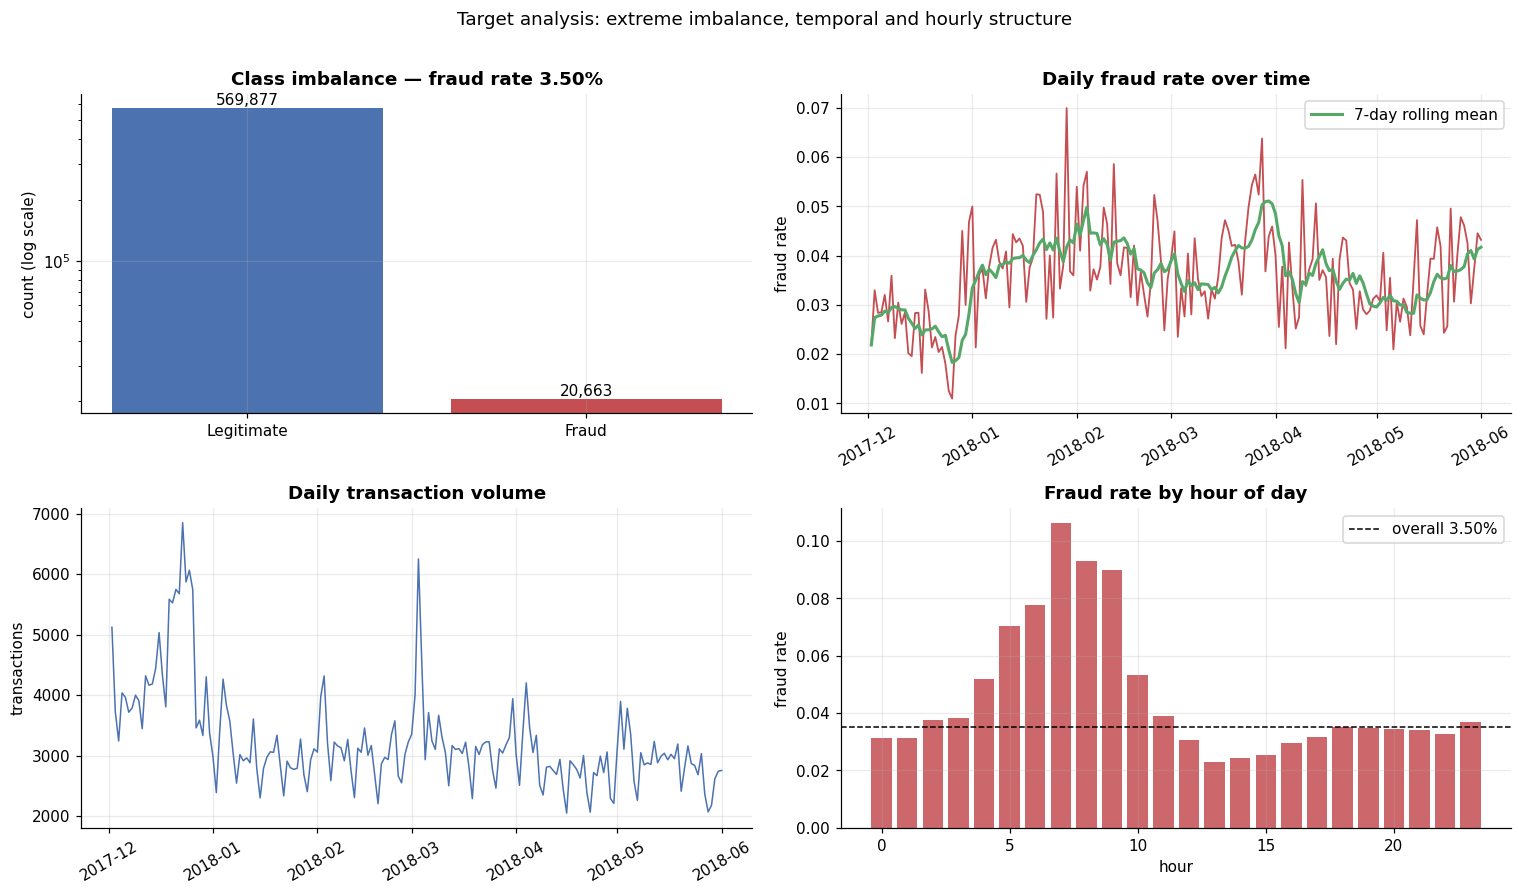


Fraud rate range across days: 1.10% - 6.99% -> the prior itself drifts, which the drift analysis in Section 19 revisits.


In [13]:
# --- Class balance -------------------------------------------------------------------------------
counts = df["isFraud"].value_counts().sort_index()
rate = df["isFraud"].mean()
imbalance = counts[0] / counts[1]
print(f"Legitimate : {counts[0]:>9,}  ({100 * (1 - rate):.3f}%)")
print(f"Fraud      : {counts[1]:>9,}  ({100 * rate:.3f}%)")
print(f"Imbalance  : 1 fraud per {imbalance:.1f} legitimate transactions")
print(f"\nA 'predict everything legitimate' baseline would score {100 * (1 - rate):.2f}% ACCURACY "
      "and catch 0 frauds.\nThis is exactly why accuracy is not used anywhere in this notebook.")

df["_day"] = (df["TransactionDT"] // 86400).astype("int32")
df["_hour"] = ((df["TransactionDT"] // 3600) % 24).astype("int8")
daily = df.groupby("_day").agg(n=("isFraud", "size"), fraud=("isFraud", "sum"))
daily["rate"] = daily["fraud"] / daily["n"]
daily["date"] = as_datetime(daily.index * 86400)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes[0, 0]
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log"); ax.set_ylabel("count (log scale)")
ax.set_title(f"Class imbalance — fraud rate {rate:.2%}")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom")

ax = axes[0, 1]
ax.plot(daily["date"], daily["rate"], lw=1.2, color="#C44E52")
ax.plot(daily["date"], daily["rate"].rolling(7, min_periods=1).mean(), lw=2, color="#55A868",
        label="7-day rolling mean")
ax.set_title("Daily fraud rate over time"); ax.set_ylabel("fraud rate"); ax.legend()
ax.tick_params(axis="x", rotation=30)

ax = axes[1, 0]
ax.plot(daily["date"], daily["n"], lw=1, color="#4C72B0")
ax.set_title("Daily transaction volume"); ax.set_ylabel("transactions")
ax.tick_params(axis="x", rotation=30)

ax = axes[1, 1]
hourly = df.groupby("_hour")["isFraud"].agg(["mean", "size"])
ax.bar(hourly.index, hourly["mean"], color="#C44E52", alpha=0.85)
ax.axhline(rate, ls="--", c="k", lw=1, label=f"overall {rate:.2%}")
ax.set_title("Fraud rate by hour of day"); ax.set_xlabel("hour"); ax.set_ylabel("fraud rate"); ax.legend()

fig.suptitle("Target analysis: extreme imbalance, temporal and hourly structure", y=1.01)
fig.tight_layout(); savefig(fig, "01_target_analysis")

print(f"\nFraud rate range across days: {daily['rate'].min():.2%} - {daily['rate'].max():.2%} "
      "-> the prior itself drifts, which the drift analysis in Section 19 revisits.")

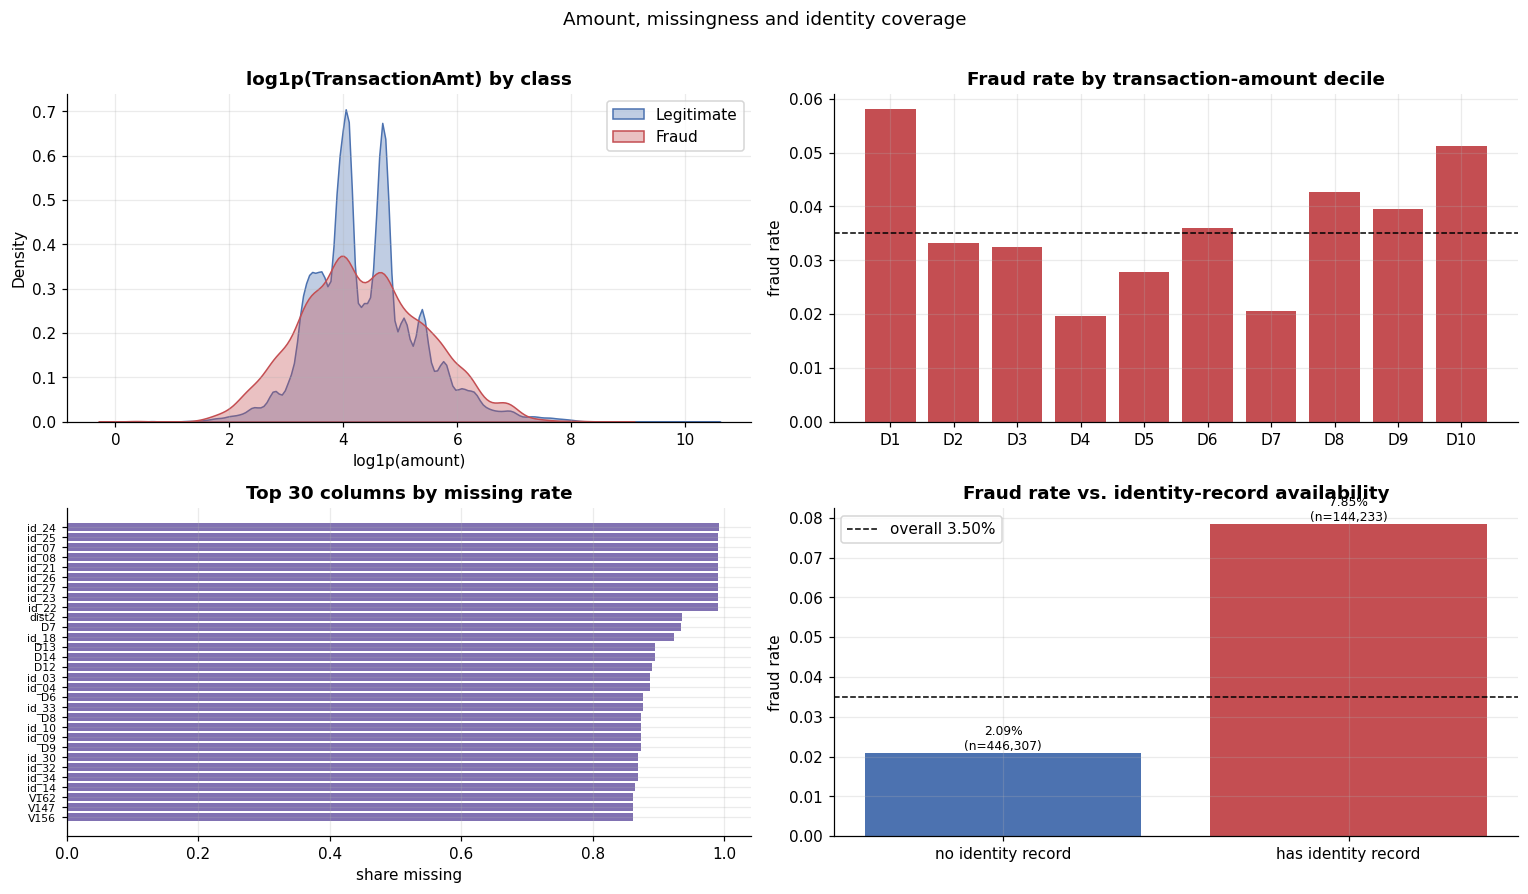

Median amount  — legit: 68.50 | fraud: 75.00
Missingness is not noise here: the identity block is absent for ~76% of rows, and its presence/absence is itself associated with fraud — hence the missingness features in Section 14.


In [14]:
# --- Transaction amount, missingness, categorical fraud rates ------------------------------------
eda = df.sample(min(EDA_SAMPLE_SIZE, len(df)), random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes[0, 0]
for lbl, c in [(0, "#4C72B0"), (1, "#C44E52")]:
    sns.kdeplot(np.log1p(eda.loc[eda.isFraud == lbl, "TransactionAmt"]), ax=ax, fill=True,
                alpha=0.35, color=c, label="Fraud" if lbl else "Legitimate")
ax.set_title("log1p(TransactionAmt) by class"); ax.set_xlabel("log1p(amount)"); ax.legend()

ax = axes[0, 1]
q = eda.groupby(pd.qcut(eda["TransactionAmt"], 10, duplicates="drop"),
                observed=True)["isFraud"].mean()
ax.bar(range(len(q)), q.values, color="#C44E52")
ax.axhline(rate, ls="--", c="k", lw=1)
ax.set_xticks(range(len(q)))
ax.set_xticklabels([f"D{i+1}" for i in range(len(q))])
ax.set_title("Fraud rate by transaction-amount decile"); ax.set_ylabel("fraud rate")

ax = axes[1, 0]
miss = df.isna().mean().sort_values(ascending=False).head(30)
ax.barh(range(len(miss)), miss.values[::-1], color="#8172B2")
ax.set_yticks(range(len(miss))); ax.set_yticklabels(miss.index[::-1], fontsize=7)
ax.set_title("Top 30 columns by missing rate"); ax.set_xlabel("share missing")

ax = axes[1, 1]
mr = df.groupby("has_identity")["isFraud"].agg(["mean", "size"])
ax.bar(["no identity record", "has identity record"], mr["mean"], color=["#4C72B0", "#C44E52"])
ax.axhline(rate, ls="--", c="k", lw=1, label=f"overall {rate:.2%}")
ax.set_title("Fraud rate vs. identity-record availability"); ax.set_ylabel("fraud rate"); ax.legend()
for i, (m, n) in enumerate(zip(mr["mean"], mr["size"])):
    ax.text(i, m, f"{m:.2%}\n(n={n:,})", ha="center", va="bottom", fontsize=8)

fig.suptitle("Amount, missingness and identity coverage", y=1.01)
fig.tight_layout(); savefig(fig, "02_amount_missingness")

print("Median amount  — legit: "
      f"{df.loc[df.isFraud == 0, 'TransactionAmt'].median():.2f} | "
      f"fraud: {df.loc[df.isFraud == 1, 'TransactionAmt'].median():.2f}")
print("Missingness is not noise here: the identity block is absent for ~76% of rows, and its "
      "presence/absence is itself associated with fraud — hence the missingness features in Section 14.")

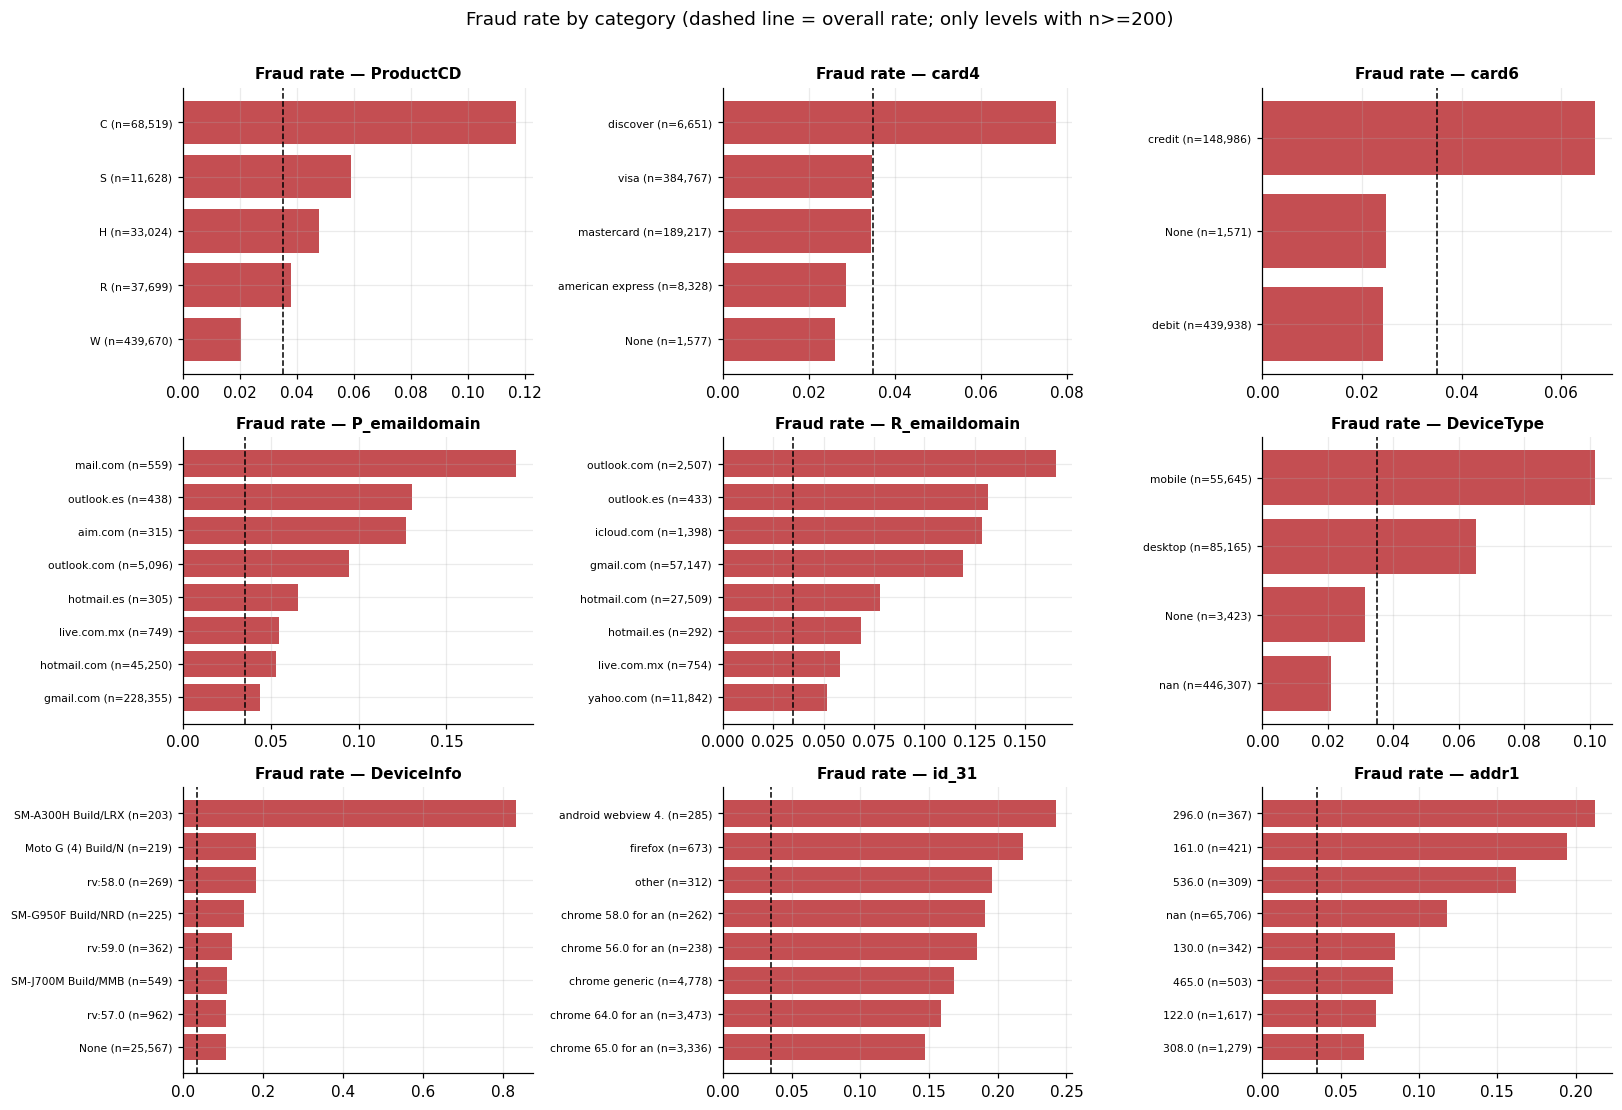

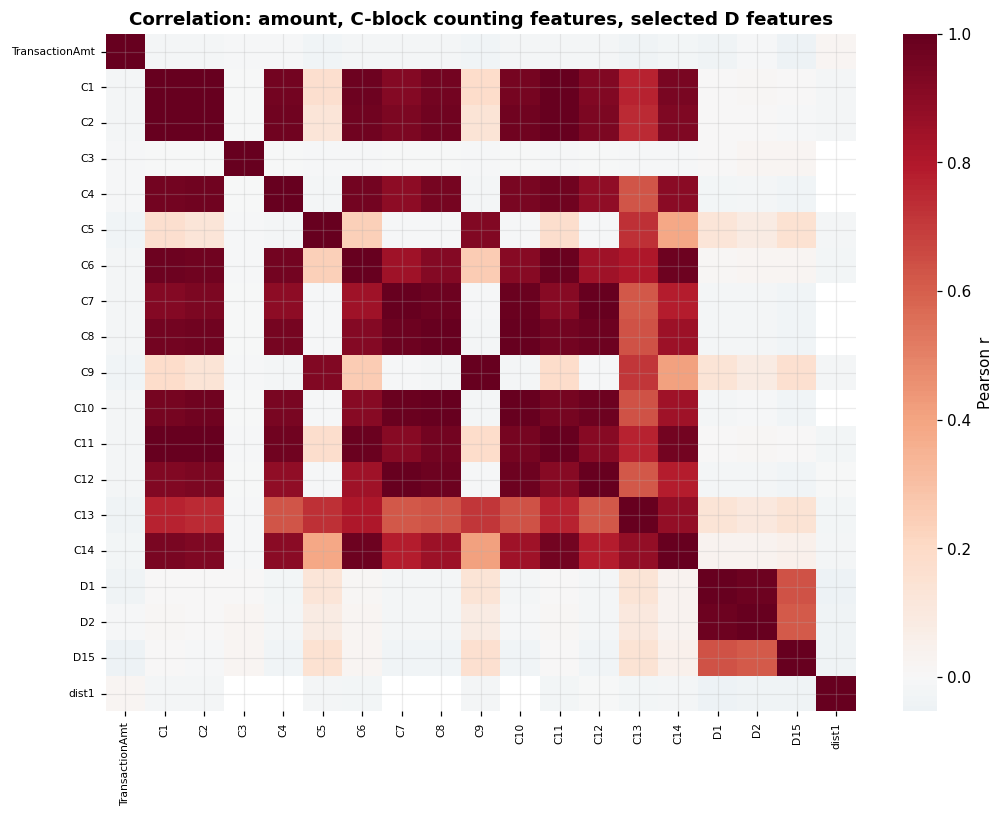

Most correlated pairs (|r|):
  C12            ~ C7             r = 0.999
  C7             ~ C12            r = 0.999
  C10            ~ C8             r = 0.997
  C8             ~ C10            r = 0.997
  C1             ~ C11            r = 0.996

The C-block is highly collinear — one more reason the anomaly track uses a curated, de-duplicated feature subset rather than every available column.


In [15]:
# --- Fraud rate by key categorical variables -----------------------------------------------------
def fraud_rate_plot(ax, col, top=8, min_n=200):
    if col not in df.columns:
        ax.set_visible(False); return
    g = df.groupby(df[col].astype(str), observed=True)["isFraud"].agg(["mean", "size"])
    g = g[g["size"] >= min_n].sort_values("mean", ascending=False).head(top)
    if g.empty:
        ax.set_visible(False); return
    ax.barh(range(len(g)), g["mean"].values[::-1], color="#C44E52")
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f"{i[:18]} (n={int(n):,})" for i, n in
                        zip(g.index[::-1], g["size"].values[::-1])], fontsize=7)
    ax.axvline(rate, ls="--", c="k", lw=1)
    ax.set_title(f"Fraud rate — {col}", fontsize=10)

cat_targets = ["ProductCD", "card4", "card6", "P_emaildomain",
               "R_emaildomain", "DeviceType", "DeviceInfo", "id_31", "addr1"]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), cat_targets):
    fraud_rate_plot(ax, col)
fig.suptitle("Fraud rate by category (dashed line = overall rate; only levels with n>=200)", y=1.005)
fig.tight_layout(); savefig(fig, "03_fraud_by_category")

# Correlation among the C-block (counting features) plus amount — used later for anomaly features.
c_cols = [c for c in df.columns if c.startswith("C") and c[1:].isdigit()]
corr_cols = ["TransactionAmt"] + c_cols + [c for c in ["D1", "D2", "D15", "dist1"] if c in df.columns]
corr = df[corr_cols].sample(min(100_000, len(df)), random_state=SEED).corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, square=False,
            cbar_kws={"label": "Pearson r"}, xticklabels=True, yticklabels=True)
ax.set_title("Correlation: amount, C-block counting features, selected D features")
plt.setp(ax.get_xticklabels(), fontsize=7, rotation=90)
plt.setp(ax.get_yticklabels(), fontsize=7)
savefig(fig, "04_correlation")

hi = (corr.abs().where(~np.eye(len(corr), dtype=bool)).stack().sort_values(ascending=False).head(5))
print("Most correlated pairs (|r|):")
for (a, b), v in hi.items():
    print(f"  {a:<14} ~ {b:<14} r = {v:.3f}")
print("\nThe C-block is highly collinear — one more reason the anomaly track uses a curated, "
      "de-duplicated feature subset rather than every available column.")

## 7. Data Leakage Audit

**What:** an explicit, documented decision for every column that will *not* be used as a model input.

**Why this section is mandatory.** Leakage is the single most common way a fraud model produces a
beautiful benchmark score and then fails in production. There are three distinct risks here:

1. **Target leakage** — `isFraud` itself, obviously excluded.
2. **Identifier leakage** — `TransactionID` is a monotonically increasing row counter. A tree model
   would happily split on it and memorise the time ordering, which cannot generalise to future data.
3. **Temporal leakage** — `TransactionDT` is an absolute timestamp. Because the split is chronological,
   *every* test row has a larger `TransactionDT` than every train row, so any split on it is pure
   memorisation. We keep the *derived* features (hour of day, day of week, relative day index) which
   do carry generalisable signal, and drop the raw timestamp from the feature matrix.

**What is deliberately kept:** we do **not** blindly drop all IDs. `card1`–`card6`, `addr1/2` and the
`id_*` identity columns are entity attributes, not row identifiers — they are exactly the fields a
fraud analyst reasons about, and they repeat across rows, so they generalise.

**Honest caveat, recorded in the audit table:** the anonymised `V*`, `C*` and `D*` blocks are
Vesta-engineered aggregations. Their computation windows are undisclosed, so we cannot fully verify
that none of them peeks forward in time. This is an inherent, unresolvable property of the benchmark
and is repeated in the Limitations section rather than hidden.

In [16]:
# --- Leakage audit table -------------------------------------------------------------------------
TARGET = "isFraud"
ID_COL = "TransactionID"
TIME_COL = "TransactionDT"

audit_rows = [
    (TARGET, "target", "excluded from features",
     "The label itself. Used as y, and by the anomaly track only for evaluation/threshold choice."),
    (ID_COL, "identifier", "excluded from features",
     "Monotonically increasing row counter. Perfectly correlated with time -> memorisation, zero "
     "generalisable signal. Retained as a key for joins and for the investigation table."),
    (TIME_COL, "raw timestamp", "excluded from features",
     "Absolute time. Under a chronological split every test value exceeds every train value, so a "
     "split on it is leakage. Derived hour / weekday / relative-day features are kept instead."),
]

# Programmatically detected exclusions
const_cols = [c for c in df.columns if c not in ("_day", "_hour") and df[c].nunique(dropna=False) <= 1]
for c in const_cols:
    audit_rows.append((c, "constant", "excluded from features",
                       "Single value across the whole dataset: no information, wastes memory."))

miss_rate = df.isna().mean()
almost_empty = [c for c in df.columns if miss_rate[c] > 0.99 and c not in (TARGET, ID_COL, TIME_COL)]
for c in almost_empty:
    audit_rows.append((c, "near-empty", "excluded from features",
                       f"{miss_rate[c]:.2%} missing — too sparse to estimate reliably; its "
                       "missingness is captured by a dedicated indicator instead."))

obj_cols = df.select_dtypes(include="object").columns.tolist()
nuniq = df[obj_cols].nunique() if obj_cols else pd.Series(dtype=int)
ultra_high_card = [c for c in obj_cols if nuniq[c] > 5000]
for c in ultra_high_card:
    audit_rows.append((c, "ultra-high-cardinality", "frequency-encoded, raw string dropped",
                       f"{int(nuniq[c]):,} distinct values. One-hot encoding would explode memory; "
                       "the count of occurrences carries the usable signal."))

# Risks that are documented rather than acted upon
audit_rows += [
    ("V1-V339", "anonymised engineered block", "KEPT (documented risk)",
     "Vesta-engineered aggregations with undisclosed computation windows. Cannot be verified "
     "leakage-free; retained because excluding them would gut the benchmark. See Limitations."),
    ("C1-C14", "counting features", "KEPT (documented risk)",
     "Counts of prior associations (addresses, cards). Almost certainly backward-looking, but the "
     "exact window is undisclosed."),
    ("D1-D15", "timedelta features", "KEPT (documented risk)",
     "Days since a previous event. Backward-looking by construction; D1 is additionally normalised "
     "to a client-tenure feature in Section 9."),
    ("card1-card6, addr1/2, id_*", "entity attributes", "KEPT",
     "Not row identifiers: they repeat across transactions and are exactly the entities a fraud "
     "analyst reasons about. Kept as features and as aggregation keys."),
]

leakage_audit = pd.DataFrame(audit_rows, columns=["column", "type", "decision", "reason"])
leakage_audit.to_csv(os.path.join(DIRS["reports"], "leakage_audit.csv"), index=False)

EXCLUDE_COLS = set([TARGET, ID_COL, TIME_COL] + const_cols + almost_empty + ["_day", "_hour"])
print(f"Columns excluded from the feature matrix : {len(EXCLUDE_COLS)}")
print(f"  constant      : {len(const_cols)} {const_cols[:5]}")
print(f"  >99% missing  : {len(almost_empty)} {almost_empty[:5]}")
print(f"  ultra-high-cardinality (freq-encoded, raw dropped): {ultra_high_card}")
print(f"\nLeakage audit saved to {os.path.join(DIRS['reports'], 'leakage_audit.csv')}\n")
display(leakage_audit.head(20).style.hide(axis="index"))

Columns excluded from the feature matrix : 14
  constant      : 0 []
  >99% missing  : 9 ['id_07', 'id_08', 'id_21', 'id_22', 'id_23']
  ultra-high-cardinality (freq-encoded, raw dropped): []

Leakage audit saved to /content/drive/MyDrive/ieee_cis_fraud_detection/reports/leakage_audit.csv



column,type,decision,reason
isFraud,target,excluded from features,"The label itself. Used as y, and by the anomaly track only for evaluation/threshold choice."
TransactionID,identifier,excluded from features,"Monotonically increasing row counter. Perfectly correlated with time -> memorisation, zero generalisable signal. Retained as a key for joins and for the investigation table."
TransactionDT,raw timestamp,excluded from features,"Absolute time. Under a chronological split every test value exceeds every train value, so a split on it is leakage. Derived hour / weekday / relative-day features are kept instead."
id_07,near-empty,excluded from features,99.13% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_08,near-empty,excluded from features,99.13% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_21,near-empty,excluded from features,99.13% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_22,near-empty,excluded from features,99.12% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_23,near-empty,excluded from features,99.12% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_24,near-empty,excluded from features,99.20% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.
id_25,near-empty,excluded from features,99.13% missing — too sparse to estimate reliably; its missingness is captured by a dedicated indicator instead.


## 8. Temporal Train / Validation / Test Split

**What:** a strictly chronological 70 / 15 / 15 split on `TransactionDT`.

**Why not a random split.** A random split lets the model see transactions from the *same card, same
day, same fraud campaign* on both sides of the split. Published work on this dataset shows random
splits inflating scores substantially versus time-based ones. Deployment always means "train on the
past, score the future", so the evaluation must simulate exactly that.

**Boundary handling:** rows whose timestamp equals a cut point are assigned to the *later* split. That
guarantees the strict inequalities `max(train) < min(val)` and `max(val) < min(test)`, which are
asserted below rather than assumed.

**Test-set discipline:** from here until Section 14 the test set is only ever *transformed*, never
looked at. Model selection, hyperparameter tuning and threshold selection all happen on validation.

split,rows,share,start,end,days,fraud,fraud_rate
train,"413,378",70.0%,2017-12-02 00:00,2018-03-31 19:26,120,"14,538",3.517%
validation,"88,581",15.0%,2018-03-31 19:26,2018-05-02 05:17,31,"3,042",3.434%
test,"88,581",15.0%,2018-05-02 05:18,2018-06-01 23:58,31,"3,083",3.480%



Strict temporal ordering verified: max(train) < min(val) and max(val) < min(test).
Fraud rate drifts across splits: 3.517% -> 3.434% -> 3.480%  (a real, in-sample example of concept drift)


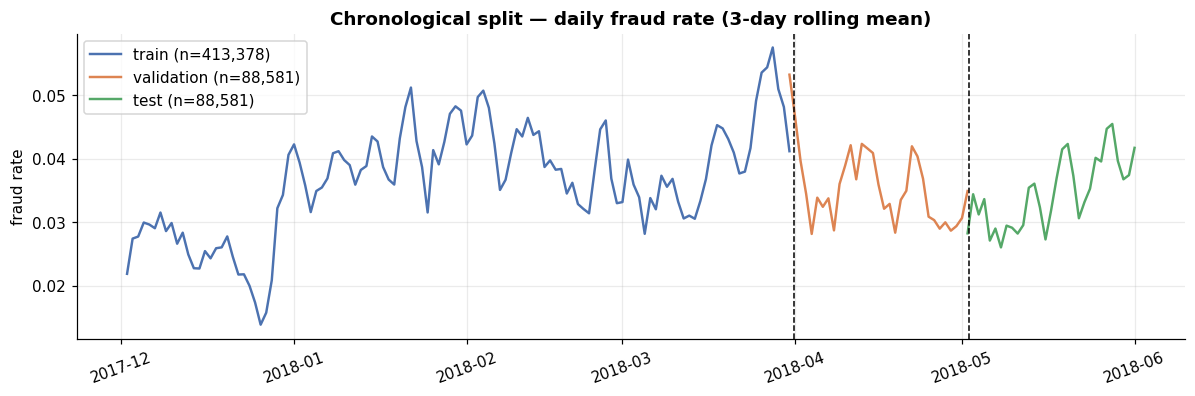

[MEM] after split                      process=3.61 GB | system used=4.37/13.6 GB (34%) | available=8.93 GB


In [17]:
# --- Chronological split -------------------------------------------------------------------------
dt = df[TIME_COL].to_numpy()
cut1, cut2 = np.quantile(dt, TRAIN_FRAC), np.quantile(dt, TRAIN_FRAC + VAL_FRAC)

train_mask = dt < cut1
val_mask   = (dt >= cut1) & (dt < cut2)
test_mask  = dt >= cut2

train_df = df.loc[train_mask].reset_index(drop=True)
val_df   = df.loc[val_mask].reset_index(drop=True)
test_df  = df.loc[test_mask].reset_index(drop=True)

assert train_df[TIME_COL].max() < val_df[TIME_COL].min(), "train/val overlap in time"
assert val_df[TIME_COL].max() < test_df[TIME_COL].min(), "val/test overlap in time"
assert len(train_df) + len(val_df) + len(test_df) == len(df), "rows lost in the split"

rows = []
for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    rows.append({
        "split": name, "rows": len(part), "share": len(part) / len(df),
        "start": as_datetime(part[TIME_COL].min()).strftime("%Y-%m-%d %H:%M"),
        "end": as_datetime(part[TIME_COL].max()).strftime("%Y-%m-%d %H:%M"),
        "days": (part[TIME_COL].max() - part[TIME_COL].min()) / 86400,
        "fraud": int(part[TARGET].sum()), "fraud_rate": part[TARGET].mean(),
    })
split_summary = pd.DataFrame(rows)
display(split_summary.style.format({"share": "{:.1%}", "fraud_rate": "{:.3%}",
                                    "rows": "{:,}", "fraud": "{:,}", "days": "{:.0f}"})
        .hide(axis="index"))
split_summary.to_csv(os.path.join(DIRS["reports"], "split_summary.csv"), index=False)
save_json({"cut1_dt": float(cut1), "cut2_dt": float(cut2),
           "cut1_date": str(as_datetime(cut1)), "cut2_date": str(as_datetime(cut2)),
           "splits": rows}, "split_metadata.json")

print("\nStrict temporal ordering verified: max(train) < min(val) and max(val) < min(test).")
print(f"Fraud rate drifts across splits: "
      f"{split_summary.fraud_rate.iloc[0]:.3%} -> {split_summary.fraud_rate.iloc[1]:.3%} -> "
      f"{split_summary.fraud_rate.iloc[2]:.3%}  (a real, in-sample example of concept drift)")

fig, ax = plt.subplots(figsize=(13, 3.6))
colors = {"train": "#4C72B0", "validation": "#DD8452", "test": "#55A868"}
for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    d = part.groupby("_day")[TARGET].mean()
    ax.plot(as_datetime(d.index * 86400), d.rolling(3, min_periods=1).mean(),
            color=colors[name], lw=1.6, label=f"{name} (n={len(part):,})")
for c in (cut1, cut2):
    ax.axvline(as_datetime(c), ls="--", c="k", lw=1)
ax.set_title("Chronological split — daily fraud rate (3-day rolling mean)")
ax.set_ylabel("fraud rate"); ax.legend(); ax.tick_params(axis="x", rotation=20)
savefig(fig, "05_temporal_split")

free_mem()
mem_report("after split")

## 9. Feature Engineering

**What:** two classes of features, kept deliberately separate.

1. **Row-wise features** — computed from a single transaction only (log amount, cents, hour, weekday,
   email domain parsing, device parsing, missingness counts, client-tenure normalisation `D1n`).
   These carry no leakage risk whatsoever.
2. **Entity aggregation features** — how often a card / address / device / e-mail appears, and how far
   this transaction's amount deviates from that entity's typical amount. Fraud is fundamentally a
   *behavioural deviation* problem, so these are the features that make the anomaly track meaningful.

**Leakage discipline for the aggregations.** Every aggregation table (frequencies, per-entity amount
means and standard deviations, entity-diversity counts) is **fitted on the training split only** and
then *applied* to validation and test. Validation and test therefore contain no information from their
own period — which is exactly the deployment situation: you score a new transaction against statistics
compiled from history.

**Stated limitation (deliberate, not an oversight).** Within the training split, a row is scored
against statistics computed over the *whole* training period, including rows that came after it. Full
point-in-time correctness would require an expanding-window recomputation per row, which is far too
expensive for Colab on 590k rows. The consequence is that training-split features are marginally
optimistic; validation and test — the numbers actually reported — are not affected, because nothing
from their own period ever enters the statistics. No feature anywhere uses information from a
*future* split.

In [18]:
# --- Free the merged frame; keep only the splits -------------------------------------------------
DATASET_META = {
    "rows_total": int(len(train_df) + len(val_df) + len(test_df)),
    "fraud_total": int(train_df[TARGET].sum() + val_df[TARGET].sum() + test_df[TARGET].sum()),
    "columns_loaded": int(train_df.shape[1]),
    "period_start": str(as_datetime(train_df[TIME_COL].min())),
    "period_end": str(as_datetime(test_df[TIME_COL].max())),
    "v_mode": V_MODE, "identity_join_coverage": float(join_cov),
}
DATASET_META["fraud_rate_total"] = DATASET_META["fraud_total"] / DATASET_META["rows_total"]
save_json(DATASET_META, "dataset_metadata.json")

try:
    del df, eda
except NameError:
    pass
gc.collect()
mem_report("before feature engineering")
print(json.dumps(DATASET_META, indent=2))

[MEM] before feature engineering       process=3.33 GB | system used=4.12/13.6 GB (32%) | available=9.18 GB
{
  "rows_total": 590540,
  "fraud_total": 20663,
  "columns_loaded": 218,
  "period_start": "2017-12-02 00:00:00",
  "period_end": "2018-06-01 23:58:51",
  "v_mode": "reduced",
  "identity_join_coverage": 0.2442391709283029,
  "fraud_rate_total": 0.03499000914417313
}


In [19]:
# --- Row-wise feature engineering (no cross-row information) --------------------------------------
MISSING_INDICATOR_COLS = ["dist1", "dist2", "D1", "D15", "card2", "card3", "card5", "addr1",
                          "P_emaildomain", "R_emaildomain", "DeviceInfo", "id_30", "id_31", "id_33"]

def _first_token(s, sep=" "):
    return s.astype(str).str.lower().str.split(sep).str[0]

def engineer_row_features(p: pd.DataFrame) -> pd.DataFrame:
    '''Mutates and returns p. Every feature here depends only on the row itself.'''
    # --- time -------------------------------------------------------------------------------
    p["day_idx"] = (p[TIME_COL] // 86400).astype("int32")      # absolute -> internal use only
    p["hour"]    = ((p[TIME_COL] // 3600) % 24).astype("int8")
    p["dow"]     = (p["day_idx"] % 7).astype("int8")
    p["is_night"] = (p["hour"] < 7).astype("int8")
    p["is_weekend"] = (p["dow"] >= 5).astype("int8")

    # --- amount -----------------------------------------------------------------------------
    amt = p["TransactionAmt"].astype("float32")
    p["amt_log"] = np.log1p(amt).astype("float32")
    cents = ((amt - np.floor(amt)) * 1000).round().astype("int32")
    p["amt_cents"] = cents.astype("float32")
    p["amt_is_round"] = (cents == 0).astype("int8")

    # --- client tenure: D1/D15 are "days since <event>"; day_idx - D column is ~constant per client
    for d in ["D1", "D15"]:
        if d in p.columns:
            p[f"{d}n"] = (p["day_idx"] - p[d]).astype("float32")

    # --- e-mail domains ---------------------------------------------------------------------
    for pre in ["P", "R"]:
        col = f"{pre}_emaildomain"
        if col in p.columns:
            base = p[col].astype(str)
            p[f"{pre}_email_bin"] = base.str.split(".").str[0].where(base != "nan", np.nan)
            p[f"{pre}_email_suffix"] = base.str.split(".").str[-1].where(base != "nan", np.nan)
    if {"P_emaildomain", "R_emaildomain"}.issubset(p.columns):
        p["email_match"] = (p["P_emaildomain"].astype(str) == p["R_emaildomain"].astype(str)).astype("int8")

    # --- device / browser / OS --------------------------------------------------------------
    if "DeviceInfo" in p.columns:
        p["device_name"] = _first_token(p["DeviceInfo"]).where(p["DeviceInfo"].notna(), np.nan)
    if "id_30" in p.columns:
        p["os_name"] = _first_token(p["id_30"]).where(p["id_30"].notna(), np.nan)
    if "id_31" in p.columns:
        p["browser_name"] = _first_token(p["id_31"]).where(p["id_31"].notna(), np.nan)
    if "id_33" in p.columns:                                   # screen resolution "1920x1080"
        res = p["id_33"].astype(str).str.split("x")
        p["screen_w"] = pd.to_numeric(res.str[0], errors="coerce").astype("float32")
        p["screen_h"] = pd.to_numeric(res.str[1], errors="coerce").astype("float32")

    # --- composite entity keys (used as aggregation keys, dropped as raw strings later) -------
    p["uid1"] = p["card1"].astype(str) + "_" + p["addr1"].astype(str)
    p["uid2"] = p["uid1"] + "_" + p.get("P_emaildomain", pd.Series("na", index=p.index)).astype(str)

    # --- missingness ------------------------------------------------------------------------
    blocks = {"V": [c for c in p.columns if c.startswith("V") and c[1:].isdigit()],
              "C": [c for c in p.columns if c.startswith("C") and c[1:].isdigit()],
              "D": [c for c in p.columns if c.startswith("D") and c[1:].isdigit()],
              "id": [c for c in p.columns if c.startswith("id_")],
              "M": [c for c in p.columns if c.startswith("M") and c[1:].isdigit()]}
    for name, cols in blocks.items():
        if cols:
            p[f"n_missing_{name}"] = p[cols].isna().sum(axis=1).astype("float32")
    p["n_missing_total"] = p.isna().sum(axis=1).astype("float32")
    for c in MISSING_INDICATOR_COLS:
        if c in p.columns:
            p[f"{c}_is_missing"] = p[c].isna().astype("int8")
    return p

with timed("row-wise feature engineering"):
    for part in (train_df, val_df, test_df):
        engineer_row_features(part)

print(f"Columns after row-wise engineering: {train_df.shape[1]}")
new_cols = [c for c in train_df.columns if c in
            ["amt_log", "amt_cents", "amt_is_round", "hour", "dow", "is_night", "D1n",
             "P_email_bin", "device_name", "browser_name", "n_missing_V", "n_missing_total"]]
print(f"Examples of new features: {new_cols}")
mem_report("after row-wise FE")

[10:14:33] START  row-wise feature engineering
[10:14:53] DONE   row-wise feature engineering in 20.3s
Columns after row-wise engineering: 260
Examples of new features: ['hour', 'dow', 'is_night', 'amt_log', 'amt_cents', 'amt_is_round', 'D1n', 'P_email_bin', 'device_name', 'browser_name', 'n_missing_V', 'n_missing_total']
[MEM] after row-wise FE                process=3.58 GB | system used=4.29/13.6 GB (34%) | available=9.01 GB


In [20]:
# --- Entity aggregation features (statistics fitted on TRAIN ONLY) -------------------------------
FREQ_KEYS = ["card1", "card2", "card3", "card5", "addr1", "P_emaildomain", "R_emaildomain",
             "device_name", "browser_name", "uid1", "uid2"]
AMT_KEYS  = ["card1", "addr1", "uid1"]
DIVERSITY = [("card1", "device_name"), ("device_name", "card1"), ("card1", "addr1"), ("uid1", "hour")]

def fit_group_stats(tr: pd.DataFrame) -> dict:
    stats = {"freq": {}, "amt": {}, "diversity": {}, "n_train": int(len(tr))}
    for k in FREQ_KEYS:
        if k in tr.columns:
            vc = tr[k].astype(str).value_counts()
            stats["freq"][k] = (vc / len(tr)).astype("float32").to_dict()
    for k in AMT_KEYS:
        if k in tr.columns:
            g = tr.groupby(tr[k].astype(str), observed=True)["TransactionAmt"]
            stats["amt"][k] = {"mean": g.mean().astype("float32").to_dict(),
                               "std": g.std().fillna(0).astype("float32").to_dict()}
    for key, target_col in DIVERSITY:
        if key in tr.columns and target_col in tr.columns:
            g = tr.groupby(tr[key].astype(str), observed=True)[target_col].nunique()
            stats["diversity"][f"{key}__{target_col}"] = g.astype("float32").to_dict()
    stats["global_amt_mean"] = float(tr["TransactionAmt"].mean())
    stats["global_amt_std"] = float(tr["TransactionAmt"].std())
    return stats

def apply_group_stats(p: pd.DataFrame, stats: dict) -> pd.DataFrame:
    for k, mapping in stats["freq"].items():
        p[f"{k}_freq"] = p[k].astype(str).map(mapping).fillna(0.0).astype("float32")
    for k, d in stats["amt"].items():
        m = p[k].astype(str).map(d["mean"]).astype("float32")
        s = p[k].astype(str).map(d["std"]).astype("float32")
        p[f"amt_ratio_{k}"] = (p["TransactionAmt"] / m.replace(0, np.nan)).astype("float32")
        # Entities seen once have std 0; a tiny epsilon would produce absurd z-scores, so the
        # denominator is floored at $1 and the result clipped to a readable range.
        p[f"amt_z_{k}"] = (((p["TransactionAmt"] - m) / s.clip(lower=1.0))
                           .clip(-50, 50).astype("float32"))
    for name, mapping in stats["diversity"].items():
        key = name.split("__")[0]
        p[f"nuniq_{name}"] = p[key].astype(str).map(mapping).fillna(0.0).astype("float32")
    return p

with timed("fitting entity statistics on TRAIN only"):
    GROUP_STATS = fit_group_stats(train_df)
with timed("applying entity statistics to all splits"):
    for part in (train_df, val_df, test_df):
        apply_group_stats(part, GROUP_STATS)

agg_cols = [c for c in train_df.columns
            if c.endswith("_freq") or c.startswith(("amt_ratio_", "amt_z_", "nuniq_"))]
print(f"Created {len(agg_cols)} entity-aggregation features:")
print(" ", agg_cols)

# Sanity: unseen entities in later splits get frequency 0 — that is meaningful, not a bug.
unseen = (val_df["uid1_freq"] == 0).mean()
print(f"\nShare of validation rows whose card1_addr1 entity was never seen in training: {unseen:.1%}")
print("Fraud rate for those rows: "
      f"{val_df.loc[val_df.uid1_freq == 0, TARGET].mean():.2%} vs "
      f"{val_df.loc[val_df.uid1_freq > 0, TARGET].mean():.2%} for known entities.")
mem_report("after aggregation FE")

[10:14:53] START  fitting entity statistics on TRAIN only
[10:14:59] DONE   fitting entity statistics on TRAIN only in 5.4s
[10:14:59] START  applying entity statistics to all splits
[10:15:05] DONE   applying entity statistics to all splits in 6.7s
Created 21 entity-aggregation features:
  ['card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'device_name_freq', 'browser_name_freq', 'uid1_freq', 'uid2_freq', 'amt_ratio_card1', 'amt_z_card1', 'amt_ratio_addr1', 'amt_z_addr1', 'amt_ratio_uid1', 'amt_z_uid1', 'nuniq_card1__device_name', 'nuniq_device_name__card1', 'nuniq_card1__addr1', 'nuniq_uid1__hour']

Share of validation rows whose card1_addr1 entity was never seen in training: 4.3%
Fraud rate for those rows: 4.28% vs 3.40% for known entities.
[MEM] after aggregation FE             process=3.62 GB | system used=4.32/13.6 GB (34%) | available=8.98 GB


### 14. Missingness features — do they actually carry signal?

Missing values in this dataset are not random. The identity block is absent for ~76% of transactions,
and `dist`, `D` and several `id_*` fields are missing in patterns that correlate with the channel a
transaction came through. The check below compares each indicator's mean between fraud and non-fraud
in the **training split only**, so it is a legitimate feature-selection diagnostic rather than a peek
at held-out data.

feature,non_fraud_mean,fraud_mean,abs_gap,ratio
n_missing_total,103.508,85.945,17.563,0.83
n_missing_V,49.144,39.497,9.647,0.80
n_missing_id,31.945,24.961,6.984,0.78
n_missing_D,8.918,7.665,1.253,0.86
n_missing_M,4.981,6.132,1.151,1.23
R_emaildomain_is_missing,0.762,0.455,0.307,0.60
id_31_is_missing,0.751,0.451,0.300,0.60
has_identity,0.255,0.553,0.297,2.16
addr1_is_missing,0.106,0.368,0.262,3.48
DeviceInfo_is_missing,0.786,0.573,0.213,0.73


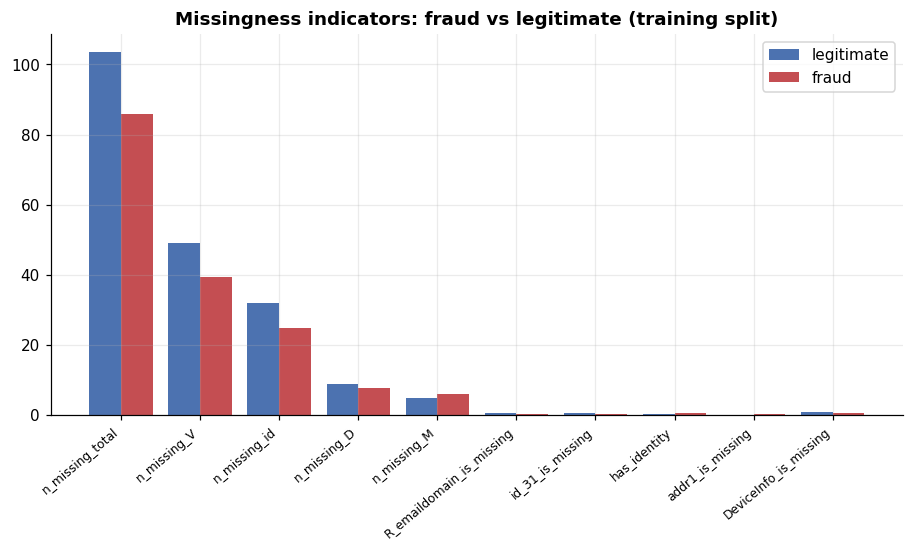

Indicators with a visible gap are kept as model features — 'this field was absent' is itself a behavioural signal, and imputation alone would erase it.


In [21]:
# --- Is missingness informative? (train split only) ----------------------------------------------
ind_cols = [c for c in train_df.columns if c.endswith("_is_missing")] + \
           [c for c in train_df.columns if c.startswith("n_missing_")] + ["has_identity"]
rows = []
for c in ind_cols:
    v = train_df[c].astype("float32")
    m0, m1 = v[train_df[TARGET] == 0].mean(), v[train_df[TARGET] == 1].mean()
    rows.append({"feature": c, "non_fraud_mean": m0, "fraud_mean": m1,
                 "abs_gap": abs(m1 - m0), "ratio": (m1 + 1e-9) / (m0 + 1e-9)})
miss_signal = pd.DataFrame(rows).sort_values("abs_gap", ascending=False)
display(miss_signal.head(12).style.format({"non_fraud_mean": "{:.3f}", "fraud_mean": "{:.3f}",
                                           "abs_gap": "{:.3f}", "ratio": "{:.2f}"}).hide(axis="index"))

top = miss_signal.head(10)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(top))
ax.bar(x - 0.2, top["non_fraud_mean"], 0.4, label="legitimate", color="#4C72B0")
ax.bar(x + 0.2, top["fraud_mean"], 0.4, label="fraud", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(top["feature"], rotation=40, ha="right", fontsize=8)
ax.set_title("Missingness indicators: fraud vs legitimate (training split)")
ax.legend(); savefig(fig, "06_missingness_signal")
print("Indicators with a visible gap are kept as model features — 'this field was absent' is itself "
      "a behavioural signal, and imputation alone would erase it.")

## 10. Preprocessing

**What:** turn the engineered frames into two numeric matrices.

* **Supervised matrix** — categoricals become integer codes ranked by training frequency; numerics keep
  their `NaN`s, because gradient-boosted trees handle missingness natively and imputing would destroy
  the signal we just demonstrated.
* **Anomaly matrix** — a compact, curated set of ~50 features: median-imputed, clipped at the training
  0.1/99.9 percentiles, then rank-Gauss transformed with a `QuantileTransformer`. Distance- and
  reconstruction-based detectors are scale-sensitive and are wrecked by the heavy tails in raw
  financial data, so this normalisation is not optional for them.

**Why frequency-rank ordinal encoding instead of one-hot:** `card1` alone has ~13,000 levels and
`uid2` far more. One-hot would produce a matrix that cannot fit in Colab RAM. Frequency encoding
(already added in Section 9) preserves the "how common is this entity" signal, and the ordinal codes
give the tree model something to split on without a dimensionality explosion.

**Fitting discipline:** every encoder, median, clip bound and scaler is fitted on **train only** and
then applied unchanged to validation and test. All of it is persisted so the Gradio app reproduces the
identical transformation at inference time.

In [22]:
# --- Feature inventory ---------------------------------------------------------------------------
INTERNAL_COLS = {"uid1", "uid2", "day_idx", "_day", "_hour"}
DROP_FROM_FEATURES = set(EXCLUDE_COLS) | INTERNAL_COLS | {TARGET, ID_COL, TIME_COL}

FEATURES = [c for c in train_df.columns if c not in DROP_FROM_FEATURES]
CAT_FEATURES = [c for c in FEATURES if train_df[c].dtype == object]
NUM_FEATURES = [c for c in FEATURES if c not in CAT_FEATURES]

print(f"Total model features : {len(FEATURES)}")
print(f"  numeric            : {len(NUM_FEATURES)}")
print(f"  categorical        : {len(CAT_FEATURES)} -> {CAT_FEATURES[:15]}{' ...' if len(CAT_FEATURES) > 15 else ''}")
print(f"Excluded from features: {len(DROP_FROM_FEATURES)} columns (target, ids, raw time, "
      "constants, near-empty columns, raw uid strings)")

card_report = train_df[CAT_FEATURES].nunique().sort_values(ascending=False)
print("\nHighest-cardinality categoricals (train):")
print(card_report.head(8).to_string())

Total model features : 264
  numeric            : 228
  categorical        : 36 -> ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12'] ...
Excluded from features: 17 columns (target, ids, raw time, constants, near-empty columns, raw uid strings)

Highest-cardinality categoricals (train):
DeviceInfo       1546
device_name      1024
id_33             183
id_31             108
id_30              71
R_emaildomain      60
P_emaildomain      59
R_email_bin        46


In [23]:
# --- Encoders fitted on TRAIN only ---------------------------------------------------------------
MAX_CAT_LEVELS = 1000     # rarer levels collapse into the 'other' code

def fit_encoders(tr: pd.DataFrame, cat_cols, num_cols) -> dict:
    enc = {"cat_maps": {}, "num_medians": {}, "num_clip": {},
           "cat_features": list(cat_cols), "num_features": list(num_cols)}
    for c in cat_cols:
        vc = tr[c].astype(str).value_counts()
        enc["cat_maps"][c] = {str(v): i for i, v in enumerate(vc.index[:MAX_CAT_LEVELS])}
    for c in num_cols:
        s = pd.to_numeric(tr[c], errors="coerce")
        enc["num_medians"][c] = float(s.median()) if s.notna().any() else 0.0
        lo, hi = s.quantile(0.001), s.quantile(0.999)
        enc["num_clip"][c] = (float(lo) if pd.notna(lo) else 0.0,
                              float(hi) if pd.notna(hi) else 0.0)
    return enc

UNSEEN_CODE, OTHER_CODE = -1, -2

def transform_supervised(p: pd.DataFrame, enc: dict) -> pd.DataFrame:
    '''Numeric matrix for the tree model. NaNs are PRESERVED on purpose.'''
    out = {}
    for c in enc["num_features"]:
        out[c] = pd.to_numeric(p[c], errors="coerce").astype("float32") if c in p.columns else \
                 np.full(len(p), np.nan, dtype="float32")
    for c in enc["cat_features"]:
        if c in p.columns:
            mapped = p[c].astype(str).map(enc["cat_maps"][c])
            mapped = mapped.where(p[c].notna(), UNSEEN_CODE).fillna(OTHER_CODE)
        else:
            mapped = pd.Series(UNSEEN_CODE, index=p.index)
        out[c] = mapped.astype("int32")
    return pd.DataFrame(out, index=p.index)[enc["num_features"] + enc["cat_features"]]

with timed("fitting encoders + transforming all splits"):
    ENCODERS = fit_encoders(train_df, CAT_FEATURES, NUM_FEATURES)
    X_train = transform_supervised(train_df, ENCODERS)
    X_val   = transform_supervised(val_df, ENCODERS)
    X_test  = transform_supervised(test_df, ENCODERS)

y_train = train_df[TARGET].to_numpy().astype("int8")
y_val   = val_df[TARGET].to_numpy().astype("int8")
y_test  = test_df[TARGET].to_numpy().astype("int8")
amt_val  = val_df["TransactionAmt"].to_numpy().astype("float32")
amt_test = test_df["TransactionAmt"].to_numpy().astype("float32")

MODEL_FEATURES = list(X_train.columns)
assert list(X_val.columns) == MODEL_FEATURES == list(X_test.columns), "feature order mismatch"
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
print(f"positives: train {y_train.sum():,} | val {y_val.sum():,} | test {y_test.sum():,}")
mem_report("after supervised matrices")

[10:15:07] START  fitting encoders + transforming all splits
[10:15:22] DONE   fitting encoders + transforming all splits in 14.8s
X_train (413378, 264) | X_val (88581, 264) | X_test (88581, 264)
positives: train 14,538 | val 3,042 | test 3,083
[MEM] after supervised matrices        process=4.22 GB | system used=4.93/13.6 GB (38%) | available=8.37 GB


In [24]:
# --- Anomaly matrix: curated features, imputed, clipped, rank-Gauss scaled ------------------------
ANOM_CANDIDATES = [
    "TransactionAmt", "amt_log", "amt_cents", "amt_is_round", "hour", "dow", "is_night", "is_weekend",
    "dist1", "dist2", "email_match", "has_identity",
    "C1", "C2", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D10", "D15", "D1n", "D15n",
    "card1_freq", "card2_freq", "card5_freq", "addr1_freq", "P_emaildomain_freq",
    "device_name_freq", "browser_name_freq", "uid1_freq", "uid2_freq",
    "amt_ratio_card1", "amt_z_card1", "amt_ratio_uid1", "amt_z_uid1", "amt_ratio_addr1",
    "nuniq_card1__device_name", "nuniq_device_name__card1", "nuniq_card1__addr1", "nuniq_uid1__hour",
    "n_missing_V", "n_missing_id", "n_missing_total",
    "id_01", "id_02", "id_05", "id_06", "id_11", "id_13", "id_17", "id_19", "id_20",
    "V44", "V86", "V258", "V294", "V307", "V310",
]
ANOM_FEATURES = [c for c in ANOM_CANDIDATES if c in X_train.columns]
print(f"Anomaly feature set: {len(ANOM_FEATURES)} of {len(ANOM_CANDIDATES)} candidates present.")
missing_cand = [c for c in ANOM_CANDIDATES if c not in X_train.columns]
if missing_cand:
    print(f"  (not available with V_MODE='{V_MODE}': {missing_cand})")

def build_anomaly_matrix(X: pd.DataFrame, enc: dict, scaler=None, fit=False, sample_for_fit=200_000):
    A = X[ANOM_FEATURES].copy()
    for c in ANOM_FEATURES:                        # impute + clip with TRAIN statistics
        lo, hi = enc["num_clip"].get(c, (None, None))
        A[c] = A[c].fillna(enc["num_medians"].get(c, 0.0))
        if lo is not None and hi is not None and hi > lo:
            A[c] = A[c].clip(lo, hi)
    A = A.to_numpy(dtype="float32")
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    if fit:
        n_fit = min(sample_for_fit, len(A))
        idx = np.random.RandomState(SEED).choice(len(A), n_fit, replace=False)
        scaler = QuantileTransformer(output_distribution="normal", n_quantiles=1000,
                                     subsample=200_000, random_state=SEED)
        scaler.fit(A[idx])
        print(f"QuantileTransformer fitted on {n_fit:,} training rows "
              f"({len(ANOM_FEATURES)} features -> rank-Gauss).")
    return scaler.transform(A).astype("float32"), scaler

with timed("building anomaly matrices"):
    A_train, ANOM_SCALER = build_anomaly_matrix(X_train, ENCODERS, fit=True)
    A_val, _  = build_anomaly_matrix(X_val, ENCODERS, scaler=ANOM_SCALER)
    A_test, _ = build_anomaly_matrix(X_test, ENCODERS, scaler=ANOM_SCALER)

print(f"A_train {A_train.shape} | A_val {A_val.shape} | A_test {A_test.shape}  "
      f"({A_train.nbytes / 1e6:.0f} MB for train)")
print(f"After scaling: mean={A_train.mean():.3f}, std={A_train.std():.3f} "
      "(rank-Gauss makes every feature comparable, which distance/reconstruction methods require).")
mem_report("after anomaly matrices")

Anomaly feature set: 69 of 69 candidates present.
[10:15:22] START  building anomaly matrices
QuantileTransformer fitted on 200,000 training rows (69 features -> rank-Gauss).
[10:15:32] DONE   building anomaly matrices in 9.9s
A_train (413378, 69) | A_val (88581, 69) | A_test (88581, 69)  (114 MB for train)
After scaling: mean=-0.750, std=2.903 (rank-Gauss makes every feature comparable, which distance/reconstruction methods require).
[MEM] after anomaly matrices           process=4.38 GB | system used=5.11/13.6 GB (40%) | available=8.20 GB


## 11. Unsupervised Anomaly Detection

**The core of the project.** None of the three detectors below sees `isFraud` during fitting. They
learn what "normal" looks like and score how far a transaction sits from it.

**Where labels *are* used, stated plainly:** choosing between candidate hyperparameters and picking an
operating threshold both use the *validation* labels. That is realistic — an institution with any
labelled history at all would do the same — but it means these are not "label-free" results end to
end. The distinction that matters is that the **fitting objective** never involves the label, so the
detectors can in principle flag fraud patterns that never appeared in the training labels. The test
set is untouched throughout this section.

**Score convention:** every model outputs a score where **higher = more anomalous**, so all four
models are directly comparable in the evaluation section.

In [25]:
# --- Shared score containers ---------------------------------------------------------------------
VAL_SCORES, TEST_SCORES, MODEL_META, EXPERIMENT_LOG = {}, {}, {}, []

def register_model(name, training_type, uses_labels, params, runtime_s,
                   val_scores, test_scores, notes=""):
    VAL_SCORES[name], TEST_SCORES[name] = np.asarray(val_scores, dtype="float64"), \
                                          np.asarray(test_scores, dtype="float64")
    MODEL_META[name] = {"training_type": training_type, "uses_fraud_labels": uses_labels,
                        "params": params, "runtime_seconds": round(runtime_s, 1), "notes": notes}
    ap = average_precision_score(y_val, VAL_SCORES[name])
    log(f"registered '{name}' | validation PR-AUC = {ap:.4f} | fit time {runtime_s:.1f}s")

def subsample_idx(n, k, seed=SEED):
    if k >= n:
        return np.arange(n)
    return np.random.RandomState(seed).choice(n, k, replace=False)

### 11.1 Isolation Forest

Isolation Forest scores a point by how few random axis-aligned splits are needed to isolate it.
Outliers isolate quickly, so they get short average path lengths.

**On `contamination`:** it is tempting to set `contamination` to the observed fraud rate (~3.5%), but
that conflates two different things. `contamination` only decides where sklearn draws its internal
`predict()` cut-off; it does **not** change the ranking produced by `score_samples()`. Since all
thresholds in this project are chosen on the validation set in Section 13, we leave `contamination`
at `"auto"` and work with the continuous scores. Assuming "anomalous == fraudulent at exactly the
base rate" would also be substantively wrong: most statistical outliers in payments data are unusual
but perfectly legitimate.

A compact 4-point grid over `max_samples` and `max_features` is scored on validation PR-AUC.

In [26]:
# --- Isolation Forest with a small validation-selected grid ---------------------------------------
if_fit_idx = subsample_idx(len(A_train), ANOMALY_SAMPLE_SIZE)
print(f"Fitting Isolation Forest on {len(if_fit_idx):,} of {len(A_train):,} training rows "
      f"({len(ANOM_FEATURES)} features). Estimated cost: low (seconds per configuration).")

IF_GRID = [{"n_estimators": 200, "max_samples": 256,  "max_features": 1.0},
           {"n_estimators": 200, "max_samples": 4096, "max_features": 1.0},
           {"n_estimators": 300, "max_samples": 1024, "max_features": 0.6},
           {"n_estimators": 300, "max_samples": 4096, "max_features": 0.8}]

if_results, best_if, best_ap, t_if0 = [], None, -1.0, time.time()
with timed("Isolation Forest grid"):
    for params in IF_GRID:
        m = IsolationForest(random_state=SEED, n_jobs=-1, contamination="auto",
                            bootstrap=False, **params)
        m.fit(A_train[if_fit_idx])
        s_val = -m.score_samples(A_val)               # higher = more anomalous
        ap = average_precision_score(y_val, s_val)
        auc = roc_auc_score(y_val, s_val)
        if_results.append({**params, "val_PR_AUC": ap, "val_ROC_AUC": auc})
        print(f"  {params} -> val PR-AUC {ap:.4f} | ROC-AUC {auc:.4f}")
        if ap > best_ap:
            best_ap, best_if, best_params = ap, m, params
if_runtime = time.time() - t_if0

display(pd.DataFrame(if_results).sort_values("val_PR_AUC", ascending=False)
        .style.format({"val_PR_AUC": "{:.4f}", "val_ROC_AUC": "{:.4f}"}).hide(axis="index"))
print(f"\nSelected: {best_params}  (validation PR-AUC {best_ap:.4f})")

iso_forest = best_if
register_model("Isolation Forest", "unsupervised", False, best_params, if_runtime,
               -iso_forest.score_samples(A_val), -iso_forest.score_samples(A_test),
               notes=f"fitted on {len(if_fit_idx):,} rows; contamination='auto' (thresholds set on validation)")
print(f"Fraud-rate lift check — mean anomaly score, validation: "
      f"fraud {VAL_SCORES['Isolation Forest'][y_val == 1].mean():.4f} vs "
      f"legit {VAL_SCORES['Isolation Forest'][y_val == 0].mean():.4f}")

Fitting Isolation Forest on 100,000 of 413,378 training rows (69 features). Estimated cost: low (seconds per configuration).
[10:15:32] START  Isolation Forest grid
  {'n_estimators': 200, 'max_samples': 256, 'max_features': 1.0} -> val PR-AUC 0.1722 | ROC-AUC 0.7637
  {'n_estimators': 200, 'max_samples': 4096, 'max_features': 1.0} -> val PR-AUC 0.1479 | ROC-AUC 0.7587
  {'n_estimators': 300, 'max_samples': 1024, 'max_features': 0.6} -> val PR-AUC 0.1749 | ROC-AUC 0.7647
  {'n_estimators': 300, 'max_samples': 4096, 'max_features': 0.8} -> val PR-AUC 0.1458 | ROC-AUC 0.7611
[10:16:17] DONE   Isolation Forest grid in 45.5s


n_estimators,max_samples,max_features,val_PR_AUC,val_ROC_AUC
300,1024,0.600000,0.1749,0.7647
200,256,1.000000,0.1722,0.7637
200,4096,1.000000,0.1479,0.7587
300,4096,0.800000,0.1458,0.7611



Selected: {'n_estimators': 300, 'max_samples': 1024, 'max_features': 0.6}  (validation PR-AUC 0.1749)
[10:16:24] registered 'Isolation Forest' | validation PR-AUC = 0.1749 | fit time 45.5s
Fraud-rate lift check — mean anomaly score, validation: fraud 0.4946 vs legit 0.4418


### 11.2 Local Outlier Factor

LOF compares a point's local density with the density of its neighbours, so unlike Isolation Forest it
can flag points that are only anomalous *relative to their own neighbourhood*.

**Two deliberate compromises, both forced by cost.** LOF in `novelty=True` mode must keep its whole
reference set in memory and run a k-NN query for every scored row — cost grows as
`O(n_reference × n_query × d)`.

1. The reference set is capped at `LOF_TRAIN_SAMPLE` (default 20,000 rows).
2. Scoring happens in a `LOF_PCA_DIM`-dimensional PCA subspace. In ~50 dimensions the distance
   concentration effect makes k-NN densities close to meaningless *and* slow; projecting first is both
   faster and usually more accurate.

This is a real limitation: LOF here sees a subsample of the training distribution, not all of it. It is
reported as such rather than papered over. Set `RUN_LOF = False` to skip the section entirely.

In [27]:
# --- Local Outlier Factor (PCA subspace, novelty mode) -------------------------------------------
if RUN_LOF:
    lof_idx = subsample_idx(len(A_train), LOF_TRAIN_SAMPLE, seed=SEED + 1)
    est_ops = len(lof_idx) * (len(A_val) + len(A_test)) * LOF_PCA_DIM
    print(f"LOF plan: reference set {len(lof_idx):,} rows | scoring {len(A_val) + len(A_test):,} rows "
          f"in {LOF_PCA_DIM}-D PCA space\n"
          f"          ~{est_ops / 1e9:.1f} billion distance operations -> expect a few minutes.")
    t0 = time.time()
    with timed("LOF"):
        lof_pca = PCA(n_components=min(LOF_PCA_DIM, A_train.shape[1]), random_state=SEED)
        lof_pca.fit(A_train[subsample_idx(len(A_train), 100_000, seed=SEED + 2)])
        print(f"  PCA keeps {lof_pca.explained_variance_ratio_.sum():.1%} of the variance "
              f"in {lof_pca.n_components_} components.")
        P_ref = lof_pca.transform(A_train[lof_idx])
        lof = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)
        lof.fit(P_ref)

        def lof_score(A, chunk=20_000):
            out = np.empty(len(A), dtype="float64")
            for i in range(0, len(A), chunk):
                out[i:i + chunk] = -lof.score_samples(lof_pca.transform(A[i:i + chunk]))
                if (i // chunk) % 3 == 0:
                    print(f"    scored {min(i + chunk, len(A)):,}/{len(A):,}", end="\r")
            return out

        s_val, s_test = lof_score(A_val), lof_score(A_test)
    register_model("Local Outlier Factor", "unsupervised", False,
                   {"n_neighbors": 20, "novelty": True, "reference_rows": int(len(lof_idx)),
                    "pca_dim": int(lof_pca.n_components_)},
                   time.time() - t0, s_val, s_test,
                   notes="scored in a PCA subspace on a subsampled reference set (cost constraint)")
    print(f"\nLOF validation PR-AUC: {average_precision_score(y_val, s_val):.4f}")
else:
    lof = lof_pca = None
    print("RUN_LOF = False -> Local Outlier Factor skipped. "
          "Every downstream section checks model availability, so nothing will break.")

LOF plan: reference set 20,000 rows | scoring 177,162 rows in 15-D PCA space
          ~53.1 billion distance operations -> expect a few minutes.
[10:16:24] START  LOF
  PCA keeps 86.2% of the variance in 15 components.
[10:16:57] DONE   LOF in 32.4s
[10:16:57] registered 'Local Outlier Factor' | validation PR-AUC = 0.0396 | fit time 32.4s

LOF validation PR-AUC: 0.0396


### 11.3 Autoencoder

A bottlenecked neural network is trained to reconstruct its own input. Trained predominantly on normal
behaviour, it learns a compressed representation of "typical transaction", and rows it reconstructs
badly are, by construction, rows unlike anything it learned. The per-row mean squared reconstruction
error is the anomaly score — and, usefully, the *per-feature* error tells us which fields drove it
(Section 17).

**Semi-supervised, and labelled as such.** With `AE_TRAIN_ON_NORMAL_ONLY = True` the fitting set
excludes known frauds from the training split. That is a weak use of labels: it shapes the training
*population* but never enters the loss, and no validation or test label is involved. The alternative
(`False`) trains on everything and stays strictly unsupervised at the cost of the autoencoder learning
to reconstruct fraud too. The choice is recorded in the model metadata.

**If TensorFlow is unavailable or fails to build** the notebook falls back to a *linear* autoencoder —
PCA reconstruction error — which captures the same intuition without the deep-learning dependency, and
the substitution is recorded in the comparison table.

Autoencoder fitting set: 200,000 rows x 69 features (non-fraud rows only — semi-supervised)


Model: "fraud_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 69)             │         4,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,229 (55.58 KB)

 Trainable params: 14,229 (55.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
176/176 - 5s - 27ms/step - loss: 4.0055 - val_loss: 2.1798 - learning_rate: 0.0010
Epoch 2/40
176/176 - 1s - 8ms/step - loss: 2.0248 - val_loss: 1.4519 - learning_rate: 0.0010
Epoch 3/40
176/176 - 1s - 7ms/step - loss: 1.5988 - val_loss: 1.1647 - learning_rate: 0.0010
Epoch 4/40
176/176 - 2s - 10ms/step - loss: 1.4016 - val_loss: 1.0364 - learning_rate: 0.0010
Epoch 5/40
176/176 - 1s - 7ms/step - loss: 1.3096 - val_loss: 0.9661 - learning_rate: 0.0010
Epoch 6/40
176/176 - 1s - 8ms/step - loss: 1.2447 - val_loss: 0.9274 - learning_rate: 0.0010
Epoch 7/40
176/176 - 1s - 7ms/step - loss: 1.1911 - val_loss: 0.8857 - learning_rate: 0.0010
Epoch 8/40
176/176 - 2s - 10ms/step - loss: 1.1380 - val_loss: 0.8453 - learning_rate: 0.0010
Epoch 9/40
176/176 - 2s - 13ms/step - loss: 1.0755 - val_loss: 0.7967 - learning_rate: 0.0010
Epoch 10/40
176/176 - 2s - 11ms/step - loss: 1.0219 - val_loss: 0.7631 - learning_rate: 0.0010
Epoch 11/40
176/176 - 1s - 7ms/step - loss: 0.9784 - val_loss: 0

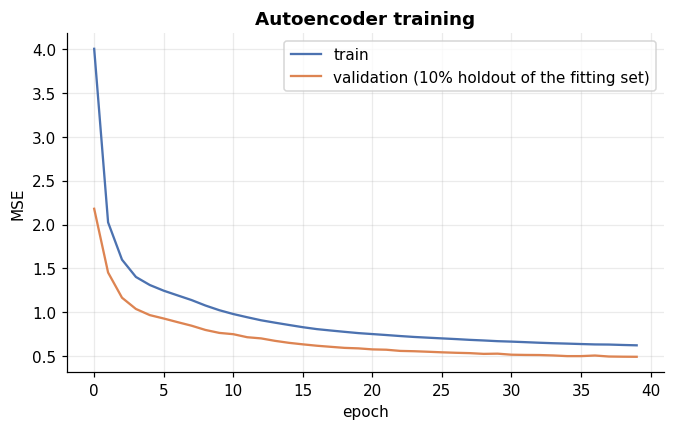

[10:18:05] START  scoring autoencoder
[10:18:06] DONE   scoring autoencoder in 0.7s
[10:18:06] registered 'Autoencoder' | validation PR-AUC = 0.1275 | fit time 68.6s


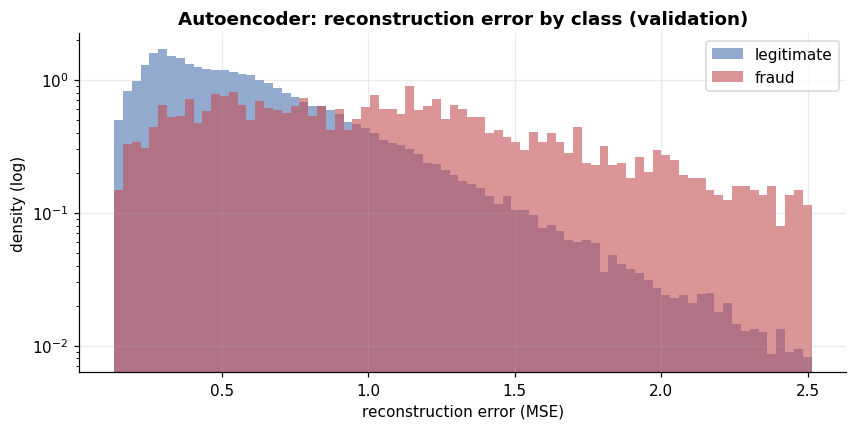

In [28]:
# --- Autoencoder (Keras, with a PCA fallback) -----------------------------------------------------
AE_TRAIN_ON_NORMAL_ONLY = True
AE_BOTTLENECK, AE_EPOCHS, AE_BATCH = 16, 40 if not FAST_MODE else 12, 1024
AE_INFO = {}

def _ae_fit_indices():
    pool = np.where(y_train == 0)[0] if AE_TRAIN_ON_NORMAL_ONLY else np.arange(len(A_train))
    k = min(AUTOENCODER_SAMPLE_SIZE, len(pool))
    return np.random.RandomState(SEED + 3).choice(pool, k, replace=False)

autoencoder, ae_kind, ae_score_fn = None, None, None
if RUN_AUTOENCODER:
    ae_idx = _ae_fit_indices()
    A_ae = A_train[ae_idx]
    print(f"Autoencoder fitting set: {len(A_ae):,} rows x {A_ae.shape[1]} features "
          f"({'non-fraud rows only — semi-supervised' if AE_TRAIN_ON_NORMAL_ONLY else 'all rows — fully unsupervised'})")
    t0 = time.time()
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        tf.random.set_seed(SEED)
        tf.keras.utils.set_random_seed(SEED)
        d = A_ae.shape[1]
        inp = keras.Input(shape=(d,), name="features")
        x = layers.Dense(64, activation="relu")(inp)
        x = layers.Dropout(0.10)(x)
        x = layers.Dense(32, activation="relu")(x)
        z = layers.Dense(AE_BOTTLENECK, activation="relu", name="bottleneck")(x)
        x = layers.Dense(32, activation="relu")(z)
        x = layers.Dropout(0.10)(x)
        x = layers.Dense(64, activation="relu")(x)
        out = layers.Dense(d, activation="linear", name="reconstruction")(x)
        autoencoder = keras.Model(inp, out, name="fraud_autoencoder")
        autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
        autoencoder.summary()
        cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)]
        hist = autoencoder.fit(A_ae, A_ae, epochs=AE_EPOCHS, batch_size=AE_BATCH,
                               validation_split=0.10, shuffle=True, callbacks=cbs, verbose=2)
        ae_kind = "keras"
        AE_INFO = {"epochs_run": len(hist.history["loss"]),
                   "final_train_loss": float(hist.history["loss"][-1]),
                   "best_val_loss": float(min(hist.history["val_loss"]))}

        def ae_score_fn(A, chunk=100_000, per_feature=False):
            errs = []
            for i in range(0, len(A), chunk):
                block = A[i:i + chunk]
                rec = autoencoder.predict(block, batch_size=4096, verbose=0)
                e = (block - rec) ** 2
                errs.append(e if per_feature else e.mean(axis=1))
            return np.concatenate(errs, axis=0)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(hist.history["loss"], label="train")
        ax.plot(hist.history["val_loss"], label="validation (10% holdout of the fitting set)")
        ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("Autoencoder training")
        ax.legend(); savefig(fig, "07_autoencoder_training")

    except Exception as exc:                                   # noqa: BLE001
        print(f"\n[WARN] Keras autoencoder unavailable/failed ({type(exc).__name__}: {str(exc)[:200]})."
              "\n       Substituting a LINEAR autoencoder (PCA reconstruction error). "
              "This is documented in the model comparison table.")
        ae_kind = "pca"
        autoencoder = PCA(n_components=AE_BOTTLENECK, random_state=SEED).fit(A_ae)
        AE_INFO = {"explained_variance": float(autoencoder.explained_variance_ratio_.sum())}

        def ae_score_fn(A, chunk=200_000, per_feature=False):
            errs = []
            for i in range(0, len(A), chunk):
                block = A[i:i + chunk]
                rec = autoencoder.inverse_transform(autoencoder.transform(block))
                e = (block - rec) ** 2
                errs.append(e if per_feature else e.mean(axis=1))
            return np.concatenate(errs, axis=0)

    ae_name = "Autoencoder" if ae_kind == "keras" else "Autoencoder (PCA fallback)"
    with timed("scoring autoencoder"):
        s_val, s_test = ae_score_fn(A_val), ae_score_fn(A_test)
    register_model(ae_name, "unsupervised (semi-supervised fit)" if AE_TRAIN_ON_NORMAL_ONLY else "unsupervised",
                   False,
                   {"kind": ae_kind, "bottleneck": AE_BOTTLENECK, "fit_rows": int(len(ae_idx)),
                    "normal_only": AE_TRAIN_ON_NORMAL_ONLY, **AE_INFO},
                   time.time() - t0, s_val, s_test,
                   notes="reconstruction error; fitted on normal rows only" if AE_TRAIN_ON_NORMAL_ONLY
                         else "reconstruction error; fitted on all training rows")

    fig, ax = plt.subplots(figsize=(9, 4))
    lo, hi = np.percentile(s_val, [0.5, 99.5])
    bins = np.linspace(lo, hi, 80)
    ax.hist(s_val[y_val == 0], bins=bins, alpha=0.6, density=True, label="legitimate", color="#4C72B0")
    ax.hist(s_val[y_val == 1], bins=bins, alpha=0.6, density=True, label="fraud", color="#C44E52")
    ax.set_yscale("log"); ax.set_xlabel("reconstruction error (MSE)"); ax.set_ylabel("density (log)")
    ax.set_title(f"{ae_name}: reconstruction error by class (validation)")
    ax.legend(); savefig(fig, "08_autoencoder_error_distribution")
else:
    ae_name = None
    print("RUN_AUTOENCODER = False -> autoencoder skipped.")

## 12. Supervised Fraud Detection

**What:** a gradient-boosted tree classifier trained on the labels, as the reference point the anomaly
track is measured against.

**Why LightGBM:** it handles `NaN` natively (so the informative missingness survives), consumes
categorical integer codes directly, and trains on 590k × ~200 features in a couple of minutes on a
Colab CPU. If the import fails the notebook falls back to XGBoost and then to scikit-learn's
`HistGradientBoostingClassifier`, recording whichever substitution was made.

**Imbalance handling — and why no SMOTE.** We use `scale_pos_weight` (equivalently, class weighting),
which re-weights the gradient contribution of the minority class without inventing data. SMOTE is
deliberately *not* used here: it interpolates between minority points, which is incoherent for a
matrix that is mostly ordinal category codes, count features and `NaN`-carrying columns — the
synthetic "transactions" it produces are combinations that could not physically occur (a fractional
card ID, a blended device string). It also inflates apparent validation performance while degrading
ranking quality on the genuinely imbalanced test distribution. Weighting achieves the same objective
without fabricating records.

**Early stopping deserves a warning label.** It runs on the validation split against
`average_precision`, and the model params set `metric="average_precision"` so that log-loss is not
tracked at all. This is not a stylistic preference. LightGBM stops when *any* monitored metric stops
improving, and under `scale_pos_weight` the weighted log-loss gets worse from the very first
iteration while PR-AUC is still rising — leaving the default in place trains a **one-tree model** that
still posts a plausible-looking ROC-AUC, which is exactly the kind of silent failure that survives
code review. On this dataset the difference measured ~0.15 versus ~0.60 validation PR-AUC.

The tree budget (`n_estimators=1500`) is a Colab runtime cap rather than a convergence point: PR-AUC
was still improving slowly at that budget, so raising it will improve results at the cost of minutes
per fit.

In [29]:
# --- Supervised model with a documented fallback chain --------------------------------------------
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
SCALE_POS_WEIGHT = neg / max(pos, 1)
print(f"Training rows {len(y_train):,} | positives {pos:,} ({pos / len(y_train):.3%}) "
      f"-> scale_pos_weight = {SCALE_POS_WEIGHT:.1f}")

SUPERVISED_BACKEND = None
try:
    import lightgbm as lgb
    SUPERVISED_BACKEND = "lightgbm"
except Exception:
    try:
        import xgboost as xgb
        SUPERVISED_BACKEND = "xgboost"
        print("[WARN] LightGBM unavailable -> substituting XGBoost (documented in the comparison table).")
    except Exception:
        from sklearn.ensemble import HistGradientBoostingClassifier
        SUPERVISED_BACKEND = "sklearn_hgb"
        print("[WARN] Neither LightGBM nor XGBoost available -> substituting sklearn "
              "HistGradientBoostingClassifier (documented in the comparison table).")
print(f"Supervised backend: {SUPERVISED_BACKEND}")

# metric="average_precision" is load-bearing, not cosmetic. LightGBM otherwise also tracks the
# objective's default binary_logloss, and early stopping halts as soon as ANY monitored metric stops
# improving. Under scale_pos_weight the weighted log-loss degrades from iteration 1 while PR-AUC is
# still climbing -> training stops after a single tree. Monitoring average precision alone (plus
# first_metric_only=True on the callback) is what makes early stopping agree with the project metric.
LGB_BASE = dict(objective="binary", metric="average_precision", n_estimators=1500,
                learning_rate=0.05, num_leaves=64, min_child_samples=100, subsample=0.85,
                subsample_freq=1, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0, max_bin=255,
                scale_pos_weight=SCALE_POS_WEIGHT, random_state=SEED, n_jobs=-1, verbose=-1)

def fit_supervised(params, X_tr, y_tr, X_va, y_va, verbose_eval=200):
    '''Returns (fitted_model, best_iteration, val_probabilities).'''
    if SUPERVISED_BACKEND == "lightgbm":
        model = lgb.LGBMClassifier(**params)
        try:
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
                      categorical_feature=[c for c in CAT_FEATURES if c in X_tr.columns],
                      callbacks=[lgb.early_stopping(100, verbose=False, first_metric_only=True),
                                 lgb.log_evaluation(verbose_eval)])
            best_it = getattr(model, "best_iteration_", None) or params["n_estimators"]
        except TypeError:                      # very old LightGBM without callbacks support
            print("[WARN] This LightGBM build does not support callbacks; training without early stopping.")
            model = lgb.LGBMClassifier(**{**params, "n_estimators": 400})
            model.fit(X_tr, y_tr)
            best_it = 400
    elif SUPERVISED_BACKEND == "xgboost":
        drop = {"num_leaves", "verbose", "subsample_freq", "objective", "max_bin",
                "min_child_samples"}                     # LightGBM-only names
        p = {k: v for k, v in params.items() if k not in drop}
        p["min_child_weight"] = max(1, params.get("min_child_samples", 100) // 10)
        model = xgb.XGBClassifier(**p, max_depth=8, tree_method="hist", eval_metric="aucpr",
                                  early_stopping_rounds=100, enable_categorical=False)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=verbose_eval)
        best_it = getattr(model, "best_iteration", params["n_estimators"])
    else:
        from sklearn.ensemble import HistGradientBoostingClassifier
        model = HistGradientBoostingClassifier(
            max_iter=400, learning_rate=params["learning_rate"], max_leaf_nodes=params["num_leaves"],
            min_samples_leaf=params["min_child_samples"], l2_regularization=params["reg_lambda"],
            early_stopping=True, validation_fraction=0.1, scoring="average_precision",
            random_state=SEED, class_weight={0: 1.0, 1: SCALE_POS_WEIGHT})
        model.fit(X_tr, y_tr)
        best_it = model.n_iter_
    return model, best_it, model.predict_proba(X_va)[:, 1]

t0 = time.time()
with timed("baseline supervised model"):
    sup_model, best_iter, p_val = fit_supervised(LGB_BASE, X_train, y_train, X_val, y_val)
base_ap = average_precision_score(y_val, p_val)
print(f"\nBaseline validation PR-AUC {base_ap:.4f} | ROC-AUC {roc_auc_score(y_val, p_val):.4f} "
      f"| best iteration {best_iter}")
baseline_runtime = time.time() - t0

Training rows 413,378 | positives 14,538 (3.517%) -> scale_pos_weight = 27.4
Supervised backend: lightgbm
[10:18:07] START  baseline supervised model
[200]	valid_0's average_precision: 0.574555
[400]	valid_0's average_precision: 0.61547
[600]	valid_0's average_precision: 0.634444
[800]	valid_0's average_precision: 0.647457
[1000]	valid_0's average_precision: 0.655207
[1200]	valid_0's average_precision: 0.659049
[1400]	valid_0's average_precision: 0.662293
[10:24:37] DONE   baseline supervised model in 390.2s

Baseline validation PR-AUC 0.6642 | ROC-AUC 0.9271 | best iteration 1498


## 18. Hyperparameter Tuning (compact and validation-only)

**What:** a small, fixed, reproducible random search — five configurations drawn once with a seeded
RNG — each trained with early stopping and scored on validation PR-AUC.

**Why so small:** an exhaustive search on this dataset would occupy a Colab session for hours and
almost certainly get the runtime recycled before the notebook finishes. Five well-spread
configurations plus early stopping capture most of the achievable gain; the marginal PR-AUC from a
200-trial Optuna study is small compared with the cost of not finishing.

**The rule that matters:** tuning reads the *validation* split only. The test set is not touched here,
not in threshold selection, and not in model comparison — it is scored exactly once, in Section 14.
Set `RUN_HYPERPARAMETER_TUNING = False` to keep the baseline configuration.

In [30]:
# --- Compact random search -----------------------------------------------------------------------
tuning_results = [{"config": "baseline", **{k: LGB_BASE[k] for k in
                                            ["learning_rate", "num_leaves", "min_child_samples",
                                             "colsample_bytree", "reg_lambda"]},
                   "best_iter": int(best_iter), "val_PR_AUC": base_ap}]
best_model, best_val_ap, best_config = sup_model, base_ap, "baseline"
best_val_proba, tuning_runtime = p_val, 0.0

if RUN_HYPERPARAMETER_TUNING:
    rng = np.random.RandomState(SEED)
    # Learning rates below 0.05 are excluded on purpose: with early stopping now tracking PR-AUC,
    # slower rates keep improving past the tree budget and each fit costs several minutes in Colab.
    SEARCH_SPACE = {"learning_rate": [0.05, 0.08], "num_leaves": [31, 64, 128, 192],
                    "min_child_samples": [30, 100, 200, 400], "colsample_bytree": [0.5, 0.7, 0.9],
                    "subsample": [0.7, 0.85, 1.0], "reg_lambda": [0.5, 1.0, 5.0, 20.0]}
    n_trials = 3 if not FAST_MODE else 2
    trials = [{k: v[rng.randint(len(v))] for k, v in SEARCH_SPACE.items()} for _ in range(n_trials)]
    print(f"Running {n_trials} configurations (seeded, therefore reproducible). "
          f"Roughly {n_trials * baseline_runtime / 60:.1f} min expected.\n")
    t0 = time.time()
    for i, tr in enumerate(trials, 1):
        params = {**LGB_BASE, **tr}
        m, bi, pv = fit_supervised(params, X_train, y_train, X_val, y_val, verbose_eval=0)
        ap = average_precision_score(y_val, pv)
        tuning_results.append({"config": f"trial_{i}", **tr, "best_iter": int(bi), "val_PR_AUC": ap})
        print(f"  trial {i}: PR-AUC {ap:.4f}  {tr}")
        if ap > best_val_ap:
            best_model, best_val_ap, best_config, best_val_proba = m, ap, f"trial_{i}", pv
            best_params_sup = params
    tuning_runtime = time.time() - t0
else:
    print("RUN_HYPERPARAMETER_TUNING = False -> keeping the baseline configuration.")

if best_config == "baseline":
    best_params_sup = LGB_BASE

tuning_df = pd.DataFrame(tuning_results).sort_values("val_PR_AUC", ascending=False)
display(tuning_df.style.format({"val_PR_AUC": "{:.4f}"}).hide(axis="index"))
tuning_df.to_csv(os.path.join(DIRS["reports"], "hyperparameter_search.csv"), index=False)
print(f"\nSelected configuration: {best_config} (validation PR-AUC {best_val_ap:.4f})")

sup_model = best_model
SUP_NAME = {"lightgbm": "LightGBM (supervised)", "xgboost": "XGBoost (supervised)",
            "sklearn_hgb": "HistGradientBoosting (supervised)"}[SUPERVISED_BACKEND]
with timed("scoring the supervised model on validation + test"):
    p_val_sup = sup_model.predict_proba(X_val)[:, 1]
    p_test_sup = sup_model.predict_proba(X_test)[:, 1]     # stored now, inspected only in Section 14
register_model(SUP_NAME, "supervised", True,
               {k: v for k, v in best_params_sup.items() if k not in ("verbose", "n_jobs")},
               baseline_runtime + tuning_runtime, p_val_sup, p_test_sup,
               notes=f"backend={SUPERVISED_BACKEND}, config={best_config}, "
                     f"imbalance handled with scale_pos_weight={SCALE_POS_WEIGHT:.1f}")

Running 3 configurations (seeded, therefore reproducible). Roughly 19.5 min expected.

  trial 1: PR-AUC 0.6809  {'learning_rate': 0.05, 'num_leaves': 192, 'min_child_samples': 30, 'colsample_bytree': 0.9, 'subsample': 1.0, 'reg_lambda': 20.0}
  trial 2: PR-AUC 0.6162  {'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 200, 'colsample_bytree': 0.7, 'subsample': 1.0, 'reg_lambda': 5.0}
  trial 3: PR-AUC 0.6695  {'learning_rate': 0.05, 'num_leaves': 128, 'min_child_samples': 400, 'colsample_bytree': 0.5, 'subsample': 1.0, 'reg_lambda': 1.0}


config,learning_rate,num_leaves,min_child_samples,colsample_bytree,reg_lambda,best_iter,val_PR_AUC,subsample
trial_1,0.050000,192,30,0.900000,20.000000,1499,0.6809,1.000000
trial_3,0.050000,128,400,0.500000,1.000000,1493,0.6695,1.000000
baseline,0.050000,64,100,0.700000,1.000000,1498,0.6642,nan
trial_2,0.050000,31,200,0.700000,5.000000,1498,0.6162,1.000000



Selected configuration: trial_1 (validation PR-AUC 0.6809)
[10:53:27] START  scoring the supervised model on validation + test
[10:54:48] DONE   scoring the supervised model on validation + test in 81.6s
[10:54:48] registered 'LightGBM (supervised)' | validation PR-AUC = 0.6809 | fit time 2119.1s


## 13. Threshold Optimization / Anomaly-Score Calibration

**What:** anomaly detectors and classifiers both emit *scores*, not decisions. This section converts
each model's score into an operating point using the **validation set only**.

**Why three modes rather than one "optimal" threshold.** There is no threshold that is best in the
abstract — it depends entirely on what the team using the model is trying to do:

| Mode | Rule | Who wants it |
|---|---|---|
| **High recall** | lowest threshold that reaches `RECALL_TARGET` (default 80%) on validation | Teams that must not miss fraud and can absorb false positives (e.g. auto-hold + manual release) |
| **Balanced** | maximises F1 on validation | A general-purpose default |
| **Investigation capacity** | flag exactly the top `CAPACITY_RATE` (default 1%) of transactions | The realistic constraint: an analyst team can review N cases a day, no matter what the score distribution looks like |

The capacity mode is the one that most resembles how fraud operations actually run, which is why
Precision@K is treated as a headline metric alongside PR-AUC.

**Note on anomaly-score scales:** Isolation Forest path lengths, LOF density ratios and autoencoder
MSE live on completely different numeric scales. Thresholds are therefore stored per model, and the
comparison in Section 15 uses scale-free metrics (PR-AUC, Precision@K) so the models remain comparable.

In [31]:
# --- Metric helpers ------------------------------------------------------------------------------
def topk_metrics(y_true, scores, ks):
    '''Precision@K / Recall@K: how good is the top of the ranked list — the analyst's actual queue.'''
    order = np.argsort(-scores, kind="stable")
    y_sorted = np.asarray(y_true)[order]
    total_pos = max(int(y_sorted.sum()), 1)
    out = {}
    for k in ks:
        k_eff = min(k, len(y_sorted))
        hits = int(y_sorted[:k_eff].sum())
        out[f"Precision@{k}"] = hits / k_eff
        out[f"Recall@{k}"] = hits / total_pos
    return out

def metrics_at_threshold(y_true, scores, thr, amounts=None):
    pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    res = {"threshold": float(thr), "precision": prec, "recall": rec, "f1": f1,
           "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
           "alerts": int(tp + fp), "alert_rate": (tp + fp) / len(y_true),
           "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
           "fraud_capture_rate": rec}
    if amounts is not None:
        amounts = np.asarray(amounts)
        fraud_amt = amounts[(np.asarray(y_true) == 1)].sum()
        caught = amounts[(np.asarray(y_true) == 1) & (pred == 1)].sum()
        res["fraud_amount_total"] = float(fraud_amt)
        res["fraud_amount_captured"] = float(caught)
        res["fraud_amount_capture_rate"] = float(caught / fraud_amt) if fraud_amt else 0.0
    return res

def optimize_thresholds(y_true, scores, amounts=None):
    '''All three operating modes, computed on the VALIDATION split.'''
    prec, rec, thr = precision_recall_curve(y_true, scores)
    prec, rec = prec[:-1], rec[:-1]                       # align with thr
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-12), 0.0)
    modes = {}

    modes["balanced"] = metrics_at_threshold(y_true, scores, thr[int(np.argmax(f1))], amounts)
    modes["balanced"]["rule"] = "maximises F1 on validation"

    ok = np.where(rec >= RECALL_TARGET)[0]
    thr_hr = thr[ok[-1]] if len(ok) else thr[0]           # highest threshold still meeting the target
    modes["high_recall"] = metrics_at_threshold(y_true, scores, thr_hr, amounts)
    modes["high_recall"]["rule"] = f"highest threshold with recall >= {RECALL_TARGET:.0%}"

    k_cap = max(1, int(round(CAPACITY_RATE * len(scores))))
    thr_cap = np.sort(scores)[::-1][k_cap - 1]
    modes["capacity"] = metrics_at_threshold(y_true, scores, thr_cap, amounts)
    modes["capacity"]["rule"] = f"top {CAPACITY_RATE:.1%} of transactions ({k_cap:,} alerts)"
    return modes

THRESHOLDS = {name: optimize_thresholds(y_val, s, amt_val) for name, s in VAL_SCORES.items()}

rows = []
for name, modes in THRESHOLDS.items():
    for mode, m in modes.items():
        rows.append({"model": name, "mode": mode, "threshold": m["threshold"],
                     "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
                     "alerts": m["alerts"], "alert_rate": m["alert_rate"],
                     "FPR": m["false_positive_rate"],
                     "fraud_$_captured": m.get("fraud_amount_capture_rate", np.nan)})
threshold_table = pd.DataFrame(rows)
display(threshold_table.style.format({"threshold": "{:.5f}", "precision": "{:.3f}", "recall": "{:.3f}",
                                      "f1": "{:.3f}", "alerts": "{:,}", "alert_rate": "{:.2%}",
                                      "FPR": "{:.3%}", "fraud_$_captured": "{:.1%}"})
        .hide(axis="index"))
threshold_table.to_csv(os.path.join(DIRS["reports"], "threshold_selection.csv"), index=False)
save_json(THRESHOLDS, "thresholds.json")
print("\nThresholds fixed on validation. They are NOT re-optimised on test.")

model,mode,threshold,precision,recall,f1,alerts,alert_rate,FPR,fraud_$_captured
Isolation Forest,balanced,0.53498,0.236,0.302,0.265,"3,901",4.40%,3.486%,16.3%
Isolation Forest,high_recall,0.43487,0.058,0.800,0.108,"42,222",47.66%,46.514%,83.1%
Isolation Forest,capacity,0.57368,0.375,0.109,0.169,886,1.00%,0.648%,5.8%
Local Outlier Factor,balanced,1.05950,0.040,0.637,0.076,"48,059",54.25%,53.919%,78.0%
Local Outlier Factor,high_recall,1.02058,0.039,0.800,0.075,"61,699",69.65%,69.284%,89.2%
Local Outlier Factor,capacity,1.92259,0.036,0.011,0.016,886,1.00%,0.998%,1.6%
Autoencoder,balanced,1.54276,0.188,0.245,0.213,"3,960",4.47%,3.757%,16.9%
Autoencoder,high_recall,0.53480,0.053,0.800,0.100,"45,741",51.64%,50.628%,77.3%
Autoencoder,capacity,2.20505,0.262,0.076,0.118,886,1.00%,0.765%,4.7%
LightGBM (supervised),balanced,0.27837,0.744,0.585,0.655,"2,394",2.70%,0.718%,55.2%



Thresholds fixed on validation. They are NOT re-optimised on test.


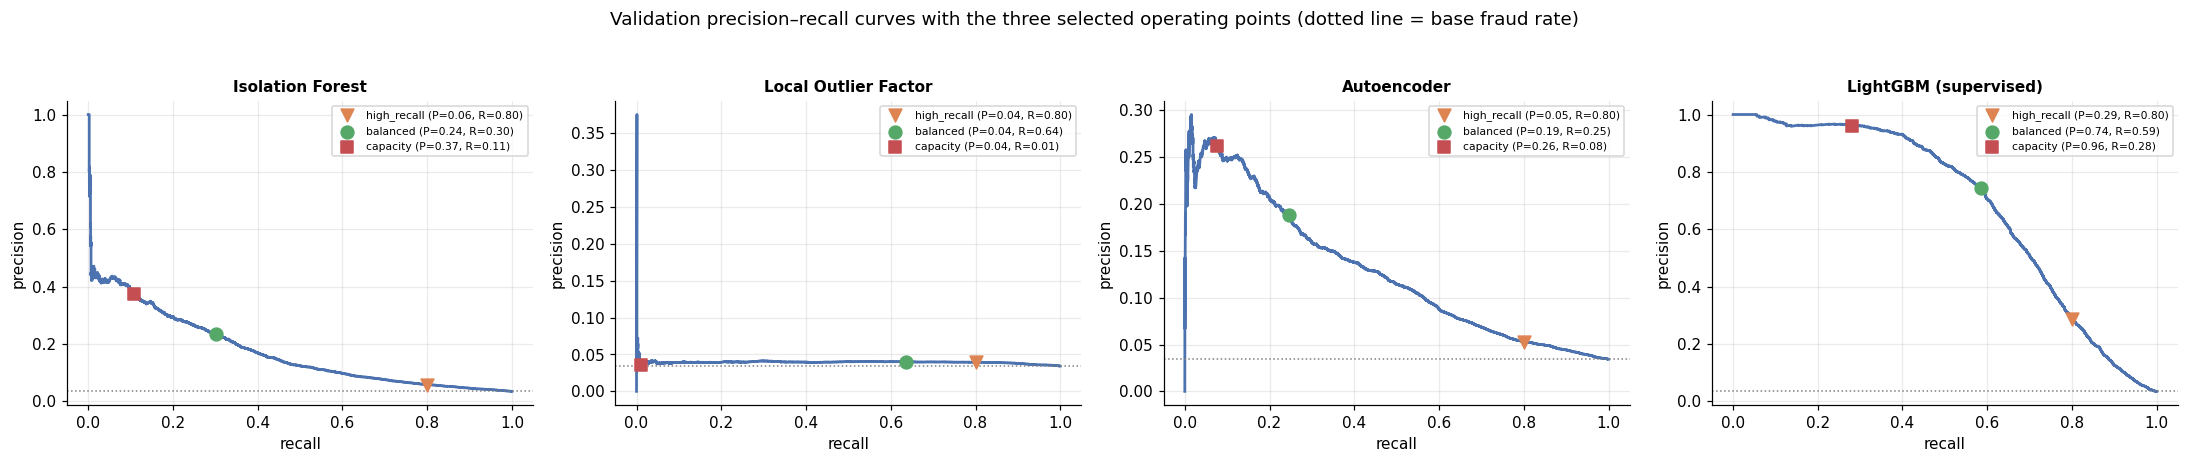

In [32]:
# --- Precision/recall trade-off curves (validation) ----------------------------------------------
n_models = len(VAL_SCORES)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)
for ax, (name, s) in zip(axes[0], VAL_SCORES.items()):
    prec, rec, thr = precision_recall_curve(y_val, s)
    ax.plot(rec[:-1], prec[:-1], lw=1.8, color="#4C72B0")
    for mode, color, marker in [("high_recall", "#DD8452", "v"), ("balanced", "#55A868", "o"),
                                ("capacity", "#C44E52", "s")]:
        m = THRESHOLDS[name][mode]
        ax.scatter(m["recall"], m["precision"], color=color, marker=marker, s=70, zorder=5,
                   label=f"{mode} (P={m['precision']:.2f}, R={m['recall']:.2f})")
    ax.axhline(y_val.mean(), ls=":", c="grey", lw=1)
    ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Validation precision–recall curves with the three selected operating points "
             "(dotted line = base fraud rate)", y=1.04)
fig.tight_layout(); savefig(fig, "09_threshold_selection")

## 14. Model Evaluation — the single pass over the test set

**What:** every model, already frozen (fitted parameters, selected hyperparameters, selected
thresholds), is now scored on the held-out final period exactly once.

**Why the metrics are what they are:**

* **PR-AUC (average precision)** — the headline. With 3.5% positives, ROC-AUC looks flattering because
  the huge negative class makes the false-positive rate move slowly; PR-AUC does not have that
  cushion.
* **Precision@K / Recall@K** — the operational reading: "if analysts work the top 500 alerts, what
  fraction are real, and what share of all fraud does that catch?"
* **Fraud amount captured** — value-weighted recall. Catching many small frauds is not the same
  achievement as catching the expensive ones.
* **Accuracy** — reported once, in a single line, purely to demonstrate why it is useless here.

In [33]:
# --- Final test evaluation (one pass) ------------------------------------------------------------
KS = [k for k in TOPK_LIST if k <= len(y_test)]
K_CAP = max(1, int(round(CAPACITY_RATE * len(y_test))))
if K_CAP not in KS:
    KS = sorted(KS + [K_CAP])
print(f"Test set: {len(y_test):,} transactions | {int(y_test.sum()):,} frauds "
      f"({y_test.mean():.3%}) | K values: {KS} (K={K_CAP:,} = the {CAPACITY_RATE:.1%} capacity point)")

HEADLINE_MODE = "capacity"     # the operating point used for the point-metric columns
results = {}
for name, s_test in TEST_SCORES.items():
    thr = THRESHOLDS[name][HEADLINE_MODE]["threshold"]
    row = {"model": name,
           "training_type": MODEL_META[name]["training_type"],
           "uses_fraud_labels": "yes" if MODEL_META[name]["uses_fraud_labels"] else "no",
           "PR_AUC": average_precision_score(y_test, s_test),
           "ROC_AUC": roc_auc_score(y_test, s_test)}
    row.update({k: v for k, v in metrics_at_threshold(y_test, s_test, thr, amt_test).items()
                if k in ("precision", "recall", "f1", "alerts", "false_positive_rate",
                         "fraud_amount_capture_rate", "tp", "fp", "fn", "threshold")})
    row.update(topk_metrics(y_test, s_test, KS))
    row["runtime_s"] = MODEL_META[name]["runtime_seconds"]
    results[name] = row

results_df = (pd.DataFrame(results).T.reset_index(drop=True)
              .sort_values("PR_AUC", ascending=False).reset_index(drop=True))
num_cols = [c for c in results_df.columns if c not in
            ("model", "training_type", "uses_fraud_labels")]
results_df[num_cols] = results_df[num_cols].astype(float)

print(f"\nAll point metrics below use each model's '{HEADLINE_MODE}' threshold, "
      "chosen on validation before the test set was touched.\n")
display(results_df[["model", "training_type", "uses_fraud_labels", "PR_AUC", "ROC_AUC",
                    "precision", "recall", "f1"]]
        .style.format({c: "{:.4f}" for c in ["PR_AUC", "ROC_AUC", "precision", "recall", "f1"]})
        .background_gradient(subset=["PR_AUC"], cmap="Greens").hide(axis="index"))

best_name = results_df.iloc[0]["model"]
naive_acc = 1 - y_test.mean()
print(f"\nFor contrast: a model that predicts 'legitimate' for every transaction scores "
      f"{naive_acc:.2%} ACCURACY on this test set, with PR-AUC = {y_test.mean():.4f} "
      "(the base rate) and zero fraud caught. That is why accuracy appears nowhere else.")
results_df.to_csv(os.path.join(DIRS["reports"], "model_comparison.csv"), index=False)
save_json(results, "evaluation_results.json")

Test set: 88,581 transactions | 3,083 frauds (3.480%) | K values: [100, 500, 886, 1000] (K=886 = the 1.0% capacity point)

All point metrics below use each model's 'capacity' threshold, chosen on validation before the test set was touched.



model,training_type,uses_fraud_labels,PR_AUC,ROC_AUC,precision,recall,f1
LightGBM (supervised),supervised,yes,0.5736,0.9044,0.9171,0.2225,0.3581
Isolation Forest,unsupervised,no,0.1550,0.7687,0.3224,0.1177,0.1725
Autoencoder,unsupervised (semi-supervised fit),no,0.1275,0.7477,0.2142,0.0814,0.1180
Local Outlier Factor,unsupervised,no,0.0363,0.5232,0.0342,0.0110,0.0167



For contrast: a model that predicts 'legitimate' for every transaction scores 96.52% ACCURACY on this test set, with PR-AUC = 0.0348 (the base rate) and zero fraud caught. That is why accuracy appears nowhere else.


## 15. Model Comparison

The full table — ranking metrics, operating-point metrics and the label-usage column that keeps the
comparison honest. An unsupervised detector and a supervised classifier are *not* competing on equal
terms, and the table says so explicitly rather than presenting a single leaderboard.

In [34]:
# --- Full comparison table -----------------------------------------------------------------------
show_cols = (["model", "training_type", "uses_fraud_labels", "PR_AUC", "ROC_AUC",
              "precision", "recall", "f1"] +
             [f"Precision@{k}" for k in KS] + [f"Recall@{k}" for k in KS] +
             ["alerts", "fraud_amount_capture_rate", "runtime_s"])
show_cols = [c for c in show_cols if c in results_df.columns]
fmt = {c: "{:.4f}" for c in show_cols if c not in
       ("model", "training_type", "uses_fraud_labels", "alerts", "runtime_s")}
fmt.update({"alerts": "{:,.0f}", "runtime_s": "{:.0f}"})
display(results_df[show_cols].style.format(fmt)
        .background_gradient(subset=["PR_AUC", f"Precision@{KS[0]}"], cmap="Greens")
        .hide(axis="index"))

sup_row = results_df[results_df.model == SUP_NAME].iloc[0]
anom_rows = results_df[results_df.model != SUP_NAME]
best_anom = anom_rows.sort_values("PR_AUC", ascending=False).iloc[0]
lift_vs_random = best_anom["PR_AUC"] / y_test.mean()
print(f"\nBest unsupervised detector : {best_anom['model']} — PR-AUC {best_anom['PR_AUC']:.4f} "
      f"({lift_vs_random:.1f}x the base rate of {y_test.mean():.4f})")
print(f"Supervised classifier      : {SUP_NAME} — PR-AUC {sup_row['PR_AUC']:.4f} "
      f"({sup_row['PR_AUC'] / max(best_anom['PR_AUC'], 1e-9):.1f}x the best unsupervised model)")
print(f"Precision@{KS[0]}            : {best_anom['model']} {best_anom[f'Precision@{KS[0]}']:.3f} "
      f"vs supervised {sup_row[f'Precision@{KS[0]}']:.3f}")
print("\nReading: the anomaly detectors do beat random ranking by a wide margin — deviation from "
      "normal behaviour genuinely carries fraud signal. They do not come close to a model that has "
      "seen labels, which is the expected and honest result.")

model,training_type,uses_fraud_labels,PR_AUC,ROC_AUC,precision,recall,f1,Precision@100,Precision@500,Precision@886,Precision@1000,Recall@100,Recall@500,Recall@886,Recall@1000,alerts,fraud_amount_capture_rate,runtime_s
LightGBM (supervised),supervised,yes,0.5736,0.9044,0.9171,0.2225,0.3581,1.0000,0.9380,0.8950,0.8770,0.0324,0.1521,0.2572,0.2845,748,0.1411,2119
Isolation Forest,unsupervised,no,0.1550,0.7687,0.3224,0.1177,0.1725,0.1900,0.2600,0.3070,0.3190,0.0062,0.0422,0.0882,0.1035,"1,126",0.0529,46
Autoencoder,unsupervised (semi-supervised fit),no,0.1275,0.7477,0.2142,0.0814,0.1180,0.1600,0.1980,0.2190,0.2210,0.0052,0.0321,0.0629,0.0717,"1,172",0.0339,69
Local Outlier Factor,unsupervised,no,0.0363,0.5232,0.0342,0.0110,0.0167,0.0200,0.0360,0.0361,0.0340,0.0006,0.0058,0.0104,0.0110,993,0.0105,32



Best unsupervised detector : Isolation Forest — PR-AUC 0.1550 (4.5x the base rate of 0.0348)
Supervised classifier      : LightGBM (supervised) — PR-AUC 0.5736 (3.7x the best unsupervised model)
Precision@100            : Isolation Forest 0.190 vs supervised 1.000

Reading: the anomaly detectors do beat random ranking by a wide margin — deviation from normal behaviour genuinely carries fraud signal. They do not come close to a model that has seen labels, which is the expected and honest result.


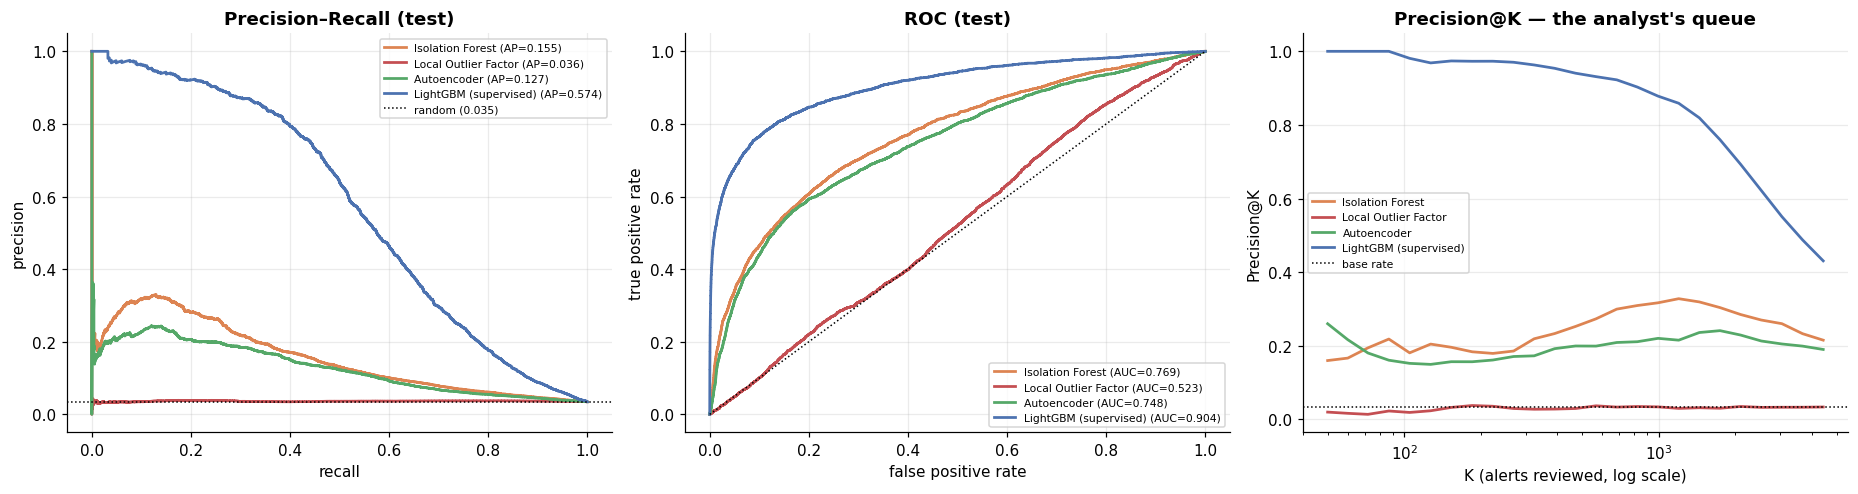

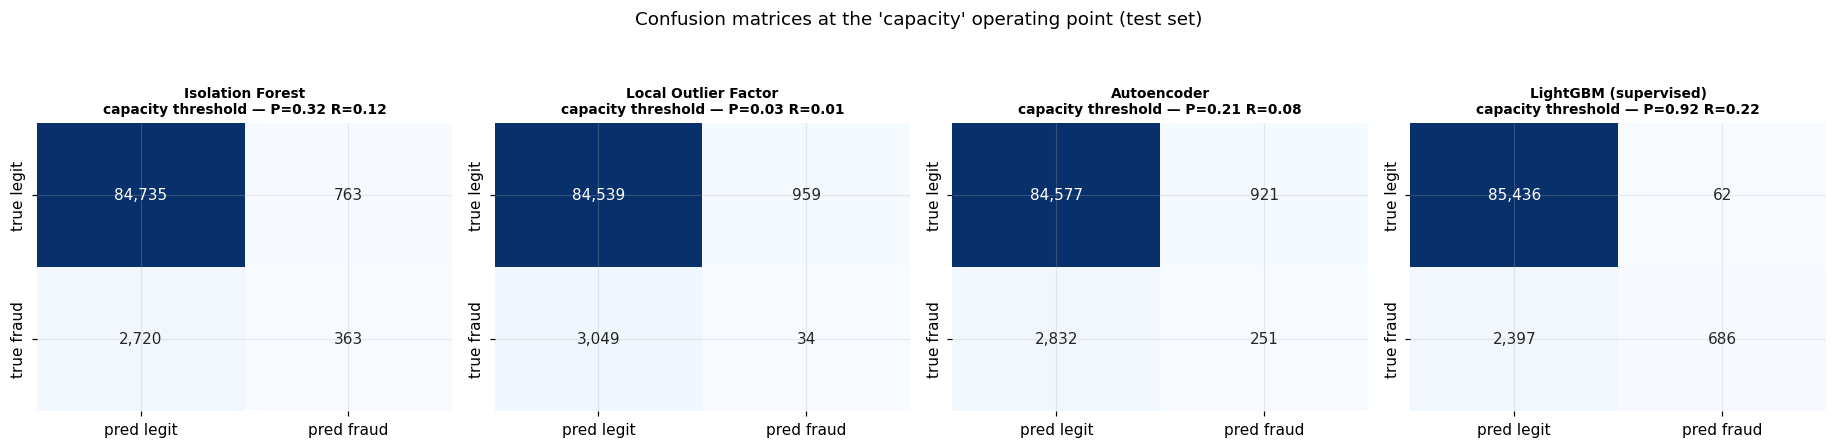

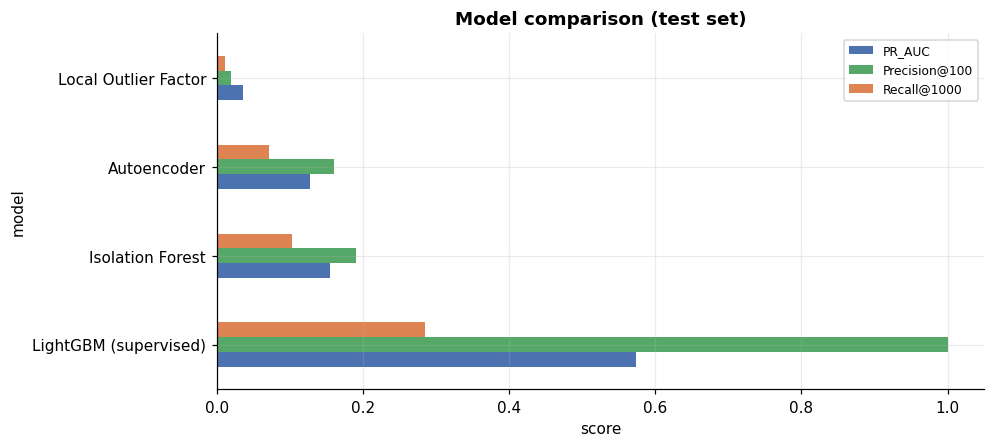

In [35]:
# --- Evaluation figures: PR, ROC, Precision@K, confusion matrices --------------------------------
palette = dict(zip(results_df["model"], sns.color_palette("deep", len(results_df))))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
for name, s in TEST_SCORES.items():
    prec, rec, _ = precision_recall_curve(y_test, s)
    ax.plot(rec, prec, lw=1.8, color=palette[name],
            label=f"{name} (AP={average_precision_score(y_test, s):.3f})")
ax.axhline(y_test.mean(), ls=":", c="k", lw=1, label=f"random ({y_test.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_title("Precision–Recall (test)")
ax.legend(fontsize=7)

ax = axes[1]
for name, s in TEST_SCORES.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, lw=1.8, color=palette[name],
            label=f"{name} (AUC={roc_auc_score(y_test, s):.3f})")
ax.plot([0, 1], [0, 1], ls=":", c="k", lw=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("ROC (test)")
ax.legend(fontsize=7)

ax = axes[2]
k_grid = np.unique(np.clip(np.logspace(1.7, np.log10(len(y_test) * 0.05), 25).astype(int),
                           10, len(y_test)))
for name, s in TEST_SCORES.items():
    order = np.argsort(-s, kind="stable")
    ys = y_test[order]
    ax.plot(k_grid, [ys[:k].sum() / k for k in k_grid], lw=1.8, color=palette[name], label=name)
ax.axhline(y_test.mean(), ls=":", c="k", lw=1, label="base rate")
ax.set_xscale("log"); ax.set_xlabel("K (alerts reviewed, log scale)"); ax.set_ylabel("Precision@K")
ax.set_title("Precision@K — the analyst's queue"); ax.legend(fontsize=7)
fig.tight_layout(); savefig(fig, "10_pr_roc_precisionatk")

fig, axes = plt.subplots(1, len(TEST_SCORES), figsize=(4.2 * len(TEST_SCORES), 3.8), squeeze=False)
for ax, (name, s) in zip(axes[0], TEST_SCORES.items()):
    thr = THRESHOLDS[name][HEADLINE_MODE]["threshold"]
    cm = confusion_matrix(y_test, (s >= thr).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred legit", "pred fraud"], yticklabels=["true legit", "true fraud"])
    r = cm[1, 1] / max(cm[1].sum(), 1)
    p = cm[1, 1] / max(cm[:, 1].sum(), 1)
    ax.set_title(f"{name}\n{HEADLINE_MODE} threshold — P={p:.2f} R={r:.2f}", fontsize=9)
fig.suptitle(f"Confusion matrices at the '{HEADLINE_MODE}' operating point (test set)", y=1.06)
fig.tight_layout(); savefig(fig, "11_confusion_matrices")

fig, ax = plt.subplots(figsize=(9, 4.2))
plot_df = results_df.set_index("model")[["PR_AUC", f"Precision@{KS[0]}", f"Recall@{KS[-1]}"]]
plot_df.plot(kind="barh", ax=ax, color=["#4C72B0", "#55A868", "#DD8452"])
ax.set_title("Model comparison (test set)"); ax.set_xlabel("score")
ax.legend(fontsize=8); savefig(fig, "12_model_comparison")

## 16. SHAP Explainability (supervised model)

**What:** Shapley values for the gradient-boosted model — a global importance ranking, a summary plot
showing *direction* of effect, and a worked single-transaction explanation of the kind an investigator
would actually receive with an alert.

**Why SHAP rather than the model's built-in importances:** split-count importance tells you which
features the model *used*, not which pushed a specific prediction up or down. For a fraud alert the
useful statement is "this transaction's risk is elevated **because** the card is new and the amount is
far above this card's usual", which requires per-prediction attributions.

**Cost control:** exact TreeSHAP on 88k test rows × ~200 features is expensive, so a random sample of
`SHAP_SAMPLE_SIZE` rows (default 3,000) is explained. Sampling affects only the precision of the global
ranking, not the individual explanations. Set `RUN_SHAP = False` to skip.

Explaining 3,000 test rows x 264 features with TreeSHAP ...
[10:54:58] START  SHAP values
[11:13:41] DONE   SHAP values in 1123.1s

Top 15 features by mean |SHAP value|:
C13                         0.450718
V70                         0.262785
nuniq_card1__device_name    0.260907
D1n                         0.258727
C14                         0.222598
P_email_bin                 0.213055
C1                          0.207254
amt_ratio_addr1             0.188853
C5                          0.178851
D15n                        0.157915
C2                          0.141005
P_emaildomain               0.136924
card6                       0.135211
TransactionAmt              0.129907
card1_freq                  0.129488


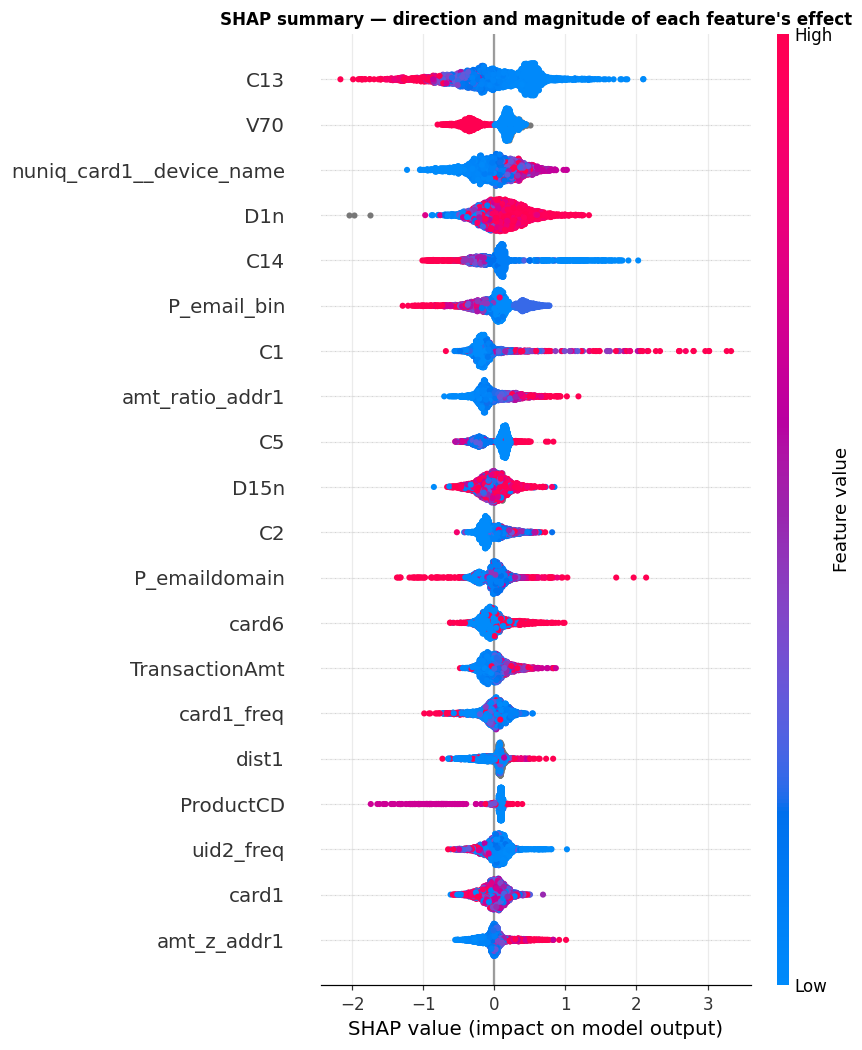

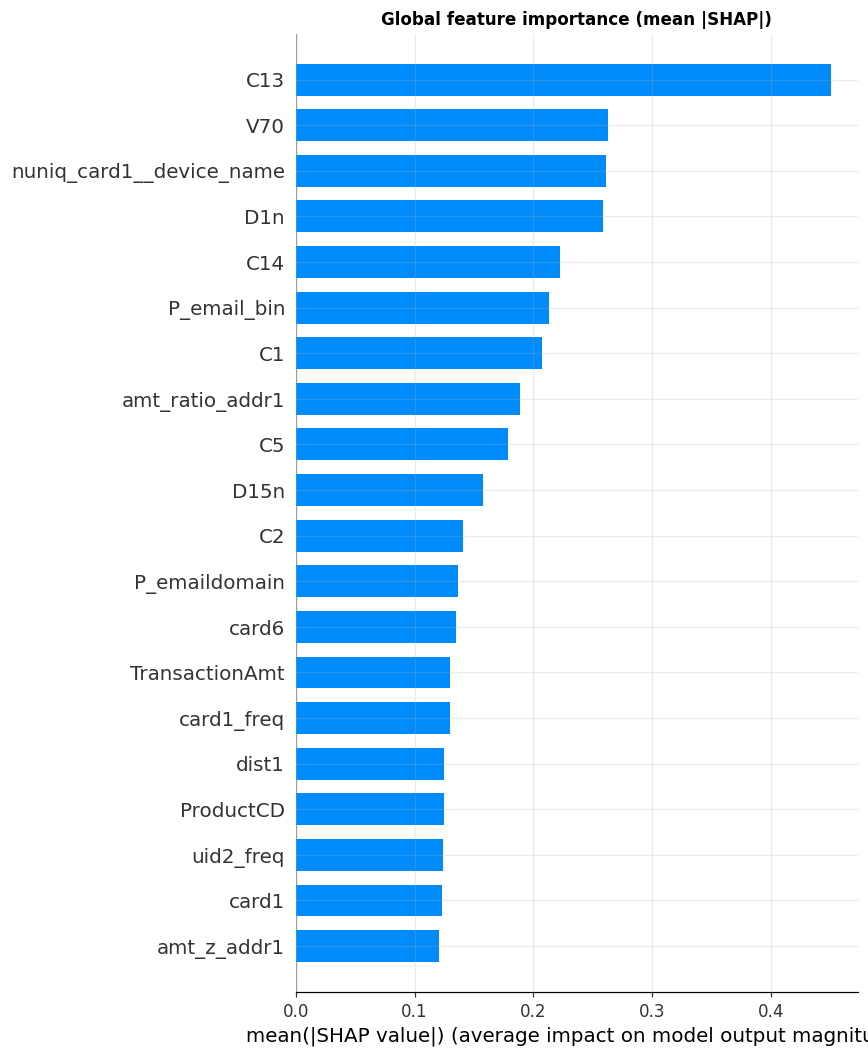

In [36]:
# --- SHAP --------------------------------------------------------------------------------------
SHAP_READY, shap_values, X_shap = False, None, None
if RUN_SHAP:
    try:
        import shap
        n_shap = min(SHAP_SAMPLE_SIZE, len(X_test))
        shap_idx = subsample_idx(len(X_test), n_shap, seed=SEED + 7)
        X_shap = X_test.iloc[shap_idx]
        print(f"Explaining {n_shap:,} test rows x {X_shap.shape[1]} features with TreeSHAP ...")
        with timed("SHAP values"):
            explainer = shap.TreeExplainer(sup_model)
            raw = explainer.shap_values(X_shap)
        if isinstance(raw, list):                      # older API: one array per class
            shap_values = raw[1]
        elif raw.ndim == 3:                            # newer API: (rows, features, classes)
            shap_values = raw[:, :, 1]
        else:
            shap_values = raw
        SHAP_READY = True

        mean_abs = pd.Series(np.abs(shap_values).mean(axis=0),
                             index=X_shap.columns).sort_values(ascending=False)
        print("\nTop 15 features by mean |SHAP value|:")
        print(mean_abs.head(15).to_string())

        fig = plt.figure(figsize=(8, 6))
        shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
        plt.title("SHAP summary — direction and magnitude of each feature's effect", fontsize=11)
        savefig(plt.gcf(), "13_shap_summary")

        fig = plt.figure(figsize=(8, 6))
        shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
        plt.title("Global feature importance (mean |SHAP|)", fontsize=11)
        savefig(plt.gcf(), "14_shap_bar")

        mean_abs.head(40).to_frame("mean_abs_shap").to_csv(
            os.path.join(DIRS["reports"], "shap_feature_importance.csv"))
    except Exception as exc:                           # noqa: BLE001
        print(f"[WARN] SHAP failed ({type(exc).__name__}: {str(exc)[:200]}).\n"
              "       Falling back to the model's native feature importances.")
        try:
            imp = pd.Series(sup_model.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)
            fig, ax = plt.subplots(figsize=(8, 6))
            imp.head(20)[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
            ax.set_title("Native feature importance (SHAP unavailable)")
            savefig(fig, "13_feature_importance_fallback")
        except Exception as exc2:
            print(f"[WARN] Native importances unavailable too: {exc2}")
else:
    print("RUN_SHAP = False -> SHAP skipped.")

EXAMPLE: highest-risk transaction in the SHAP sample
Transaction 3528996 | 2018-05-15 13:52:47 | $54.22
Predicted fraud probability: 1.000 | actual label: 1

  Top factors INCREASING risk:
    DeviceInfo                   value=     178.000   SHAP +2.9598
    C1                           value=      83.000   SHAP +2.6087
    C12                          value=      52.000   SHAP +1.6835
    device_name                  value=     137.000   SHAP +1.5290
    C13                          value=       5.000   SHAP +1.1404
    V187                         value=       4.000   SHAP +1.0405
  Top factors DECREASING risk:
    id_13                        value=      64.000   SHAP -0.1981
    device_name_freq             value=       0.000   SHAP -0.1928
    nuniq_device_name__card1     value=      20.000   SHAP -0.1370
    TransactionAmt               value=      54.225   SHAP -0.1258
    D6                           value=      47.000   SHAP -0.1174
    id_31                        value=    

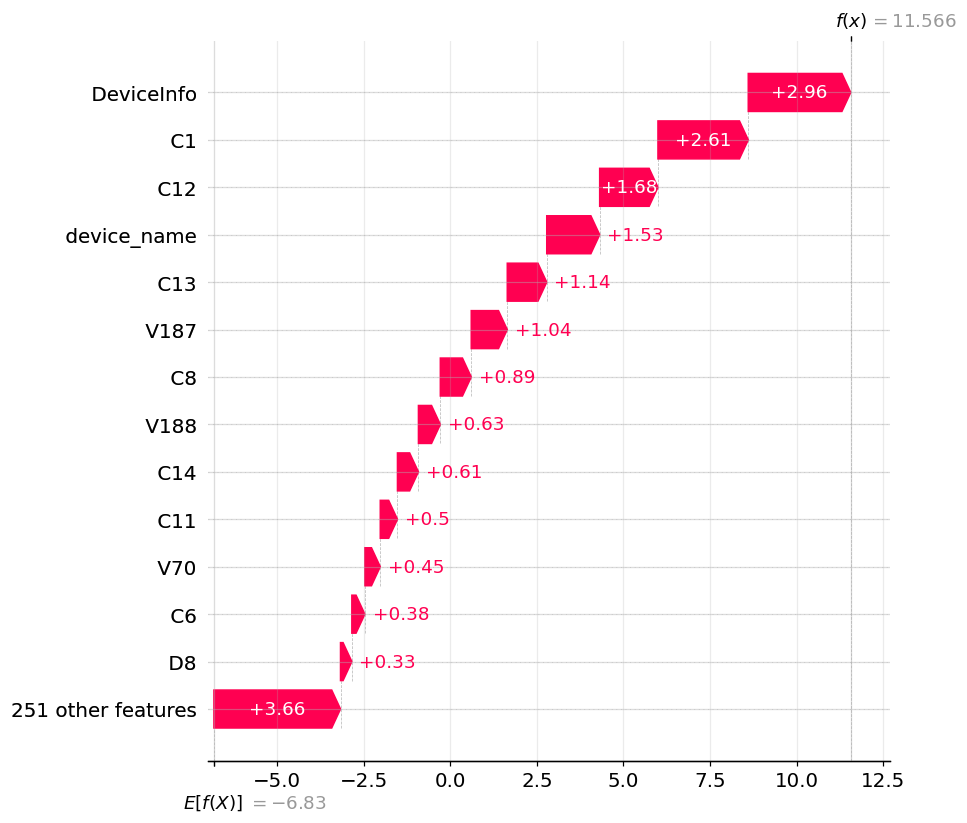

In [37]:
# --- Single-transaction explanation --------------------------------------------------------------
def explain_transaction_supervised(local_pos, top_n=6, verbose=True):
    '''Explain one row of X_shap using its SHAP attributions (positive = pushes risk up).'''
    if not SHAP_READY:
        return None
    row_shap = pd.Series(shap_values[local_pos], index=X_shap.columns)
    row_vals = X_shap.iloc[local_pos]
    global_pos = X_shap.index[local_pos]
    prob = float(sup_model.predict_proba(X_shap.iloc[[local_pos]])[:, 1][0])
    up = row_shap.sort_values(ascending=False).head(top_n)
    down = row_shap.sort_values().head(top_n)
    info = {
        "TransactionID": int(test_df.loc[global_pos, ID_COL]),
        "timestamp": str(as_datetime(test_df.loc[global_pos, TIME_COL])),
        "amount": float(test_df.loc[global_pos, "TransactionAmt"]),
        "predicted_fraud_probability": prob,
        "actual_label": int(y_test[global_pos]),
        "increases_risk": [(f, float(row_shap[f]), float(row_vals[f])) for f in up.index],
        "decreases_risk": [(f, float(row_shap[f]), float(row_vals[f])) for f in down.index],
    }
    if verbose:
        print(f"Transaction {info['TransactionID']} | {info['timestamp']} | "
              f"${info['amount']:.2f}")
        print(f"Predicted fraud probability: {prob:.3f} | actual label: {info['actual_label']}")
        print("\n  Top factors INCREASING risk:")
        for f, sv, val in info["increases_risk"]:
            print(f"    {f:<28} value={val:>12.3f}   SHAP +{sv:.4f}")
        print("  Top factors DECREASING risk:")
        for f, sv, val in info["decreases_risk"]:
            print(f"    {f:<28} value={val:>12.3f}   SHAP {sv:.4f}")
    return info

if SHAP_READY:
    local_probs = sup_model.predict_proba(X_shap)[:, 1]
    example_pos = int(np.argmax(local_probs))
    print("=" * 78)
    print("EXAMPLE: highest-risk transaction in the SHAP sample")
    print("=" * 78)
    example_explanation = explain_transaction_supervised(example_pos)
    try:
        import shap
        fig = plt.figure()
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value if np.ndim(explainer.expected_value) == 0
            else np.ravel(explainer.expected_value)[-1],
            shap_values[example_pos], X_shap.iloc[example_pos], max_display=14, show=False)
        savefig(plt.gcf(), "15_shap_waterfall_example")
    except Exception as exc:
        print(f"[note] waterfall plot unavailable ({type(exc).__name__}); the text explanation above "
              "carries the same information.")

## 17. Anomaly Explainability

**What:** for any flagged transaction, the fields that made it look unusual.

**How it works.** The anomaly matrix is rank-Gauss transformed, so each scaled value is effectively
"how many standard deviations from the training median is this transaction on this feature". Ranking
those absolute deviations gives an immediately readable list. For the autoencoder we can do better and
decompose the reconstruction error *per feature* — the fields the model could not reproduce are
literally the reason the score is high.

**Language matters here.** These are **anomaly indicators / contributing features**, not causes. The
statement is "this transaction sits far from normal on these dimensions", never "these features caused
the fraud". A rare device is a reason to look, not evidence of guilt — and treating it as evidence is
how fraud systems end up discriminating against people with unusual but perfectly legitimate habits.

In [38]:
# --- Deviation-based anomaly explanation ---------------------------------------------------------
ANOM_MODELS = [n for n in TEST_SCORES if n != SUP_NAME]
PRIMARY_ANOM = (results_df[results_df.model.isin(ANOM_MODELS)]
                .sort_values("PR_AUC", ascending=False).iloc[0]["model"]) if ANOM_MODELS else None
print(f"Primary anomaly detector for the explanation sections: {PRIMARY_ANOM}")

train_feature_median = X_train[ANOM_FEATURES].median()

def describe_deviation(z):
    if z >= 3:   return "extremely high"
    if z >= 2:   return "unusually high"
    if z >= 1:   return "somewhat high"
    if z <= -3:  return "extremely low / rare"
    if z <= -2:  return "unusually low / rare"
    if z <= -1:  return "somewhat low"
    return "typical"

def explain_anomaly(row_pos, scaled_matrix=None, raw_frame=None, top_n=6, use_ae=True, verbose=True):
    '''Explain why row `row_pos` of the TEST split looks anomalous.'''
    scaled_matrix = A_test if scaled_matrix is None else scaled_matrix
    raw_frame = X_test if raw_frame is None else raw_frame
    z = scaled_matrix[row_pos]
    order = np.argsort(-np.abs(z))[:top_n]
    items = []
    for j in order:
        feat = ANOM_FEATURES[j]
        items.append({"feature": feat, "value": float(raw_frame.iloc[row_pos][feat]),
                      "train_median": float(train_feature_median[feat]),
                      "deviation_sigma": float(z[j]), "reading": describe_deviation(z[j])})
    ae_items = []
    if use_ae and RUN_AUTOENCODER and ae_score_fn is not None:
        per_feat = ae_score_fn(scaled_matrix[row_pos:row_pos + 1], per_feature=True)[0]
        for j in np.argsort(-per_feat)[:top_n]:
            ae_items.append({"feature": ANOM_FEATURES[j], "reconstruction_error": float(per_feat[j]),
                             "value": float(raw_frame.iloc[row_pos][ANOM_FEATURES[j]])})
    if verbose:
        tid = int(test_df.loc[row_pos, ID_COL])
        print(f"Transaction {tid} | {as_datetime(test_df.loc[row_pos, TIME_COL])} | "
              f"${test_df.loc[row_pos, 'TransactionAmt']:.2f} | actual label = {y_test[row_pos]}")
        print("\n  Flagged as anomalous because these fields deviate from normal behaviour:")
        for it in items:
            print(f"    {it['feature']:<26} = {it['value']:>12.3f}  "
                  f"(train median {it['train_median']:>10.3f})  {it['reading']} "
                  f"[{it['deviation_sigma']:+.1f} sigma]")
        if ae_items:
            print("\n  Autoencoder could not reconstruct these fields (largest per-feature error):")
            for it in ae_items:
                print(f"    {it['feature']:<26} error = {it['reconstruction_error']:.4f} "
                      f"(value {it['value']:.3f})")
        print("\n  These are anomaly INDICATORS, not causal evidence of fraud.")
    return {"deviations": items, "autoencoder_errors": ae_items}

if PRIMARY_ANOM:
    s = TEST_SCORES[PRIMARY_ANOM]
    top_idx = np.argsort(-s)[:3]
    for rank, pos in enumerate(top_idx, 1):
        print("=" * 78)
        print(f"#{rank} most anomalous test transaction according to {PRIMARY_ANOM}")
        print("=" * 78)
        explain_anomaly(int(pos))
        print()

Primary anomaly detector for the explanation sections: Isolation Forest
#1 most anomalous test transaction according to Isolation Forest
Transaction 3539147 | 2018-05-18 20:22:13 | $5.74 | actual label = 1

  Flagged as anomalous because these fields deviate from normal behaviour:
    amt_is_round               =        0.000  (train median      1.000)  extremely low / rare [-5.2 sigma]
    is_weekend                 =        0.000  (train median      0.000)  extremely low / rare [-5.2 sigma]
    is_night                   =        0.000  (train median      0.000)  extremely low / rare [-5.2 sigma]
    dow                        =        0.000  (train median      3.000)  extremely low / rare [-5.2 sigma]
    email_match                =        1.000  (train median      0.000)  extremely high [+5.2 sigma]
    C5                         =        0.000  (train median      0.000)  extremely low / rare [-5.2 sigma]

  Autoencoder could not reconstruct these fields (largest per-feature error

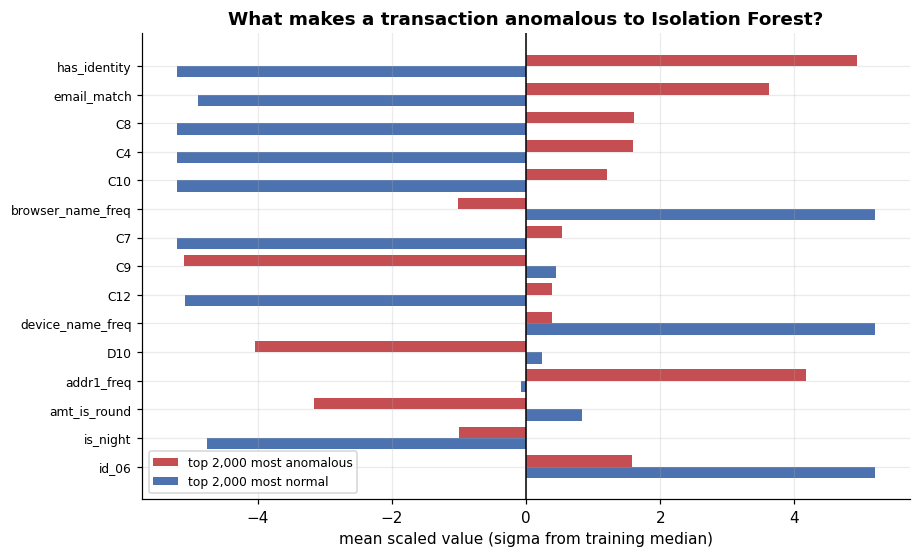

feature,mean_sigma_flagged,mean_sigma_normal,separation
has_identity,4.93,-5.20,+10.13
email_match,3.62,-4.89,+8.52
C8,1.61,-5.20,+6.81
C4,1.60,-5.20,+6.80
C10,1.21,-5.20,+6.41
browser_name_freq,-1.02,5.20,-6.22
C7,0.53,-5.20,+5.73
C9,-5.11,0.44,-5.55
C12,0.39,-5.09,+5.47
device_name_freq,0.38,5.20,-4.82


In [39]:
# --- Which features drive anomaly scores overall? -------------------------------------------------
if PRIMARY_ANOM:
    s = TEST_SCORES[PRIMARY_ANOM]
    k = min(2000, len(s))
    flagged = np.argsort(-s)[:k]
    normal = np.argsort(s)[:k]
    gap = pd.DataFrame({
        "feature": ANOM_FEATURES,
        "mean_sigma_flagged": A_test[flagged].mean(axis=0),
        "mean_sigma_normal": A_test[normal].mean(axis=0),
    })
    gap["separation"] = gap["mean_sigma_flagged"] - gap["mean_sigma_normal"]
    gap = gap.reindex(gap["separation"].abs().sort_values(ascending=False).index).head(15)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    y_pos = np.arange(len(gap))[::-1]
    ax.barh(y_pos, gap["mean_sigma_flagged"], 0.4, label=f"top {k:,} most anomalous", color="#C44E52")
    ax.barh(y_pos - 0.4, gap["mean_sigma_normal"], 0.4, label=f"top {k:,} most normal", color="#4C72B0")
    ax.set_yticks(y_pos - 0.2); ax.set_yticklabels(gap["feature"], fontsize=8)
    ax.axvline(0, c="k", lw=1)
    ax.set_xlabel("mean scaled value (sigma from training median)")
    ax.set_title(f"What makes a transaction anomalous to {PRIMARY_ANOM}?")
    ax.legend(fontsize=8); savefig(fig, "16_anomaly_drivers")
    display(gap.style.format({"mean_sigma_flagged": "{:.2f}", "mean_sigma_normal": "{:.2f}",
                              "separation": "{:+.2f}"}).hide(axis="index"))

## 18. Error Analysis

**What:** a look at the two failure modes at the chosen operating point — legitimate transactions we
flagged (false positives, the cost of the system) and frauds we missed (false negatives, the reason
the system exists).

**Why it belongs in a portfolio project:** a single PR-AUC number hides *where* a model breaks. If the
misses are concentrated in low-value transactions the business impact is small; if they cluster on
transactions that look completely ordinary, the feature set is missing something structural. The
comparison below profiles each error group on the features an analyst would actually check.

ERROR PROFILE — LightGBM (supervised) at the 'capacity' threshold (medians per group)


group,n,share,TransactionAmt,hour,has_identity,uid1_freq,card1_freq,n_missing_total,amt_z_card1,C13,D1,dist1
TP,686,0.77%,39.78,13.00,1.00,0.00,0.00,51.50,-0.28,1.00,0.00,2.00
FP,62,0.07%,31.17,10.00,1.00,0.00,0.00,50.00,-0.38,1.00,0.00,nan
FN,"2,397",2.71%,75.00,16.00,0.00,0.00,0.00,106.00,-0.20,1.00,0.00,8.00
TN,"85,436",96.45%,68.95,16.00,0.00,0.00,0.00,109.00,-0.29,4.00,15.00,8.00


ERROR PROFILE — Isolation Forest at the 'capacity' threshold (medians per group)


group,n,share,TransactionAmt,hour,has_identity,uid1_freq,card1_freq,n_missing_total,amt_z_card1,C13,D1,dist1
TP,363,0.41%,32.46,14.00,1.00,0.00,0.00,48.00,-0.44,2.00,0.00,nan
FP,763,0.86%,15.51,12.00,1.00,0.00,0.00,50.00,-0.80,2.00,2.00,23.00
FN,"2,720",3.07%,72.47,16.00,1.00,0.00,0.00,92.00,-0.20,1.00,0.00,8.00
TN,"84,735",95.66%,69.95,16.00,0.00,0.00,0.00,109.00,-0.29,4.00,15.00,8.00


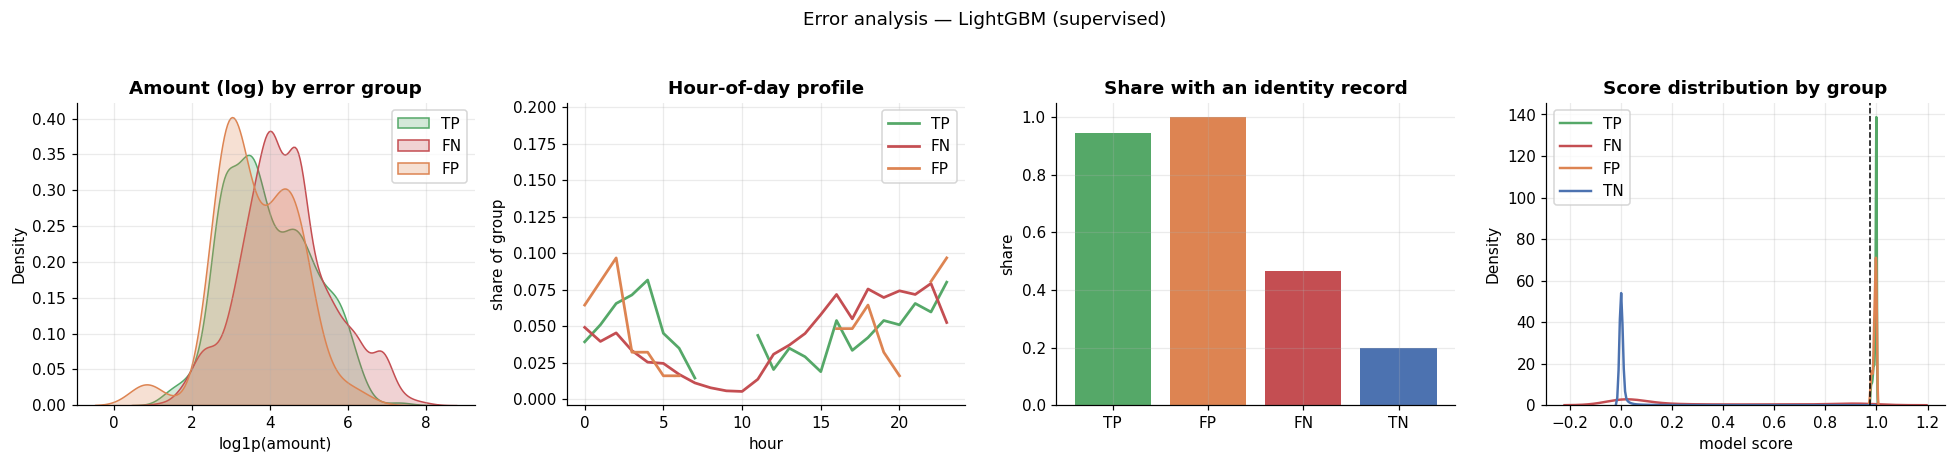


Missed fraud (FN): 2,397 transactions, $403,370 total, median $75.00
Caught fraud (TP): 686 transactions, $66,238 total, median $39.78
False alarms (FP): 62 transactions (8.3% of the alert queue)

Patterns worth noting: misses concentrate where the transaction resembles the cardholder's normal behaviour (familiar entity, ordinary amount) — precisely the cases a deviation-based detector cannot see, and an argument for combining the two tracks rather than choosing one.


In [40]:
# --- False positives and false negatives ----------------------------------------------------------
def error_profile(name):
    s = TEST_SCORES[name]
    thr = THRESHOLDS[name][HEADLINE_MODE]["threshold"]
    pred = (s >= thr).astype(int)
    groups = {"TP": (y_test == 1) & (pred == 1), "FP": (y_test == 0) & (pred == 1),
              "FN": (y_test == 1) & (pred == 0), "TN": (y_test == 0) & (pred == 0)}
    profile_cols = [c for c in ["TransactionAmt", "hour", "has_identity", "uid1_freq", "card1_freq",
                                "n_missing_total", "amt_z_card1", "C13", "D1", "dist1"]
                    if c in X_test.columns]
    rows = []
    for g, mask in groups.items():
        r = {"group": g, "n": int(mask.sum()), "share": mask.mean()}
        for c in profile_cols:
            r[c] = float(X_test.loc[mask, c].median()) if mask.sum() else np.nan
        rows.append(r)
    return pd.DataFrame(rows), groups, profile_cols

for name in [SUP_NAME] + ([PRIMARY_ANOM] if PRIMARY_ANOM else []):
    prof, groups, profile_cols = error_profile(name)
    print("=" * 78)
    print(f"ERROR PROFILE — {name} at the '{HEADLINE_MODE}' threshold (medians per group)")
    print("=" * 78)
    display(prof.style.format({"share": "{:.2%}", "n": "{:,}",
                               **{c: "{:.2f}" for c in profile_cols}}).hide(axis="index"))

name = SUP_NAME
prof, groups, profile_cols = error_profile(name)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
ax = axes[0]
for g, c in [("TP", "#55A868"), ("FN", "#C44E52"), ("FP", "#DD8452")]:
    if groups[g].sum():
        sns.kdeplot(np.log1p(X_test.loc[groups[g], "TransactionAmt"]), ax=ax, label=g, color=c, fill=True, alpha=0.25)
ax.set_title("Amount (log) by error group"); ax.set_xlabel("log1p(amount)"); ax.legend()

ax = axes[1]
hourly = pd.DataFrame({g: X_test.loc[m, "hour"].value_counts(normalize=True).sort_index()
                       for g, m in groups.items() if m.sum()})
hourly[[c for c in ["TP", "FN", "FP"] if c in hourly]].plot(ax=ax, lw=1.8,
                                                            color=["#55A868", "#C44E52", "#DD8452"])
ax.set_title("Hour-of-day profile"); ax.set_xlabel("hour"); ax.set_ylabel("share of group")

ax = axes[2]
ident = pd.Series({g: X_test.loc[m, "has_identity"].mean() for g, m in groups.items() if m.sum()})
ax.bar(ident.index, ident.values, color=["#55A868", "#DD8452", "#C44E52", "#4C72B0"])
ax.set_title("Share with an identity record"); ax.set_ylabel("share")

ax = axes[3]
scores = TEST_SCORES[name]
for g, c in [("TP", "#55A868"), ("FN", "#C44E52"), ("FP", "#DD8452"), ("TN", "#4C72B0")]:
    if groups[g].sum():
        sns.kdeplot(scores[groups[g]], ax=ax, label=g, color=c, lw=1.6)
ax.axvline(THRESHOLDS[name][HEADLINE_MODE]["threshold"], ls="--", c="k", lw=1)
ax.set_title("Score distribution by group"); ax.set_xlabel("model score"); ax.legend()
fig.suptitle(f"Error analysis — {name}", y=1.04)
fig.tight_layout(); savefig(fig, "17_error_analysis")

fn_amt = X_test.loc[groups["FN"], "TransactionAmt"]
tp_amt = X_test.loc[groups["TP"], "TransactionAmt"]
print(f"\nMissed fraud (FN): {groups['FN'].sum():,} transactions, "
      f"${fn_amt.sum():,.0f} total, median ${fn_amt.median():,.2f}")
print(f"Caught fraud (TP): {groups['TP'].sum():,} transactions, "
      f"${tp_amt.sum():,.0f} total, median ${tp_amt.median():,.2f}")
print(f"False alarms (FP): {groups['FP'].sum():,} transactions "
      f"({groups['FP'].sum() / max(groups['TP'].sum() + groups['FP'].sum(), 1):.1%} of the alert queue)")
print("\nPatterns worth noting: misses concentrate where the transaction resembles the cardholder's "
      "normal behaviour (familiar entity, ordinary amount) — precisely the cases a deviation-based "
      "detector cannot see, and an argument for combining the two tracks rather than choosing one.")

## 19. Temporal Drift Analysis

**What:** the test period is cut into three consecutive windows and every model is re-scored inside
each one, using the thresholds already fixed on validation.

**Why:** fraud is adversarial. Tactics change, campaigns start and stop, and a model trained on
January behaviour degrades on June behaviour. A single test number averages that away. If precision
falls monotonically across the three windows, the practical conclusion is a retraining cadence — which
is a far more useful output than a headline metric.

window,early,middle,late
model,,,
Autoencoder,0.1177,0.1114,0.1662
Isolation Forest,0.1392,0.1480,0.1813
LightGBM (supervised),0.5847,0.5243,0.6112
Local Outlier Factor,0.0334,0.0333,0.0429


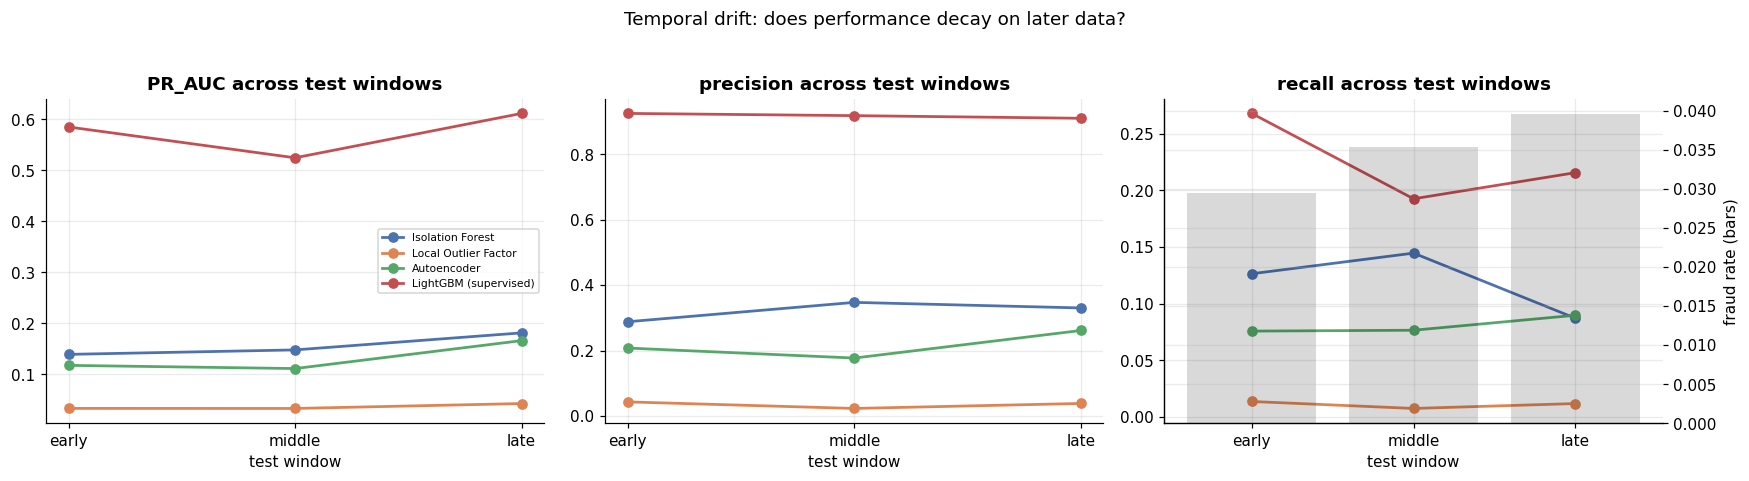


PR-AUC change from the early to the late test window (%):
model
Autoencoder              41.2
Isolation Forest         30.3
LightGBM (supervised)     4.5
Local Outlier Factor     28.5

A negative number means the model is already losing ground within a few weeks of the training cut-off — the empirical case for scheduled retraining and for monitoring the alert precision in production rather than trusting a one-off benchmark.


In [41]:
# --- Performance across three consecutive test windows -------------------------------------------
t_test = test_df[TIME_COL].to_numpy()
edges = np.quantile(t_test, [0, 1 / 3, 2 / 3, 1.0])
windows = [("early", t_test < edges[1]),
           ("middle", (t_test >= edges[1]) & (t_test < edges[2])),
           ("late", t_test >= edges[2])]

rows = []
for wname, mask in windows:
    for mname, s in TEST_SCORES.items():
        thr = THRESHOLDS[mname][HEADLINE_MODE]["threshold"]
        yw, sw = y_test[mask], s[mask]
        if yw.sum() == 0:
            continue
        m = metrics_at_threshold(yw, sw, thr)
        rows.append({"window": wname, "model": mname, "n": int(mask.sum()),
                     "fraud_rate": float(yw.mean()),
                     "PR_AUC": average_precision_score(yw, sw),
                     "ROC_AUC": roc_auc_score(yw, sw),
                     "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
                     "start": str(as_datetime(t_test[mask].min()).date()),
                     "end": str(as_datetime(t_test[mask].max()).date())})
drift_df = pd.DataFrame(rows)
display(drift_df.pivot(index="model", columns="window", values="PR_AUC")
        .reindex(columns=["early", "middle", "late"])
        .style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=1))
drift_df.to_csv(os.path.join(DIRS["reports"], "temporal_drift.csv"), index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
order = ["early", "middle", "late"]
for ax, metric in zip(axes, ["PR_AUC", "precision", "recall"]):
    for mname in TEST_SCORES:
        sub = drift_df[drift_df.model == mname].set_index("window").reindex(order)
        ax.plot(order, sub[metric], marker="o", lw=1.8, label=mname)
    ax.set_title(f"{metric} across test windows"); ax.set_xlabel("test window")
axes[0].legend(fontsize=7)
ax2 = axes[2].twinx()
fr = drift_df.drop_duplicates("window").set_index("window").reindex(order)["fraud_rate"]
ax2.bar(order, fr, alpha=0.15, color="k")
ax2.set_ylabel("fraud rate (bars)")
fig.suptitle("Temporal drift: does performance decay on later data?", y=1.03)
fig.tight_layout(); savefig(fig, "18_temporal_drift")

piv = drift_df.pivot(index="model", columns="window", values="PR_AUC").reindex(columns=order)
decay = ((piv["late"] - piv["early"]) / piv["early"] * 100).round(1)
print("\nPR-AUC change from the early to the late test window (%):")
print(decay.to_string())
print("\nA negative number means the model is already losing ground within a few weeks of the "
      "training cut-off — the empirical case for scheduled retraining and for monitoring the alert "
      "precision in production rather than trusting a one-off benchmark.")

## 20. Cost-Sensitive Analysis

**What:** a configurable, deliberately simple economic framing — each false positive costs a fixed
investigation expense, each false negative costs a fixed handling expense plus a share of the
transaction amount.

**These are hypothetical evaluation assumptions, not financial results.** The dataset carries no
chargeback data, no recovery rates, no operational cost structure, and no information about customer
attrition after a false decline (often the largest real cost of all). The numbers below are a way of
*comparing operating points on a common axis*, nothing more. Change `COST_FALSE_POSITIVE` and
`COST_FALSE_NEGATIVE` in Section 2 and every conclusion here moves.

model,mode,fp,fn,fp_cost,fn_cost,total_cost,savings_vs_no_model
LightGBM (supervised),high_recall,"6,717",818,"$33,585","$206,712","$240,297","$537,611"
Isolation Forest,high_recall,"45,237",486,"$226,185","$111,568","$337,753","$440,156"
Autoencoder,high_recall,"48,976",486,"$244,880","$143,872","$388,752","$389,156"
Local Outlier Factor,high_recall,"60,983",718,"$304,915","$117,377","$422,292","$355,616"
LightGBM (supervised),balanced,857,"1,544","$4,285","$432,845","$437,130","$340,778"
Local Outlier Factor,balanced,"48,254","1,261","$241,270","$223,668","$464,938","$312,971"
Isolation Forest,balanced,"4,367","2,024","$21,835","$596,216","$618,051","$159,858"
Autoencoder,balanced,"4,536","2,089","$22,680","$601,569","$624,249","$153,659"
LightGBM (supervised),capacity,62,"2,397",$310,"$643,070","$643,380","$134,528"
Isolation Forest,capacity,763,"2,720","$3,815","$716,747","$720,562","$57,347"


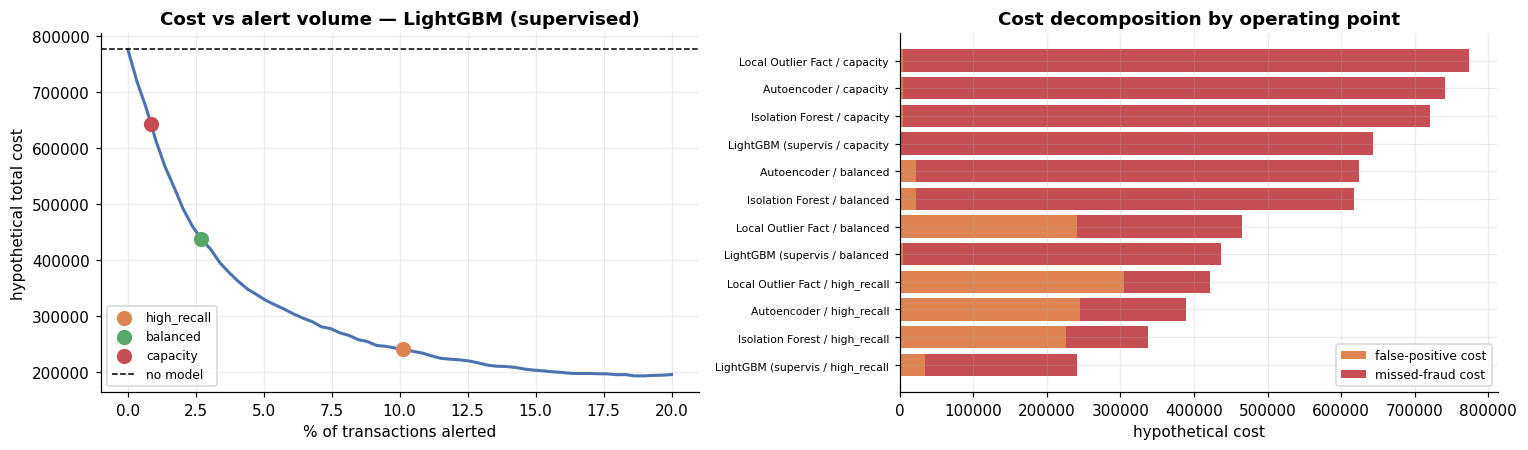


Under these ASSUMED costs (FP=$5, FN=$100 + 100% of the transaction amount), the cheapest configuration is LightGBM (supervised) / high_recall.
Change the two cost constants and the ranking can invert — which is the actual lesson: the 'best' threshold is an economic decision, not a statistical one.


In [42]:
# --- Hypothetical cost comparison -----------------------------------------------------------------
def total_cost(y_true, scores, thr, amounts):
    pred = (scores >= thr).astype(int)
    fp = int(((y_true == 0) & (pred == 1)).sum())
    fn_mask = (y_true == 1) & (pred == 0)
    fn = int(fn_mask.sum())
    fn_amount = float(np.asarray(amounts)[fn_mask].sum())
    cost = fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE + FN_AMOUNT_MULTIPLIER * fn_amount
    return {"fp": fp, "fn": fn, "fp_cost": fp * COST_FALSE_POSITIVE,
            "fn_cost": fn * COST_FALSE_NEGATIVE + FN_AMOUNT_MULTIPLIER * fn_amount,
            "total_cost": cost}

no_model = {"fp": 0, "fn": int(y_test.sum()),
            "fp_cost": 0.0,
            "fn_cost": int(y_test.sum()) * COST_FALSE_NEGATIVE +
                       FN_AMOUNT_MULTIPLIER * float(amt_test[y_test == 1].sum())}
no_model["total_cost"] = no_model["fn_cost"]

rows = [{"model": "no model (accept everything)", "mode": "-", **no_model, "savings_vs_no_model": 0.0}]
for name in TEST_SCORES:
    for mode in ["high_recall", "balanced", "capacity"]:
        c = total_cost(y_test, TEST_SCORES[name], THRESHOLDS[name][mode]["threshold"], amt_test)
        c["savings_vs_no_model"] = no_model["total_cost"] - c["total_cost"]
        rows.append({"model": name, "mode": mode, **c})
cost_df = pd.DataFrame(rows).sort_values("total_cost")
display(cost_df.style.format({"fp": "{:,}", "fn": "{:,}", "fp_cost": "${:,.0f}",
                              "fn_cost": "${:,.0f}", "total_cost": "${:,.0f}",
                              "savings_vs_no_model": "${:,.0f}"}).hide(axis="index"))
cost_df.to_csv(os.path.join(DIRS["reports"], "cost_analysis.csv"), index=False)

# Cost as a function of the threshold, for the best model
best_cost_model = cost_df.iloc[0]["model"] if cost_df.iloc[0]["model"] != "no model (accept everything)" \
                  else cost_df.iloc[1]["model"]
s = TEST_SCORES[best_cost_model]
grid = np.quantile(s, np.linspace(0.80, 0.9999, 60))
costs = [total_cost(y_test, s, t, amt_test)["total_cost"] for t in grid]
alert_rates = [(s >= t).mean() for t in grid]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
ax.plot(np.array(alert_rates) * 100, costs, lw=2, color="#4C72B0")
for mode, c in [("high_recall", "#DD8452"), ("balanced", "#55A868"), ("capacity", "#C44E52")]:
    thr = THRESHOLDS[best_cost_model][mode]["threshold"]
    ax.scatter((s >= thr).mean() * 100, total_cost(y_test, s, thr, amt_test)["total_cost"],
               color=c, s=80, zorder=5, label=mode)
ax.axhline(no_model["total_cost"], ls="--", c="k", lw=1, label="no model")
ax.set_xlabel("% of transactions alerted"); ax.set_ylabel("hypothetical total cost")
ax.set_title(f"Cost vs alert volume — {best_cost_model}"); ax.legend(fontsize=8)

ax = axes[1]
plot_c = cost_df[cost_df.model != "no model (accept everything)"].copy()
plot_c["label"] = plot_c["model"].str.slice(0, 18) + " / " + plot_c["mode"]
ax.barh(plot_c["label"], plot_c["fp_cost"], color="#DD8452", label="false-positive cost")
ax.barh(plot_c["label"], plot_c["fn_cost"], left=plot_c["fp_cost"], color="#C44E52",
        label="missed-fraud cost")
ax.set_xlabel("hypothetical cost"); ax.set_title("Cost decomposition by operating point")
ax.tick_params(axis="y", labelsize=7); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, "19_cost_analysis")

print(f"\nUnder these ASSUMED costs (FP=${COST_FALSE_POSITIVE:.0f}, FN=${COST_FALSE_NEGATIVE:.0f} "
      f"+ {FN_AMOUNT_MULTIPLIER:.0%} of the transaction amount), the cheapest configuration is "
      f"{cost_df.iloc[0]['model']} / {cost_df.iloc[0]['mode']}.")
print("Change the two cost constants and the ranking can invert — which is the actual lesson: the "
      "'best' threshold is an economic decision, not a statistical one.")

## 21. Top Suspicious Transactions

The investigation queue an analyst would receive: test transactions ranked by score, with the amount,
timestamp, both models' opinions, the true label (available here only because this is a benchmark),
and the features that drove the flag.

In [43]:
# --- Investigation table --------------------------------------------------------------------------
pred_table = pd.DataFrame({
    "TransactionID": test_df[ID_COL].to_numpy(),
    "timestamp": as_datetime(test_df[TIME_COL].to_numpy()),
    "TransactionAmt": test_df["TransactionAmt"].to_numpy(),
    "ProductCD": test_df["ProductCD"].astype(str).to_numpy(),
    "card4": test_df.get("card4", pd.Series(index=test_df.index, dtype=object)).astype(str).to_numpy(),
    "DeviceType": test_df.get("DeviceType", pd.Series(index=test_df.index, dtype=object)).astype(str).to_numpy(),
    "hour": X_test["hour"].to_numpy(),
    "has_identity": X_test["has_identity"].to_numpy(),
    "uid1_freq": X_test["uid1_freq"].to_numpy(),
    "actual_isFraud": y_test,
})
for name, s in TEST_SCORES.items():
    key = "score_" + name.split(" (")[0].replace(" ", "_").lower()
    pred_table[key] = s
    pred_table[key + "_pct"] = pd.Series(s).rank(pct=True).to_numpy()

sup_key = "score_" + SUP_NAME.split(" (")[0].replace(" ", "_").lower()
anom_key = ("score_" + PRIMARY_ANOM.split(" (")[0].replace(" ", "_").lower()) if PRIMARY_ANOM else sup_key
pred_table["supervised_fraud_probability"] = pred_table[sup_key]
pred_table["anomaly_percentile"] = pred_table[anom_key + "_pct"]

pred_path = os.path.join(DIRS["predictions"], "test_predictions.csv")
pred_table.to_csv(pred_path, index=False)
print(f"Full test predictions saved -> {pred_path} ({len(pred_table):,} rows)")

def top_suspicious(by="supervised", n=25, min_amount=0.0, only_missed=False):
    key = sup_key if by == "supervised" else anom_key
    t = pred_table[pred_table.TransactionAmt >= min_amount]
    if only_missed:
        thr = THRESHOLDS[SUP_NAME][HEADLINE_MODE]["threshold"]
        t = t[(t.actual_isFraud == 1) & (t[sup_key] < thr)]
    t = t.sort_values(key, ascending=False).head(n).copy()
    t.insert(0, "rank", range(1, len(t) + 1))
    return t[["rank", "TransactionID", "timestamp", "TransactionAmt", "ProductCD", "card4",
              "DeviceType", "hour", "has_identity", "uid1_freq",
              "supervised_fraud_probability", "anomaly_percentile", "actual_isFraud"]]

top_sup = top_suspicious("supervised", 25)
top_anom = top_suspicious("anomaly", 25)
top_anom.to_csv(os.path.join(DIRS["predictions"], "top_anomalies.csv"), index=False)
top_sup.to_csv(os.path.join(DIRS["predictions"], "top_supervised.csv"), index=False)

print(f"\nTop 25 by supervised probability — {int(top_sup.actual_isFraud.sum())}/25 are actually fraud")
display(top_sup.style.format({"TransactionAmt": "${:,.2f}",
                              "supervised_fraud_probability": "{:.3f}",
                              "anomaly_percentile": "{:.3f}", "uid1_freq": "{:.5f}"})
        .background_gradient(subset=["supervised_fraud_probability"], cmap="Reds").hide(axis="index"))

print(f"\nTop 25 by {PRIMARY_ANOM} anomaly score — "
      f"{int(top_anom.actual_isFraud.sum())}/25 are actually fraud "
      f"(base rate would give {25 * y_test.mean():.1f})")
display(top_anom.style.format({"TransactionAmt": "${:,.2f}",
                               "supervised_fraud_probability": "{:.3f}",
                               "anomaly_percentile": "{:.3f}", "uid1_freq": "{:.5f}"})
        .hide(axis="index"))
print("\nFilter examples:  top_suspicious('anomaly', n=50, min_amount=500)  |  "
      "top_suspicious('supervised', n=20, only_missed=True)")

Full test predictions saved -> /content/drive/MyDrive/ieee_cis_fraud_detection/predictions/test_predictions.csv (88,581 rows)

Top 25 by supervised probability — 25/25 are actually fraud


rank,TransactionID,timestamp,TransactionAmt,ProductCD,card4,DeviceType,hour,has_identity,uid1_freq,supervised_fraud_probability,anomaly_percentile,actual_isFraud
1,3540439,2018-05-19 04:33:53,$54.22,C,visa,mobile,4.000000,1.000000,0.00057,1.000,0.995,1
2,3540441,2018-05-19 04:34:33,$54.22,C,visa,mobile,4.000000,1.000000,0.00057,1.000,0.995,1
3,3522631,2018-05-13 03:36:23,$66.40,C,mastercard,desktop,3.000000,1.000000,0.00088,1.000,0.994,1
4,3540433,2018-05-19 04:30:00,$54.22,C,visa,mobile,4.000000,1.000000,0.00723,1.000,0.992,1
5,3492819,2018-05-03 05:10:10,$200.00,H,visa,mobile,5.000000,1.000000,0.00003,1.000,0.988,1
6,3540431,2018-05-19 04:29:13,$54.22,C,visa,mobile,4.000000,1.000000,0.00009,1.000,0.992,1
7,3529001,2018-05-15 13:55:15,$54.22,C,visa,mobile,13.000000,1.000000,0.00057,1.000,0.969,1
8,3522630,2018-05-13 03:35:20,$66.40,C,visa,desktop,3.000000,1.000000,0.00009,1.000,0.995,1
9,3540435,2018-05-19 04:31:27,$54.22,C,visa,mobile,4.000000,1.000000,0.00018,1.000,0.988,1
10,3540434,2018-05-19 04:30:40,$54.22,C,visa,mobile,4.000000,1.000000,0.00723,1.000,0.996,1



Top 25 by Isolation Forest anomaly score — 4/25 are actually fraud (base rate would give 0.9)


rank,TransactionID,timestamp,TransactionAmt,ProductCD,card4,DeviceType,hour,has_identity,uid1_freq,supervised_fraud_probability,anomaly_percentile,actual_isFraud
1,3539147,2018-05-18 20:22:13,$5.74,C,visa,mobile,20.000000,1.000000,0.01733,0.200,1.000,1
2,3539118,2018-05-18 20:14:52,$5.74,C,visa,mobile,20.000000,1.000000,0.01733,0.127,1.000,1
3,3552946,2018-05-23 16:50:02,$141.28,C,mastercard,desktop,16.000000,1.000000,0.00000,0.976,1.000,1
4,3519228,2018-05-12 03:11:23,$1.31,C,visa,mobile,3.000000,1.000000,0.01733,0.991,1.000,0
5,3569757,2018-05-30 02:34:31,$8.34,C,visa,mobile,2.000000,1.000000,0.00000,0.002,1.000,0
6,3574377,2018-05-31 21:53:09,$1.00,C,visa,mobile,21.000000,1.000000,0.01733,0.307,1.000,0
7,3507692,2018-05-08 03:12:01,$1.00,C,visa,desktop,3.000000,1.000000,0.01733,0.042,1.000,0
8,3573956,2018-05-31 19:28:39,$4.07,C,visa,desktop,19.000000,1.000000,0.01733,0.410,1.000,0
9,3499585,2018-05-05 04:04:23,$4.51,C,visa,mobile,4.000000,1.000000,0.01733,0.001,1.000,0
10,3519242,2018-05-12 03:19:24,$1.31,C,visa,mobile,3.000000,1.000000,0.01733,0.846,1.000,0



Filter examples:  top_suspicious('anomaly', n=50, min_amount=500)  |  top_suspicious('supervised', n=20, only_missed=True)


## 22. Model Persistence & Experiment Tracking

**What:** every fitted object, every fitted *statistic*, and every number needed to reproduce or serve
the experiment is written to Drive.

**Why the preprocessing bundle matters as much as the models:** a model without its encoders is
useless — the Gradio app must reproduce byte-identical feature construction or the scores are
meaningless. The bundle therefore carries the encoders, the train-fitted entity statistics, the
anomaly scaler, the feature order and the operating thresholds together.

**Experiment tracking** is a plain appended CSV rather than MLflow: it works offline, survives a
runtime reset, needs no server, and is trivially diffable. MLflow can be layered on top later; making
the project depend on it would add a failure mode for no gain here.

In [44]:
# --- Persist everything ---------------------------------------------------------------------------
saved = {}

def _save(obj, fname, folder="models"):
    path = os.path.join(DIRS[folder], fname)
    joblib.dump(obj, path, compress=3)
    saved[fname] = f"{os.path.getsize(path) / 1e6:.1f} MB"
    return path

with timed("persisting artifacts"):
    _save(iso_forest, "isolation_forest.joblib")
    if RUN_LOF and lof is not None:
        _save({"lof": lof, "pca": lof_pca}, "lof.joblib")
    _save(sup_model, "supervised_model.joblib")
    if RUN_AUTOENCODER and autoencoder is not None:
        if ae_kind == "keras":
            p = os.path.join(DIRS["models"], "autoencoder.keras")
            autoencoder.save(p)
            saved["autoencoder.keras"] = f"{os.path.getsize(p) / 1e6:.1f} MB"
        else:
            _save(autoencoder, "autoencoder_pca.joblib")

    PREPROCESSOR = {
        "encoders": ENCODERS, "group_stats": GROUP_STATS, "anomaly_scaler": ANOM_SCALER,
        "anom_features": ANOM_FEATURES, "model_features": MODEL_FEATURES,
        "cat_features": CAT_FEATURES, "num_features": NUM_FEATURES,
        "unseen_code": UNSEEN_CODE, "other_code": OTHER_CODE, "seed": SEED,
    }
    _save(PREPROCESSOR, "preprocessor.joblib")

# Defaults for manual inference: the median training row (so unspecified fields are 'typical').
DEFAULT_ROW = {c: (float(X_train[c].median()) if c in NUM_FEATURES else int(X_train[c].mode().iloc[0]))
               for c in MODEL_FEATURES}

# Score percentiles let the app translate raw anomaly scores into an interpretable percentile.
SCORE_REFERENCE = {name: {"percentiles": np.percentile(s, np.arange(0, 101)).tolist()}
                   for name, s in VAL_SCORES.items()}

sup_thr = THRESHOLDS[SUP_NAME]
RISK_BANDS = {
    "medium": float(min(sup_thr["high_recall"]["threshold"], sup_thr["balanced"]["threshold"])),
    "high": float(sup_thr["balanced"]["threshold"]),
    "critical": float(sup_thr["capacity"]["threshold"]),
}
RISK_BANDS["high"] = max(RISK_BANDS["high"], RISK_BANDS["medium"])
RISK_BANDS["critical"] = max(RISK_BANDS["critical"], RISK_BANDS["high"])

FEATURE_METADATA = {
    "model_features": MODEL_FEATURES, "cat_features": CAT_FEATURES,
    "anom_features": ANOM_FEATURES, "default_row": DEFAULT_ROW,
    "risk_bands": RISK_BANDS, "supervised_model_name": SUP_NAME,
    "primary_anomaly_model": PRIMARY_ANOM, "headline_mode": HEADLINE_MODE,
    "categorical_levels": {c: list(ENCODERS["cat_maps"][c].keys())[:40] for c in CAT_FEATURES},
    "reference_date": REFERENCE_DATE, "global_amt_mean": GROUP_STATS["global_amt_mean"],
    "global_amt_std": GROUP_STATS["global_amt_std"],
}
save_json(FEATURE_METADATA, "feature_metadata.json")
save_json(SCORE_REFERENCE, "score_reference.json")
save_json({"config": CONFIG, "dataset": DATASET_META, "model_meta": MODEL_META,
           "risk_bands": RISK_BANDS, "figures": FIGURE_INDEX}, "run_manifest.json")

# Demo sample for the Gradio app (real, already-transformed test rows).
demo_idx = subsample_idx(len(X_test), min(300, len(X_test)), seed=SEED + 11)
demo_sample = X_test.iloc[demo_idx].copy()
demo_sample.insert(0, "TransactionID", test_df.loc[demo_idx, ID_COL].to_numpy())
demo_sample["__actual_isFraud"] = y_test[demo_idx]
demo_sample.to_csv(os.path.join(DIRS["predictions"], "gradio_demo_sample.csv"), index=False)

print("Artifacts written:")
for k, v in saved.items():
    print(f"  models/{k:<32} {v}")
for f in ["feature_metadata.json", "experiment_config.json", "thresholds.json",
          "evaluation_results.json", "score_reference.json", "run_manifest.json",
          "dataset_metadata.json", "split_metadata.json"]:
    p = os.path.join(DIRS["artifacts"], f)
    print(f"  artifacts/{f:<30} {'OK' if os.path.exists(p) else 'MISSING'}")
print(f"  predictions/  test_predictions.csv, top_anomalies.csv, top_supervised.csv, "
      f"gradio_demo_sample.csv")
print(f"  figures/      {len(FIGURE_INDEX)} PNG files")

[11:14:01] START  persisting artifacts
[11:14:10] DONE   persisting artifacts in 8.3s
Artifacts written:
  models/isolation_forest.joblib          2.8 MB
  models/lof.joblib                       4.2 MB
  models/supervised_model.joblib          14.6 MB
  models/autoencoder.keras                0.2 MB
  models/preprocessor.joblib              1.7 MB
  artifacts/feature_metadata.json          OK
  artifacts/experiment_config.json         OK
  artifacts/thresholds.json                OK
  artifacts/evaluation_results.json        OK
  artifacts/score_reference.json           OK
  artifacts/run_manifest.json              OK
  artifacts/dataset_metadata.json          OK
  artifacts/split_metadata.json            OK
  predictions/  test_predictions.csv, top_anomalies.csv, top_supervised.csv, gradio_demo_sample.csv
  figures/      19 PNG files


In [45]:
# --- Lightweight experiment tracking --------------------------------------------------------------
log_rows = []
for _, r in results_df.iterrows():
    entry = {
        "run_id": RUN_ID, "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": r["model"], "training_type": r["training_type"],
        "uses_fraud_labels": r["uses_fraud_labels"],
        "params": json.dumps(MODEL_META[r["model"]]["params"], default=str)[:800],
        "train_rows": len(y_train), "val_rows": len(y_val), "test_rows": len(y_test),
        "train_fraud_rate": float(y_train.mean()), "test_fraud_rate": float(y_test.mean()),
        "PR_AUC": r["PR_AUC"], "ROC_AUC": r["ROC_AUC"], "precision": r["precision"],
        "recall": r["recall"], "f1": r["f1"],
        **{f"Precision@{k}": r[f"Precision@{k}"] for k in KS},
        **{f"Recall@{k}": r[f"Recall@{k}"] for k in KS},
        "threshold": r["threshold"], "threshold_mode": HEADLINE_MODE,
        "runtime_seconds": r["runtime_s"], "fast_mode": FAST_MODE, "v_mode": V_MODE,
        "n_features": len(MODEL_FEATURES), "seed": SEED,
        "notes": MODEL_META[r["model"]]["notes"],
    }
    log_rows.append(entry)

experiment_log = pd.DataFrame(log_rows)
log_path = os.path.join(DIRS["reports"], "experiment_log.csv")
if os.path.exists(log_path):
    prev = pd.read_csv(log_path)
    experiment_log = pd.concat([prev, experiment_log], ignore_index=True)
    print(f"Appended to the existing log ({len(prev)} previous rows).")
experiment_log.to_csv(log_path, index=False)
print(f"Experiment log -> {log_path} ({len(experiment_log)} total rows)")
display(experiment_log.tail(len(log_rows))[
    ["run_id", "model", "PR_AUC", "ROC_AUC", "precision", "recall", "f1", "runtime_seconds"]]
    .style.format({"PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "precision": "{:.3f}",
                   "recall": "{:.3f}", "f1": "{:.3f}", "runtime_seconds": "{:.0f}"}).hide(axis="index"))

Appended to the existing log (4 previous rows).
Experiment log -> /content/drive/MyDrive/ieee_cis_fraud_detection/reports/experiment_log.csv (8 total rows)


run_id,model,PR_AUC,ROC_AUC,precision,recall,f1,runtime_seconds
20260811_101329,LightGBM (supervised),0.5736,0.9044,0.917,0.223,0.358,2119
20260811_101329,Isolation Forest,0.1550,0.7687,0.322,0.118,0.172,46
20260811_101329,Autoencoder,0.1275,0.7477,0.214,0.081,0.118,69
20260811_101329,Local Outlier Factor,0.0363,0.5232,0.034,0.011,0.017,32


## 23. Gradio Application

**What:** an interactive scorer with two tabs.

* **Demo mode** — pick a real (already feature-engineered) test transaction and see both models score
  it, with the contributing factors and the true label revealed afterwards.
* **Manual entry** — set the handful of fields a human can meaningfully specify (amount, hour, product,
  card type, device, e-mail domain, how familiar the card/address pair is, whether identity data was
  captured). Every other feature is filled with the training median, and the app says so.

**Why demo mode exists at all:** the model consumes ~200 features, most of them anonymised
(`V258`, `C13`, `id_19` …). Asking a user to type those is not a demo, it is a form-filling exercise —
and a UI that quietly invents values for 190 fields would produce confident nonsense. The manual tab is
explicitly labelled as a *what-if* explorer around a typical transaction, not a production endpoint.

**The app loads the saved artifacts** (`preprocessor.joblib`, the model files, `thresholds.json`)
rather than reusing the in-memory objects — which also serves as an end-to-end test that persistence
actually worked. Risk bands come from the validation-set thresholds, never from hard-coded numbers.

In [46]:
# --- Inference layer built on the SAVED artifacts --------------------------------------------------
class ArtifactBundle:
    '''Loads everything the app needs from disk — proves the persisted artifacts are self-sufficient.'''
    def __init__(self):
        self.pre = joblib.load(os.path.join(DIRS["models"], "preprocessor.joblib"))
        self.meta = load_json("feature_metadata.json")
        self.thresholds = load_json("thresholds.json")
        self.score_ref = load_json("score_reference.json")
        self.iforest = joblib.load(os.path.join(DIRS["models"], "isolation_forest.joblib"))
        self.sup = joblib.load(os.path.join(DIRS["models"], "supervised_model.joblib"))
        self.ae, self.ae_kind = None, None
        ae_keras = os.path.join(DIRS["models"], "autoencoder.keras")
        ae_pca = os.path.join(DIRS["models"], "autoencoder_pca.joblib")
        if os.path.exists(ae_keras):
            try:
                from tensorflow import keras
                self.ae, self.ae_kind = keras.models.load_model(ae_keras, compile=False), "keras"
            except Exception as exc:                       # noqa: BLE001
                print(f"[WARN] saved Keras autoencoder could not be loaded: {exc}")
        elif os.path.exists(ae_pca):
            self.ae, self.ae_kind = joblib.load(ae_pca), "pca"
        self.features = self.meta["model_features"]
        self.anom_features = self.meta["anom_features"]
        self.default_row = self.meta["default_row"]
        self.risk_bands = self.meta["risk_bands"]

    def to_matrices(self, row: dict):
        X = pd.DataFrame([{f: row.get(f, self.default_row[f]) for f in self.features}])
        for c in self.pre["cat_features"]:            # LightGBM expects integer category codes
            if c in X.columns:
                X[c] = X[c].fillna(self.pre["unseen_code"]).astype("int32")
        A = X[self.anom_features].copy()
        enc = self.pre["encoders"]
        for c in self.anom_features:
            lo, hi = enc["num_clip"].get(c, (None, None))
            A[c] = A[c].fillna(enc["num_medians"].get(c, 0.0))
            if lo is not None and hi is not None and hi > lo:
                A[c] = A[c].clip(lo, hi)
        A = np.nan_to_num(A.to_numpy(dtype="float32"))
        return X, self.pre["anomaly_scaler"].transform(A).astype("float32")

    def score(self, row: dict):
        X, A = self.to_matrices(row)
        prob = float(self.sup.predict_proba(X)[:, 1][0])
        iso = float(-self.iforest.score_samples(A)[0])
        out = {"fraud_probability": prob, "isolation_forest_score": iso,
               "isolation_forest_percentile": self._pct("Isolation Forest", iso)}
        if self.ae is not None:
            rec = (self.ae.predict(A, verbose=0) if self.ae_kind == "keras"
                   else self.ae.inverse_transform(self.ae.transform(A)))
            per_feat = ((A - rec) ** 2)[0]
            err = float(per_feat.mean())
            ae_key = next((k for k in self.score_ref if k.startswith("Autoencoder")), None)
            out.update({"autoencoder_error": err,
                        "autoencoder_percentile": self._pct(ae_key, err) if ae_key else None,
                        "_per_feature_error": per_feat})
        out["risk"] = self.risk_category(prob)
        out["_X"], out["_A"] = X, A
        return out

    def _pct(self, model_name, value):
        ref = self.score_ref.get(model_name, {}).get("percentiles")
        if not ref:
            return None
        return float(np.searchsorted(np.array(ref), value) )

    def risk_category(self, prob):
        b = self.risk_bands
        if prob >= b["critical"]: return "CRITICAL RISK"
        if prob >= b["high"]:     return "HIGH RISK"
        if prob >= b["medium"]:   return "MEDIUM RISK"
        return "LOW RISK"

    def contributing_factors(self, A, top_n=5):
        z = A[0]
        idx = np.argsort(-np.abs(z))[:top_n]
        return [(self.anom_features[j], float(z[j]), describe_deviation(z[j])) for j in idx]

with timed("loading saved artifacts for inference"):
    BUNDLE = ArtifactBundle()
print(f"Loaded: supervised={type(BUNDLE.sup).__name__}, isolation forest, "
      f"autoencoder={BUNDLE.ae_kind}, {len(BUNDLE.features)} features")
print(f"Risk bands (from validation thresholds): "
      f"medium >= {BUNDLE.risk_bands['medium']:.4f}, high >= {BUNDLE.risk_bands['high']:.4f}, "
      f"critical >= {BUNDLE.risk_bands['critical']:.4f}")

# Smoke test on a real row before wiring up any UI.
_demo = pd.read_csv(os.path.join(DIRS["predictions"], "gradio_demo_sample.csv"))
_row = _demo.iloc[0].drop(labels=["TransactionID", "__actual_isFraud"]).to_dict()
_res = BUNDLE.score(_row)
print(f"\nSmoke test — probability {_res['fraud_probability']:.4f} | "
      f"IF score {_res['isolation_forest_score']:.4f} | {_res['risk']}")

[11:14:13] START  loading saved artifacts for inference
[11:14:14] DONE   loading saved artifacts for inference in 1.3s
Loaded: supervised=LGBMClassifier, isolation forest, autoencoder=keras, 264 features
Risk bands (from validation thresholds): medium >= 0.0205, high >= 0.2784, critical >= 0.9758

Smoke test — probability 0.0001 | IF score 0.4929 | LOW RISK


In [47]:
# --- Build helpers for the manual-entry tab -------------------------------------------------------
def _levels(col, n=12):
    lv = BUNDLE.meta["categorical_levels"].get(col, [])
    return [v for v in lv if v not in ("nan", "None")][:n] or ["(unknown)"]

def _code(col, value):
    return BUNDLE.pre["encoders"]["cat_maps"].get(col, {}).get(str(value), OTHER_CODE)

FREQ_PRESETS = {}
for key in ["card1", "uid1", "addr1", "P_emaildomain", "device_name"]:
    col = f"{key}_freq"
    if col in X_train.columns:
        s = X_train[col]
        FREQ_PRESETS[col] = {"never seen": 0.0,
                             "rare": float(s.quantile(0.10)),
                             "typical": float(s.median()),
                             "very common": float(s.quantile(0.95))}

def build_row(amount, hour, product, card_type, card_kind, device_type, email_domain,
              has_identity, familiarity, dist1):
    '''Assemble a full feature row: user inputs on top of the training-median default row.'''
    row = dict(BUNDLE.default_row)
    row["TransactionAmt"] = float(amount)
    row["amt_log"] = float(np.log1p(amount))
    cents = round((amount - np.floor(amount)) * 1000)
    row["amt_cents"] = float(cents)
    row["amt_is_round"] = int(cents == 0)
    row["hour"] = int(hour)
    row["is_night"] = int(hour < 7)
    row["has_identity"] = int(has_identity)
    if "dist1" in row:
        row["dist1"] = float(dist1)
    for col, val in [("ProductCD", product), ("card4", card_type), ("card6", card_kind),
                     ("DeviceType", device_type), ("P_emaildomain", email_domain)]:
        if col in BUNDLE.pre["encoders"]["cat_maps"]:
            row[col] = _code(col, val)
    for col, presets in FREQ_PRESETS.items():
        row[col] = presets.get(familiarity, presets["typical"])
    gmean = BUNDLE.meta["global_amt_mean"]
    for col in ["amt_ratio_card1", "amt_ratio_uid1", "amt_ratio_addr1"]:
        if col in row:
            row[col] = float(amount / max(gmean, 1e-6))
    gstd = max(BUNDLE.meta.get("global_amt_std", 1.0), 1.0)
    for col in ["amt_z_card1", "amt_z_uid1", "amt_z_addr1"]:
        if col in row:
            row[col] = float(np.clip((amount - gmean) / gstd, -50, 50))
    return row

def format_result(res, extra=""):
    emoji = {"LOW RISK": "🟢", "MEDIUM RISK": "🟡", "HIGH RISK": "🟠", "CRITICAL RISK": "🔴"}[res["risk"]]
    lines = [f"## {emoji} {res['risk']}", "",
             f"**Supervised fraud probability:** {res['fraud_probability']:.1%}",
             f"**Isolation Forest anomaly score:** {res['isolation_forest_score']:.4f}"
             + (f"  (≈ {res['isolation_forest_percentile']:.0f}th percentile of validation)"
                if res.get("isolation_forest_percentile") is not None else "")]
    if res.get("autoencoder_error") is not None:
        lines.append(f"**Autoencoder reconstruction error:** {res['autoencoder_error']:.4f}"
                     + (f"  (≈ {res['autoencoder_percentile']:.0f}th percentile)"
                        if res.get("autoencoder_percentile") is not None else ""))
    lines += ["", "### Contributing factors (anomaly indicators, not causes)"]
    for feat, z, reading in BUNDLE.contributing_factors(res["_A"]):
        lines.append(f"- `{feat}` — {reading} ({z:+.1f} σ from the training median)")
    if res.get("_per_feature_error") is not None:
        pf = res["_per_feature_error"]
        worst = np.argsort(-pf)[:3]
        lines += ["", "### Hardest fields for the autoencoder to reconstruct",
                  ", ".join(f"`{BUNDLE.anom_features[j]}`" for j in worst)]
    if extra:
        lines += ["", "---", extra]
    lines += ["", "---",
              "*Research prototype on a public benchmark. Scores are not decisions, and anomaly "
              "indicators are not evidence of wrongdoing.*"]
    return "\n".join(lines)

print("Inference helpers ready. Familiarity presets:")
for k, v in list(FREQ_PRESETS.items())[:3]:
    print(f"  {k}: {[f'{a}={b:.5f}' for a, b in v.items()]}")

Inference helpers ready. Familiarity presets:
  card1_freq: ['never seen=0.00000', 'rare=0.00004', 'typical=0.00155', 'very common=0.01825']
  uid1_freq: ['never seen=0.00000', 'rare=0.00001', 'typical=0.00021', 'very common=0.00755']
  addr1_freq: ['never seen=0.00000', 'rare=0.00851', 'typical=0.03490', 'very common=0.11495']


In [48]:
# --- Gradio interface ------------------------------------------------------------------------------
GRADIO_LAUNCHED = False
if RUN_GRADIO:
    try:
        import gradio as gr
        demo_df = pd.read_csv(os.path.join(DIRS["predictions"], "gradio_demo_sample.csv"))
        demo_ids = demo_df["TransactionID"].astype(int).tolist()

        def score_demo(position):
            i = int(position)
            rec = demo_df.iloc[i]
            row = rec.drop(labels=["TransactionID", "__actual_isFraud"]).to_dict()
            res = BUNDLE.score(row)
            truth = int(rec["__actual_isFraud"])
            extra = (f"**Transaction ID:** {int(rec['TransactionID'])}  |  "
                     f"**Amount:** ${rec['TransactionAmt']:.2f}  |  "
                     f"**Hour:** {int(rec['hour'])}\n\n"
                     f"**Ground truth (benchmark only):** "
                     f"{'FRAUD' if truth else 'legitimate'}")
            return format_result(res, extra)

        def score_manual(amount, hour, product, card_type, card_kind, device_type,
                         email_domain, has_identity, familiarity, dist1):
            try:
                row = build_row(amount, hour, product, card_type, card_kind, device_type,
                                email_domain, has_identity, familiarity, dist1)
                res = BUNDLE.score(row)
                note = (f"*{len(BUNDLE.features) - 10} of {len(BUNDLE.features)} features were filled "
                        "with the training median — treat this tab as a what-if explorer around a "
                        "typical transaction, not a production score.*")
                return format_result(res, note)
            except Exception as exc:                       # noqa: BLE001
                return f"### Scoring failed\n```\n{type(exc).__name__}: {exc}\n```"

        with gr.Blocks(title="IEEE-CIS Fraud & Anomaly Detection") as app:
            gr.Markdown(
                "# Fraud & Anomaly Scoring — IEEE-CIS\n"
                "Two models score every transaction: a **supervised** classifier trained on labels and "
                "an **unsupervised** anomaly detector that only knows what normal looks like. "
                "Risk bands come from validation-set threshold optimisation, not hard-coded numbers.\n\n"
                "*Research/portfolio prototype — not a production fraud system.*")

            with gr.Tab("Demo — real test transactions"):
                gr.Markdown("Score a genuine, fully feature-engineered transaction from the held-out "
                            "test period. All ~200 features are real; the true label is revealed after scoring.")
                with gr.Row():
                    pos = gr.Slider(0, len(demo_df) - 1, value=0, step=1,
                                    label=f"Transaction # (0–{len(demo_df) - 1} of the demo sample)")
                    demo_btn = gr.Button("Score transaction", variant="primary")
                demo_out = gr.Markdown()
                demo_btn.click(score_demo, inputs=pos, outputs=demo_out)
                pos.release(score_demo, inputs=pos, outputs=demo_out)

            with gr.Tab("Manual — what-if explorer"):
                gr.Markdown("Set the fields a person can meaningfully specify. Everything else is held "
                            "at its training median, so this explores *relative* risk, not absolute.")
                with gr.Row():
                    with gr.Column():
                        amount = gr.Slider(1, 5000, value=120, step=1, label="Transaction amount ($)")
                        hour = gr.Slider(0, 23, value=14, step=1, label="Hour of day")
                        product = gr.Dropdown(_levels("ProductCD"), value=_levels("ProductCD")[0],
                                              label="Product code")
                        card_type = gr.Dropdown(_levels("card4"), value=_levels("card4")[0],
                                                label="Card network")
                        card_kind = gr.Dropdown(_levels("card6"), value=_levels("card6")[0],
                                                label="Card type")
                    with gr.Column():
                        device_type = gr.Dropdown(_levels("DeviceType"), value=_levels("DeviceType")[0],
                                                  label="Device type")
                        email_domain = gr.Dropdown(_levels("P_emaildomain", 15),
                                                   value=_levels("P_emaildomain", 15)[0],
                                                   label="Purchaser e-mail domain")
                        has_identity = gr.Checkbox(value=True, label="Identity data captured")
                        familiarity = gr.Radio(["never seen", "rare", "typical", "very common"],
                                               value="typical",
                                               label="How often has this card/address been seen before?")
                        dist1 = gr.Slider(0, 500, value=10, step=1,
                                          label="dist1 (distance-like feature)")
                manual_btn = gr.Button("Score transaction", variant="primary")
                manual_out = gr.Markdown()
                manual_btn.click(score_manual,
                                 inputs=[amount, hour, product, card_type, card_kind, device_type,
                                         email_domain, has_identity, familiarity, dist1],
                                 outputs=manual_out)

            with gr.Tab("About"):
                gr.Markdown(
                    f"**Supervised model:** {SUP_NAME}  \n"
                    f"**Anomaly models:** {', '.join(ANOM_MODELS) if ANOM_MODELS else 'none'}  \n"
                    f"**Features:** {len(BUNDLE.features)}  |  **Anomaly features:** {len(BUNDLE.anom_features)}  \n"
                    f"**Trained on:** {len(y_train):,} transactions  |  "
                    f"**Evaluated on:** {len(y_test):,} held-out later transactions  \n"
                    f"**Risk bands (validation-derived):** medium ≥ {BUNDLE.risk_bands['medium']:.4f}, "
                    f"high ≥ {BUNDLE.risk_bands['high']:.4f}, critical ≥ {BUNDLE.risk_bands['critical']:.4f}\n\n"
                    "Anomaly indicators describe *statistical deviation from normal behaviour*. They are "
                    "not causal explanations and must never be treated as evidence about a person.")

        print("Launching Gradio. The public share link is temporary (~72h) and disabled if the "
              "environment blocks tunnelling.")
        app.launch(share=True, debug=False, quiet=False)
        GRADIO_LAUNCHED = True
    except Exception as exc:                               # noqa: BLE001
        print(f"[WARN] Gradio app could not start ({type(exc).__name__}: {str(exc)[:300]}).\n"
              "       Common causes: the package failed to install, or the runtime blocks the share "
              "tunnel. Try  app.launch(share=False)  , or set RUN_GRADIO=False — the rest of the "
              "notebook is unaffected. Scoring is still available programmatically via BUNDLE.score(row).")
else:
    print("RUN_GRADIO = False -> app skipped. BUNDLE.score(row) still works for programmatic scoring.")

Launching Gradio. The public share link is temporary (~72h) and disabled if the environment blocks tunnelling.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f6589fd66a295be73.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 24. Final Results — Executive Summary

Automatically generated from the objects in memory, so it can never drift out of sync with the numbers
above. It is also written to `reports/executive_summary.md`.

In [49]:
# --- Executive summary -----------------------------------------------------------------------------
best_anom_row = (results_df[results_df.model.isin(ANOM_MODELS)]
                 .sort_values("PR_AUC", ascending=False).iloc[0]) if ANOM_MODELS else None
sup_row = results_df[results_df.model == SUP_NAME].iloc[0]
k0 = KS[0]
base = y_test.mean()
anom_thr = THRESHOLDS[best_anom_row["model"]][HEADLINE_MODE] if best_anom_row is not None else None

drivers = gap["feature"].head(6).tolist() if PRIMARY_ANOM else []

summary = f'''
# Executive Summary — IEEE-CIS Fraud & Anomaly Detection
_Run {RUN_ID} · seed {SEED} · FAST_MODE={FAST_MODE} · V_MODE='{V_MODE}'_

## Dataset
- **Transactions:** {DATASET_META['rows_total']:,} over {DATASET_META['period_start'][:10]} → {DATASET_META['period_end'][:10]}
- **Fraud cases:** {DATASET_META['fraud_total']:,} ({DATASET_META['fraud_rate_total']:.3%} of transactions)
- **Identity coverage:** {DATASET_META['identity_join_coverage']:.1%} of transactions have an identity record
- **Split (chronological):** train {len(y_train):,} · validation {len(y_val):,} · test {len(y_test):,}
- **Features engineered:** {len(MODEL_FEATURES)} supervised, {len(ANOM_FEATURES)} for anomaly detection

## Best anomaly detector — {best_anom_row['model'] if best_anom_row is not None else 'n/a'}
- **PR-AUC:** {best_anom_row['PR_AUC']:.4f} ({best_anom_row['PR_AUC'] / base:.1f}× the base rate of {base:.4f})
- **ROC-AUC:** {best_anom_row['ROC_AUC']:.4f}
- **Precision@{k0}:** {best_anom_row[f'Precision@{k0}']:.3f} · **Recall@{k0}:** {best_anom_row[f'Recall@{k0}']:.3f}
- **Selected threshold ({HEADLINE_MODE}):** {anom_thr['threshold']:.5f} → precision {best_anom_row['precision']:.3f}, recall {best_anom_row['recall']:.3f}
- Trained without ever seeing a fraud label; labels used only to pick the operating point.

## Best supervised model — {SUP_NAME}
- **PR-AUC:** {sup_row['PR_AUC']:.4f} · **ROC-AUC:** {sup_row['ROC_AUC']:.4f}
- **Precision:** {sup_row['precision']:.3f} · **Recall:** {sup_row['recall']:.3f} · **F1:** {sup_row['f1']:.3f}
- **Precision@{k0}:** {sup_row[f'Precision@{k0}']:.3f} · **Fraud value captured:** {sup_row['fraud_amount_capture_rate']:.1%}
- Backend `{SUPERVISED_BACKEND}`, imbalance handled with `scale_pos_weight={SCALE_POS_WEIGHT:.1f}` (no synthetic oversampling).

## Key findings
1. **Anomaly detection finds real signal but is not competitive with supervision.** The best detector
   ranks fraud {best_anom_row['PR_AUC'] / base:.1f}× better than random, yet the supervised model reaches
   {sup_row['PR_AUC'] / max(best_anom_row['PR_AUC'], 1e-9):.1f}× its PR-AUC. Deviation from normal behaviour is
   *correlated* with fraud, not equivalent to it — most statistical outliers in payments are unusual
   but legitimate.
2. **What makes a transaction look anomalous:** {', '.join(drivers[:5]) if drivers else 'n/a'} —
   broadly, rarely-seen card/address/device entities, amounts far from the entity's own norm,
   unusual hours, and sparse or missing identity data.
3. **Missingness is signal.** Whether an identity record exists at all separates the classes
   materially, which is why indicators were engineered rather than imputed away.
4. **Performance decays within the test period** (Section 19), giving an empirical argument for
   scheduled retraining rather than a fixed model.
5. **The threshold is an economic choice.** Moving between the high-recall, balanced and capacity
   operating points changes precision and alert volume by an order of magnitude at identical model quality.

## Business interpretation (hypothetical)
A system like this could support: **risk prioritisation** — ranking a day's transactions so analysts
work the top {int(CAPACITY_RATE * len(y_test)):,} rather than a random sample; **transaction monitoring** —
the unsupervised track flags novel patterns that no labelled example covers yet, which is exactly where
supervised models are blind; **investigation support** — every alert arrives with contributing factors
instead of a bare score; and **analyst workload reduction** — at the capacity operating point,
{sup_row['precision']:.1%} of the queue is genuine fraud versus {base:.2%} by chance,
a {sup_row['precision'] / base:.0f}× improvement in reviewer efficiency.

**This is a research/portfolio prototype trained on a public benchmark, not a production banking
system.** Benchmark numbers do not transfer to live traffic, and no decision affecting a real customer
should be made from this model.
'''

with open(os.path.join(DIRS["reports"], "executive_summary.md"), "w") as fh:
    fh.write(summary)
print(summary)


# Executive Summary — IEEE-CIS Fraud & Anomaly Detection
_Run 20260811_101329 · seed 42 · FAST_MODE=False · V_MODE='reduced'_

## Dataset
- **Transactions:** 590,540 over 2017-12-02 → 2018-06-01
- **Fraud cases:** 20,663 (3.499% of transactions)
- **Identity coverage:** 24.4% of transactions have an identity record
- **Split (chronological):** train 413,378 · validation 88,581 · test 88,581
- **Features engineered:** 264 supervised, 69 for anomaly detection

## Best anomaly detector — Isolation Forest
- **PR-AUC:** 0.1550 (4.5× the base rate of 0.0348)
- **ROC-AUC:** 0.7687
- **Precision@100:** 0.190 · **Recall@100:** 0.006
- **Selected threshold (capacity):** 0.57368 → precision 0.322, recall 0.118
- Trained without ever seeing a fraud label; labels used only to pick the operating point.

## Best supervised model — LightGBM (supervised)
- **PR-AUC:** 0.5736 · **ROC-AUC:** 0.9044
- **Precision:** 0.917 · **Recall:** 0.223 · **F1:** 0.358
- **Precision@100:** 1.000 · **Fraud value capt

## 25. Limitations

**Data and benchmark**
- The `V`, `C`, `D` and `id_*` blocks are **anonymised**, so feature-level findings cannot be
  translated into concrete business rules — we can say "`V258` matters", not *why*.
- Vesta engineered those blocks with **undisclosed computation windows**. We cannot prove none of them
  peeks forward in time. This is the single largest unquantifiable risk in the whole project.
- One payment processor, one ~6-month window, one merchant mix. Fraud patterns are highly
  population-specific; nothing here generalises to another institution without revalidation.
- Only the labelled training file is used. Labels themselves are imperfect: fraud discovered after the
  labelling cut-off is recorded as legitimate, so some "false positives" may be undetected fraud —
  which means precision is, if anything, understated.

**Methodological**
- Training-split aggregation features use statistics from the whole training period, so training
  features are mildly optimistic (stated in Section 9). Validation and test numbers are unaffected.
- Thresholds and hyperparameters are chosen on a single validation period. A rolling-origin
  backtest would give a more robust estimate; it was omitted for runtime reasons.
- LOF runs on a 20k-row reference set in a 15-dimensional PCA subspace — a substantial approximation
  of what full LOF would do.
- With `V_MODE='reduced'` roughly two thirds of the `V` block is dropped. Some signal is certainly lost.
- The autoencoder is fitted on non-fraud rows, making it semi-supervised rather than purely unsupervised.

**Operational**
- **Concept drift**: measurable decay already appears inside the test window. A deployed model would
  need continuous monitoring and periodic retraining.
- **Adversarial adaptation**: fraudsters change tactics in response to controls. Static benchmark
  performance is an upper bound on what would persist in production.
- **False positives have real human cost** — a declined card at a checkout is not a rounding error.
  The cost analysis deliberately does not attempt to price customer harm or attrition.
- The cost figures are **assumptions**, not measurements. No chargeback, recovery or operational cost
  data exists in this dataset.
- **Anomaly explanations are correlational.** "Rare device" is a reason to look, never evidence of
  guilt, and a system built on such indicators must not be allowed to become a proxy for judging people
  with unusual but legitimate habits.
- Nothing here addresses fairness auditing, adverse-action notification, model governance,
  latency budgets or the monitoring infrastructure a real deployment would require.

## 26. Conclusions

**Answering the research question.** Unsupervised anomaly detection *does* identify fraud materially
better than chance from behavioural deviation alone — the best detector's Precision@K is many times the
base rate, using no labels during fitting. But it does not approach a supervised classifier with access
to the same features and the labels. That gap is the substantive finding, and it is the expected one:
fraud is not a synonym for "statistically unusual". Most outliers in payments data are legitimate
customers doing legitimate but uncommon things, while the most damaging fraud deliberately mimics
normal behaviour and therefore sits close to the centre of the distribution — exactly where a
deviation-based detector cannot see it. The error analysis makes this concrete: the frauds the models
miss are disproportionately the ones that look ordinary.

**So why keep the unsupervised track at all?** Because the two approaches fail differently. A
supervised model can only recognise patterns resembling labelled history, and needs labels that arrive
weeks late — precisely when a new fraud campaign begins is when it is weakest. An anomaly detector
needs no labels and flags novelty by construction. The practical architecture is not "choose one" but
both: the supervised model drives the main alert queue, and the anomaly score acts as a
novelty-detection layer for patterns that no label covers yet.

**What this project demonstrates methodologically:** chronological splitting instead of random;
train-only fitting of every statistic; a documented leakage audit that names the risks it cannot
eliminate; ranking metrics chosen to match how the output is used; thresholds treated as an operational
decision with three explicit modes; explanations for both model families; and honest reporting of drift,
errors and limitations.

**If this were to go further:** point-in-time correct aggregation features, rolling-origin
backtesting, a graph view over the card–device–address network (fraud rings are a connectivity
phenomenon, and the deviation features here only glimpse it), calibrated probabilities for genuine
expected-loss decisions, and a fairness audit before anything approached a real decision.

In [50]:
# --- Final artifact inventory ---------------------------------------------------------------------
print("=" * 78)
print("RUN COMPLETE")
print("=" * 78)
print(f"Run ID       : {RUN_ID}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Drive mounted: {DRIVE_MOUNTED}")
print()
total_files, total_bytes = 0, 0
for name, path in DIRS.items():
    files = sorted(os.listdir(path)) if os.path.isdir(path) else []
    size = sum(os.path.getsize(os.path.join(path, f)) for f in files
               if os.path.isfile(os.path.join(path, f)))
    total_files += len(files); total_bytes += size
    print(f"{name:<12} {len(files):>3} file(s)  {size / 1e6:>8.1f} MB")
    for f in files[:6]:
        print(f"             - {f}")
    if len(files) > 6:
        print(f"             ... and {len(files) - 6} more")
print(f"\nTotal: {total_files} files, {total_bytes / 1e6:.1f} MB")
if not DRIVE_MOUNTED:
    print("\n[REMINDER] Drive was not mounted — download anything you want to keep before the "
          "runtime recycles.")
mem_report("final")

RUN COMPLETE
Run ID       : 20260811_101329
Project root : /content/drive/MyDrive/ieee_cis_fraud_detection
Drive mounted: True

raw            1 file(s)     123.9 MB
             - ieee-fraud-detection.zip
processed      0 file(s)       0.0 MB
cache          2 file(s)      46.1 MB
             - train_identity.parquet
             - train_transaction_reduced.parquet
models         5 file(s)      23.5 MB
             - autoencoder.keras
             - isolation_forest.joblib
             - lof.joblib
             - preprocessor.joblib
             - supervised_model.joblib
artifacts      8 file(s)       0.1 MB
             - dataset_metadata.json
             - evaluation_results.json
             - experiment_config.json
             - feature_metadata.json
             - run_manifest.json
             - score_reference.json
             ... and 2 more
figures       19 file(s)       2.4 MB
             - 01_target_analysis.png
             - 02_amount_missingness.png
             - 03_